[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Jmontoyaor/machine-learning-unraveled/blob/main/notebooks/Visualizacion_Demostraciones.ipynb)

# Visualización de las demostraciones de Teoría y aprendizaje de máquinas

Este cuaderno muestra **cómo graficar y visualizar** las 33 demostraciones del curso y 9 ejercicios resueltos. Para cada uno hay:

- **Resultado:** la fórmula que se demuestra o se pide.
- **Idea:** por qué funciona, en pocas líneas.
- **Una celda que produce la gráfica.**
- **Qué muestra la gráfica** y **qué observar** en ella para entender la demostración.
- **Prueba a cambiar:** un parámetro para experimentar y ver cómo responde la gráfica.
- **Preguntas de práctica:** preguntas como las de clase, con la respuesta oculta. Intenta responder antes de abrirla.

El cuaderno sigue este orden:

1. **Las demostraciones por tema** (1 a 30): probabilidad, geometría, momentos, gaussiana, regresión y kernels.
2. **Práctica con imágenes (clase de MNIST)** (31 a 33): media, varianza y correlación de píxeles, y correlación en el RKHS.
3. **Ejercicios resueltos** (1.1 a 3.2): regresión con kernels, espacios RKHS y MMD, y forma matricial. Cada uno trae el enunciado y la solución paso a paso.
4. **Cómo responder las preguntas:** el método de tres pasos y preguntas agrupadas por tema.
5. **Cómo hacer tus propias visualizaciones:** las recetas de gráficas que usa el cuaderno.

Tienen **deslizadores** las demostraciones 10 (Pearson), 23 (kernel RBF), 30 (MMD) y 33 (correlación en el RKHS), y los ejercicios 1.1, 1.3, 2.1 y 2.3. En Colab o Jupyter aparecen al ejecutar la celda y la gráfica se actualiza al moverlos. Si no hay deslizadores disponibles, la celda dibuja la gráfica con valores por defecto.

Las demostraciones 31 a 33 y el ejercicio 2.3 usan imágenes de MNIST. Si TensorFlow está instalado, como en Colab, se descargan solas; si no, se usan los dígitos de 8×8 de sklearn y las imágenes salen con menos resolución.

**Cómo usarlo:** ejecuta primero la celda de configuración (la siguiente). Después puedes ejecutar cualquier sección en el orden que quieras. El desarrollo algebraico completo de cada demostración está en el mapa HTML y en el cuaderno de demostraciones.

## Configuración

Librerías, colores por tema y cuatro funciones de apoyo: `mapa_calor` para dibujar matrices, `integral` para integrar numéricamente, `interactivo` para los deslizadores y `cargar_mnist` para las imágenes de dígitos.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Arc, FancyBboxPatch
from scipy.stats import norm
from sklearn.datasets import make_circles, make_moons, load_digits

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
C = {"prob": "#B83227", "geo": "#2B5CB0", "mom": "#7446AD", "gauss": "#0B7675", "reg": "#A86400", "kern": "#2A7A30",
     "clase": "#1B6E8C", "ej": "#A0306E"}
SERIE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]          # colores para varias curvas, en este orden
rng = np.random.default_rng(0)

def integral(y, x):
    """Regla del trapecio: aproxima ∫ y dx."""
    return np.sum((y[1:] + y[:-1]) * np.diff(x)) / 2

def mapa_calor(ax, M, titulo="", fmt="{:.2f}", cmap="RdBu_r", centrado=True, anotar=True):
    """Dibuja una matriz como mapa de calor; si es pequeña, escribe cada valor."""
    M = np.asarray(M, dtype=float)
    lim = np.abs(M).max() or 1.0
    im = ax.imshow(M, cmap=cmap, vmin=-lim if centrado else None, vmax=lim if centrado else None)
    if anotar and M.size <= 64:
        for (i, j), v in np.ndenumerate(M):
            r, g, b, _ = im.cmap(im.norm(v))                       # color de fondo de la celda
            ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=8,
                    color="white" if 0.299 * r + 0.587 * g + 0.114 * b < 0.5 else "black")
    ax.set_title(titulo, fontsize=10); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    return im

def interactivo(funcion, **controles):
    """Deslizadores con ipywidgets (Colab/Jupyter). Cada control es (mínimo, máximo, paso, valor inicial)."""
    try:
        import ipywidgets as w
        from IPython.display import display
        sl = {k: w.FloatSlider(value=v[3], min=v[0], max=v[1], step=v[2], description=k,
                               continuous_update=False) for k, v in controles.items()}
        display(w.interactive(funcion, **sl))
    except ImportError:
        funcion(**{k: v[3] for k, v in controles.items()})

_MNIST = {}

def cargar_mnist(n=10000):
    """Primeras n imágenes de MNIST como matriz N×784 (valores de 0 a 255) y sus etiquetas.
    Sin TensorFlow o sin internet usa los dígitos de 8×8 de sklearn (N×64, valores de 0 a 16)."""
    if "X" not in _MNIST:
        try:
            try:
                from tensorflow.keras.datasets import mnist
            except ImportError:
                from keras.datasets import mnist
            (xt, yt), _ = mnist.load_data()
            _MNIST["X"], _MNIST["y"] = xt.reshape(len(xt), -1).astype(float), yt
        except Exception:
            d = load_digits()
            _MNIST["X"], _MNIST["y"] = d.data.astype(float), d.target
            print("MNIST no está disponible: se usan los dígitos de 8×8 de sklearn.")
    return _MNIST["X"][:n], _MNIST["y"][:n]

## Mapa de dependencias

El mapa de las 33 demostraciones y de los 9 ejercicios resueltos (columna de la derecha). Las flechas van de una demostración a las que la usan; las punteadas llegan a los ejercicios. `ruta(n)` lista lo que conviene estudiar antes de `n`: escribe el número de la demostración, como `ruta(30)`, o el del ejercicio entre comillas, como `ruta("2.3")`.

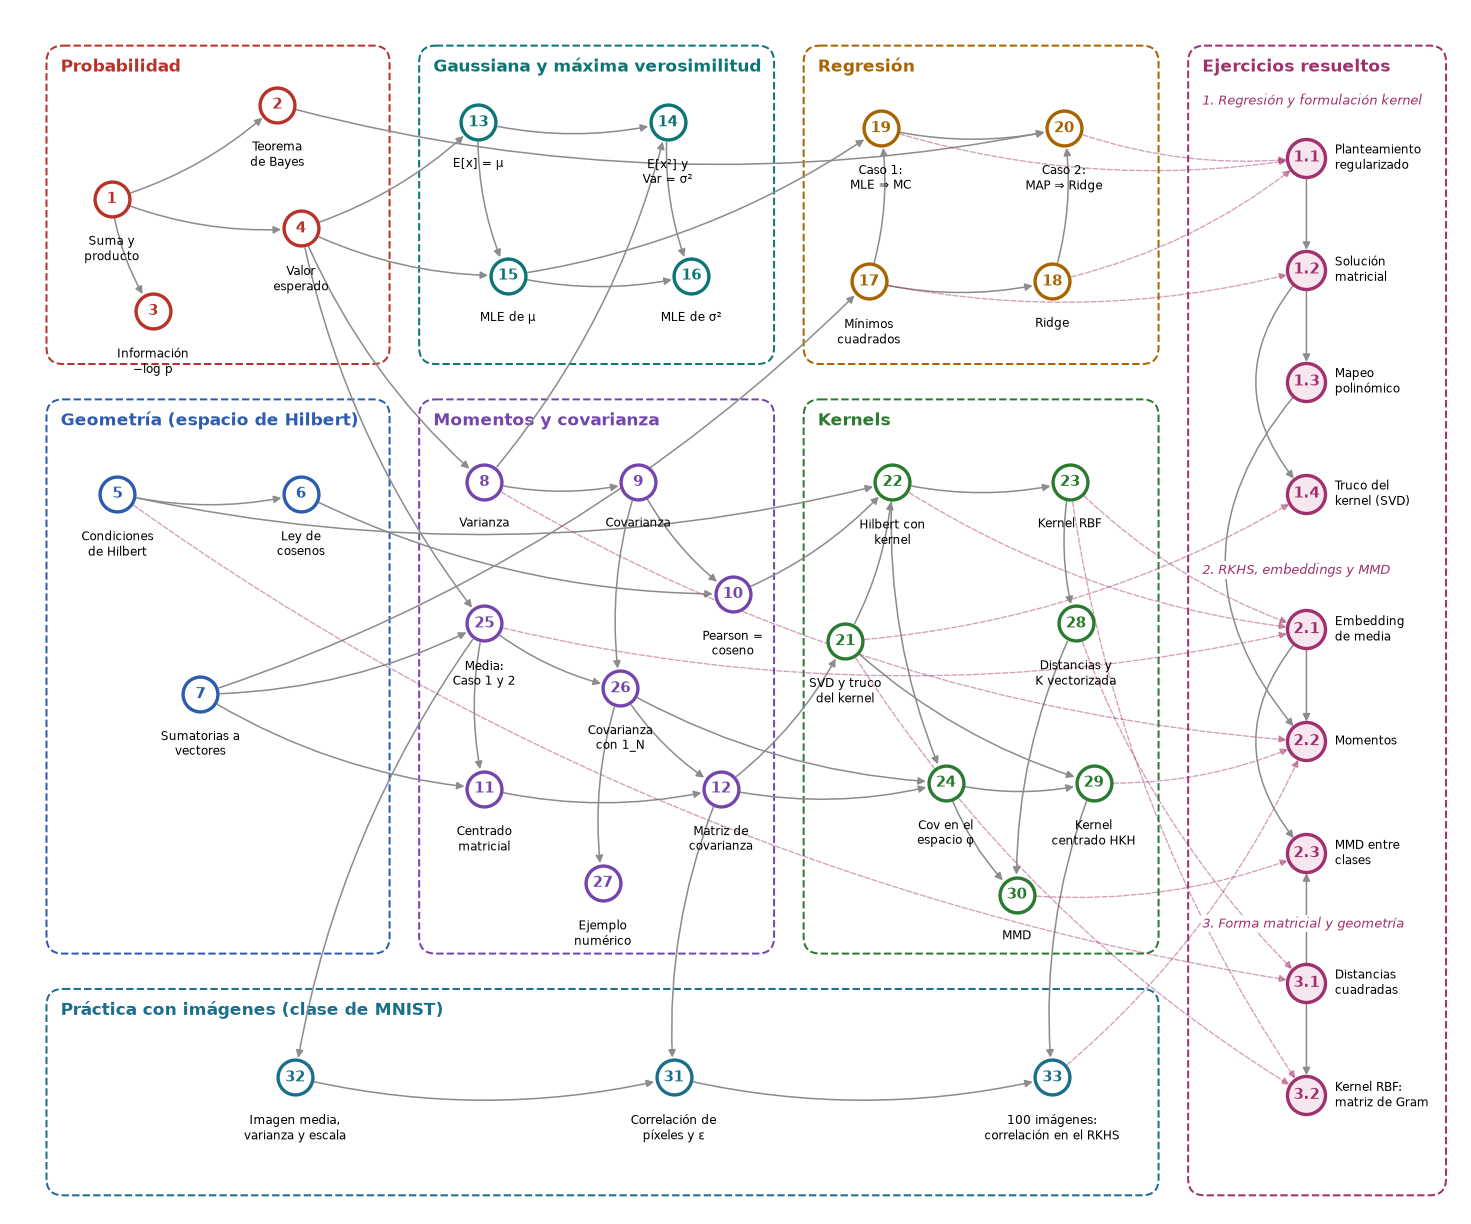

 1. Reglas de la suma y del producto
 4. Valor esperado y densidad de probabilidad
 5. Espacio de Hilbert: producto interno, norma, distancia y métrica
 6. Ley de cosenos ⇒ ⟨a, b⟩ = ‖a‖‖b‖ cos θ
 7. Sumatorias a forma vectorial (tarea)
 8. Varianza como momento centralizado
 9. Covarianza
10. Índice de correlación de Pearson como coseno
11. Media y centrado en forma matricial
12. Matriz de covarianza y varianza total
21. Matriz de Gram vía SVD y truco del kernel
22. Hilbert en el espacio de características
23. Kernel RBF y ancho de banda
24. Covarianza en el espacio de características (pizarrón)
25. Media en forma matricial: Caso 1 y Caso 2
26. Covarianza matricial con el vector de unos (Review)
28. Distancias al cuadrado vectorizadas y matriz kernel RBF
30. MMD: Maximum Mean Discrepancy (solución de la última página)
Ejercicio 2.1. Embedding de media empírico con kernel lineal y RBF
Ejercicio 3.1. Matriz de distancias cuadradas en forma matricial
=> Ejercicio 2.3. Discrepancia entre c

In [3]:
NODOS = [[1, 85, 160, "prob", "Suma y\nproducto"], [2, 225, 80, "prob", "Teorema\nde Bayes"], [3, 120, 255, "prob", "Información\n−log p"], [4, 245, 185, "prob", "Valor\nesperado"], [5, 90, 410, "geo", "Condiciones\nde Hilbert"], [6, 245, 410, "geo", "Ley de\ncosenos"], [7, 160, 580, "geo", "Sumatorias a\nvectores"], [8, 400, 400, "mom", "Varianza"], [9, 530, 400, "mom", "Covarianza"], [10, 610, 495, "mom", "Pearson =\ncoseno"], [11, 400, 660, "mom", "Centrado\nmatricial"], [12, 600, 660, "mom", "Matriz de\ncovarianza"], [13, 395, 95, "gauss", "E[x] = μ"], [14, 555, 95, "gauss", "E[x²] y\nVar = σ²"], [15, 420, 225, "gauss", "MLE de μ"], [16, 575, 225, "gauss", "MLE de σ²"], [17, 725, 230, "reg", "Mínimos\ncuadrados"], [18, 880, 230, "reg", "Ridge"], [19, 735, 100, "reg", "Caso 1:\nMLE ⇒ MC"], [20, 890, 100, "reg", "Caso 2:\nMAP ⇒ Ridge"], [21, 705, 535, "kern", "SVD y truco\ndel kernel"], [22, 745, 400, "kern", "Hilbert con\nkernel"], [23, 895, 400, "kern", "Kernel RBF"], [24, 790, 655, "kern", "Cov en el\nespacio φ"], [25, 400, 520, "mom", "Media:\nCaso 1 y 2"], [26, 515, 575, "mom", "Covarianza\ncon 1_N"], [27, 500, 740, "mom", "Ejemplo\nnumérico"], [28, 900, 520, "kern", "Distancias y\nK vectorizada"], [29, 915, 655, "kern", "Kernel\ncentrado HKH"], [30, 850, 750, "kern", "MMD"], [31, 560, 905, "clase", "Correlación de\npíxeles y ε"], [32, 240, 905, "clase", "Imagen media,\nvarianza y escala"], [33, 880, 905, "clase", "100 imágenes:\ncorrelación en el RKHS"], [101, 1095, 125, "ej", "Planteamiento\nregularizado"], [102, 1095, 220, "ej", "Solución\nmatricial"], [103, 1095, 315, "ej", "Mapeo\npolinómico"], [104, 1095, 410, "ej", "Truco del\nkernel (SVD)"], [201, 1095, 525, "ej", "Embedding\nde media"], [202, 1095, 620, "ej", "Momentos"], [203, 1095, 715, "ej", "MMD entre\nclases"], [301, 1095, 825, "ej", "Distancias\ncuadradas"], [302, 1095, 920, "ej", "Kernel RBF:\nmatriz de Gram"]]
ARISTAS = [[1, 2], [1, 3], [1, 4], [4, 8], [4, 13], [4, 15], [2, 20], [5, 6], [5, 22], [6, 10], [7, 11], [7, 17], [8, 9], [9, 10], [11, 12], [8, 14], [13, 14], [13, 15], [15, 16], [14, 16], [15, 19], [17, 18], [17, 19], [18, 20], [19, 20], [12, 21], [21, 22], [22, 23], [10, 22], [12, 24], [22, 24], [4, 25], [7, 25], [25, 11], [25, 26], [9, 26], [26, 12], [26, 27], [26, 24], [23, 28], [21, 29], [24, 29], [24, 30], [28, 30], [25, 32], [12, 31], [32, 31], [31, 33], [29, 33], [18, 101], [19, 101], [20, 101], [101, 102], [17, 102], [102, 103], [102, 104], [21, 104], [22, 201], [23, 201], [25, 201], [201, 202], [103, 202], [8, 202], [29, 202], [33, 202], [201, 203], [30, 203], [301, 203], [28, 301], [5, 301], [301, 302], [23, 302], [21, 302]]
REGIONES = {"prob": [30, 30, 290, 270], "gauss": [345, 30, 300, 270], "reg": [670, 30, 300, 270], "geo": [30, 330, 290, 470], "mom": [345, 330, 300, 470], "kern": [670, 330, 300, 470], "clase": [30, 830, 940, 175], "ej": [995, 30, 218, 975]}
NOMBRES = {"prob": "Probabilidad", "geo": "Geometría (espacio de Hilbert)", "mom": "Momentos y covarianza", "gauss": "Gaussiana y máxima verosimilitud", "reg": "Regresión", "kern": "Kernels", "clase": "Práctica con imágenes (clase de MNIST)", "ej": "Ejercicios resueltos"}
SUBTITULOS = [[1007, 80, "1. Regresión y formulación kernel"], [1007, 478, "2. RKHS, embeddings y MMD"], [1007, 778, "3. Forma matricial y geometría"]]
TITULOS = {1: 'Reglas de la suma y del producto', 2: 'Teorema de Bayes', 3: 'Contenido de información y entropía', 4: 'Valor esperado y densidad de probabilidad', 5: 'Espacio de Hilbert: producto interno, norma, distancia y métrica', 6: 'Ley de cosenos ⇒ ⟨a, b⟩ = ‖a‖‖b‖ cos θ', 7: 'Sumatorias a forma vectorial (tarea)', 8: 'Varianza como momento centralizado', 9: 'Covarianza', 10: 'Índice de correlación de Pearson como coseno', 11: 'Media y centrado en forma matricial', 12: 'Matriz de covarianza y varianza total', 13: 'Gaussiana: el valor esperado es μ', 14: 'Gaussiana: segundo momento y varianza', 15: 'Máxima verosimilitud de μ', 16: 'Máxima verosimilitud de σ²', 17: 'Mínimos cuadrados', 18: 'Mínimos cuadrados regularizados (Ridge)', 19: 'Caso 1: máxima verosimilitud con ruido gaussiano', 20: 'Caso 2: MAP con prior gaussiano sobre w', 21: 'Matriz de Gram vía SVD y truco del kernel', 22: 'Hilbert en el espacio de características', 23: 'Kernel RBF y ancho de banda', 24: 'Covarianza en el espacio de características (pizarrón)', 25: 'Media en forma matricial: Caso 1 y Caso 2', 26: 'Covarianza matricial con el vector de unos (Review)', 27: 'Ejemplo numérico de covarianza (1 de octubre)', 28: 'Distancias al cuadrado vectorizadas y matriz kernel RBF', 29: 'Centrado del kernel: HKH', 30: 'MMD: Maximum Mean Discrepancy (solución de la última página)', 31: 'Matriz de correlación de píxeles y el ε', 32: 'Imagen media, imagen de varianza y escala de color', 33: 'Kernel RBF entre clases: matriz 100×100 y correlación en el RKHS', 101: 'Mínimos cuadrados regularizados en el espacio de características', 102: 'Solución matricial del estimador regularizado', 103: 'Mapeo polinómico: matriz de diseño y verificación en código', 104: 'Truco del kernel a partir de la SVD', 201: 'Embedding de media empírico con kernel lineal y RBF', 202: 'Momentos brutos, centrados y estandarizados', 203: 'Discrepancia entre clases de MNIST con el MMD', 301: 'Matriz de distancias cuadradas en forma matricial', 302: 'Matriz kernel RBF: diagonal, simetría y semidefinición positiva'}
NUM = {"1.1": 101, "1.2": 102, "1.3": 103, "1.4": 104, "2.1": 201, "2.2": 202, "2.3": 203, "3.1": 301, "3.2": 302}                       # número visible de cada ejercicio
etiqueta = lambda n: next((k for k, v in NUM.items() if v == n), str(n))
nombre = lambda n: (f"Ejercicio {etiqueta(n)}" if n in NUM.values() else f"{n:>2}") + ". " + TITULOS[n]

pos = {n: (x, y) for n, x, y, b, l in NODOS}
bloque = {n: b for n, x, y, b, l in NODOS}
fig, ax = plt.subplots(figsize=(17, 14.2))
for b, (x, y, w_, h) in REGIONES.items():
    ax.add_patch(FancyBboxPatch((x, y), w_, h, boxstyle="round,pad=0,rounding_size=14", fill=False, ls="--", lw=1.3, ec=C[b]))
    ax.text(x + 12, y + 22, NOMBRES[b], color=C[b], fontsize=11, weight="bold")
for x, y, t in SUBTITULOS:
    ax.text(x, y, t, color=C["ej"], fontsize=8.5, style="italic", zorder=5, bbox=dict(fc="white", ec="none", pad=1))
for a, b in ARISTAS:
    de_demo = bloque[b] == "ej" and bloque[a] != "ej"              # de una demostración a un ejercicio
    entre_ej = bloque[a] == "ej" and bloque[b] == "ej"
    curva = (0.45 if abs(pos[a][1] - pos[b][1]) > 120 else 0) if entre_ej else 0.12   # rodea los ejercicios intermedios
    ax.annotate("", xy=pos[b], xytext=pos[a], arrowprops=dict(
        arrowstyle="-|>", color=C["ej"] if de_demo else "0.55", lw=0.9 if de_demo else 1,
        alpha=0.45 if de_demo else 1, ls="--" if de_demo else "-",
        shrinkA=13, shrinkB=13, connectionstyle=f"arc3,rad={curva}"))
for n, x, y, b, l in NODOS:
    es_ej = b == "ej"
    ax.scatter(x, y, s=620 if es_ej else 520, c="#F6E7EF" if es_ej else "white", edgecolors=C[b], linewidths=2.2, zorder=3)
    ax.text(x, y, etiqueta(n), ha="center", va="center", fontsize=9.5 if es_ej else 10, weight="bold", color=C[b], zorder=4)
    if es_ej:                                                       # en la columna de ejercicios, el nombre va a la derecha
        ax.text(x + 24, y, l, ha="left", va="center", fontsize=8, zorder=4)
    else:
        ax.text(x, y + 30, l, ha="center", va="top", fontsize=8, zorder=4)
ax.set_xlim(0, 1225); ax.set_ylim(1020, 0); ax.axis("off"); ax.grid(False)
plt.show()

PREVIAS = {n: [] for n in pos}
for a, b in ARISTAS:
    PREVIAS[b].append(a)

def ruta(n):
    """Lo que conviene estudiar antes de n: ruta(30) para una demostración, ruta("2.3") para un ejercicio."""
    n = NUM.get(str(n), n)
    vistos, pila = set(), list(PREVIAS[n])
    while pila:
        v = pila.pop()
        if v not in vistos:
            vistos.add(v); pila.extend(PREVIAS[v])
    for v in sorted(vistos):
        print(nombre(v))
    print("=>", nombre(n))

ruta("2.3")

# Probabilidad

## 1. Reglas de la suma y del producto

**Resultado**

$$P(X=x_i)=\sum_{j}P(X=x_i,Y=y_j)$$

$$P(X=x_i,Y=y_j)=P(Y=y_j\mid X=x_i)\,P(X=x_i)$$

**Idea:** La probabilidad se interpreta como frecuencia relativa, así que todo se reduce a contar celdas de una tabla. La marginal junta una fila completa; la condicional se queda dentro de una fila y divide por el total de esa fila. Multiplicar y dividir por el mismo número $c_i$ no cambia nada, y eso es exactamente la regla del producto.

**Qué muestra la gráfica:** La tabla conjunta como mapa de calor, sus marginales como barras y la condicional como barras apiladas.

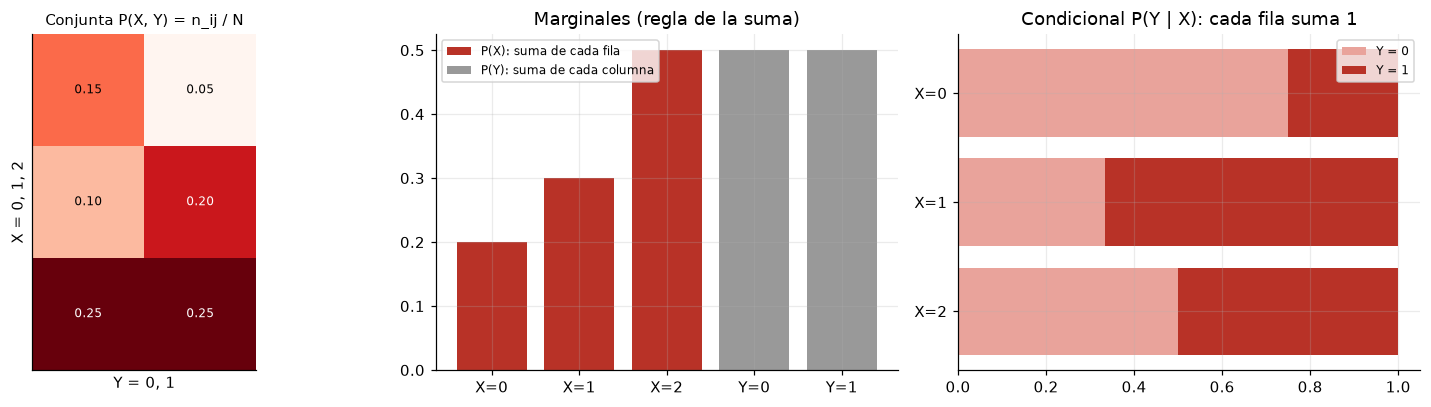

Regla del producto P(X,Y) = P(Y|X) P(X): True


In [4]:
# Demostración 1: Reglas de la suma y del producto
n = np.array([[3, 1], [2, 4], [5, 5]])          # conteos n_ij (filas = X, columnas = Y)
N = n.sum(); pXY = n / N
pX, pY = pXY.sum(axis=1), pXY.sum(axis=0)        # regla de la suma
pY_dado_X = n / n.sum(axis=1, keepdims=True)     # condicional: cada fila entre su total

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
mapa_calor(ax[0], pXY, "Conjunta P(X, Y) = n_ij / N", cmap="Reds", centrado=False)
ax[0].set_ylabel("X = 0, 1, 2"); ax[0].set_xlabel("Y = 0, 1")
ax[1].bar(["X=0", "X=1", "X=2"], pX, color=C["prob"], label="P(X): suma de cada fila")
ax[1].bar(["Y=0", "Y=1"], pY, color="0.6", label="P(Y): suma de cada columna")
ax[1].set_title("Marginales (regla de la suma)"); ax[1].legend(fontsize=8)
izq = np.zeros(3)
for j, col in enumerate(["#E9A39B", C["prob"]]):
    ax[2].barh(["X=0", "X=1", "X=2"], pY_dado_X[:, j], left=izq, color=col, label=f"Y = {j}")
    izq += pY_dado_X[:, j]
ax[2].invert_yaxis(); ax[2].legend(fontsize=8); ax[2].set_title("Condicional P(Y | X): cada fila suma 1")
plt.tight_layout(); plt.show()
print("Regla del producto P(X,Y) = P(Y|X) P(X):", np.allclose(pXY, pY_dado_X * pX[:, None]))

**Qué observar:** Cada barra de $P(X)$ es la suma de una fila del mapa. Cada fila de la condicional suma 1 porque se divide entre el total de su fila $c_i$.

**Prueba a cambiar:** Cambia los conteos de `n` y comprueba que la regla del producto sigue dando `True`.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Interpretación.** ¿Qué significa $P(X=x_i)$ en la tabla de conteos?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** La fracción de veces que salió $x_i$, sin importar $Y$.
2. **Por qué.** Es la fila completa entre el total: se juntan todas las $Y$ (regla de la suma).
3. **Con los datos.** Con $n=[[3,1],[2,4],[5,5]]$, $P(X=2)=\frac{10}{20}=0.5$.

</details>

**Justificación.** ¿Por qué cada fila de la condicional $P(Y\mid X)$ suma 1?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque cada fila se divide entre su propio total.
2. **Por qué.** $P(Y=y_j\mid X=x_i)=\frac{n_{ij}}{c_i}$ y $\sum_j n_{ij}=c_i$.
3. **Con los datos.** Fila $X=1$: $\frac26+\frac46=1$.

</details>

**Efecto de un cambio.** Si duplico todos los conteos, ¿afecta las probabilidades?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** No.
2. **Por qué.** Numerador y denominador se duplican, así que $\frac{n_{ij}}{N}$ no cambia.
3. **Con los datos.** Es la misma frecuencia relativa, solo con más ensayos.

</details>

## 2. Teorema de Bayes

**Resultado**

$$P(Y=y_j\mid X=x_i)=\frac{P(X=x_i\mid Y=y_j)\,P(Y=y_j)}{P(X=x_i)}$$

**Idea:** La conjunta se puede partir en dos órdenes y ambos dan el mismo número. Bayes solo iguala esos dos órdenes. Así se invierte una condicional: de lo que es fácil medir (el síntoma dada la enfermedad) a lo que interesa (la enfermedad dado el síntoma).

**Qué muestra la gráfica:** La probabilidad de estar enfermo después de un resultado positivo según la prevalencia (el prior), y el mismo cálculo contado en 1000 personas.

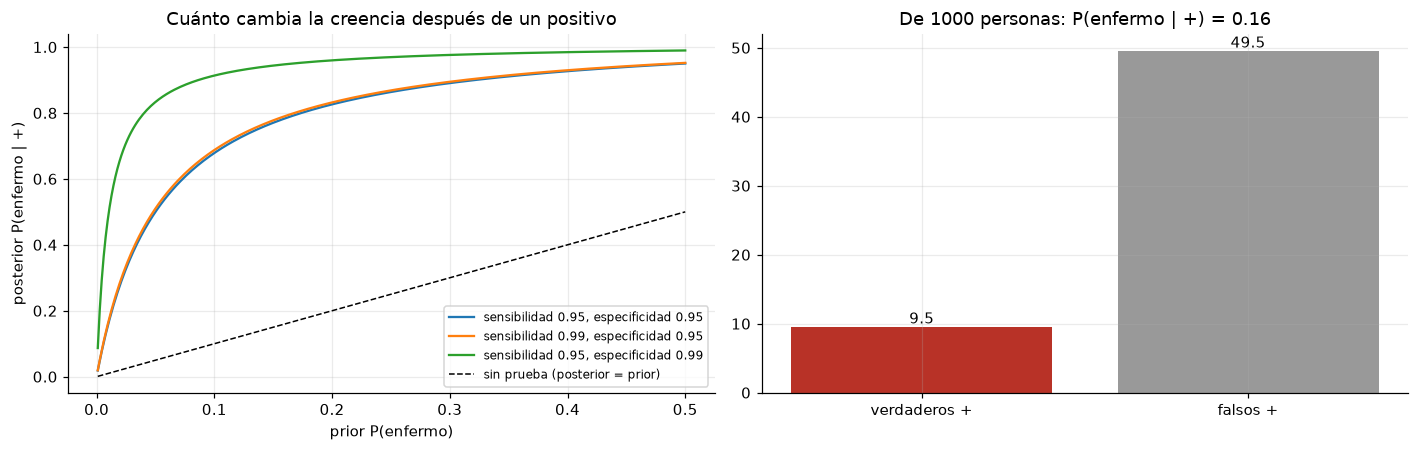

In [5]:
# Demostración 2: Teorema de Bayes
prior = np.linspace(0.001, 0.5, 300)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for sens, esp in [(0.95, 0.95), (0.99, 0.95), (0.95, 0.99)]:
    post = sens * prior / (sens * prior + (1 - esp) * (1 - prior))      # Bayes
    ax[0].plot(prior, post, label=f"sensibilidad {sens}, especificidad {esp}")
ax[0].plot(prior, prior, "k--", lw=1, label="sin prueba (posterior = prior)")
ax[0].set_xlabel("prior P(enfermo)"); ax[0].set_ylabel("posterior P(enfermo | +)")
ax[0].legend(fontsize=8); ax[0].set_title("Cuánto cambia la creencia después de un positivo")

pE, sens, fp = 0.01, 0.95, 0.05                       # 1000 personas, prevalencia 1 %
vp = 1000 * pE * sens; falsos = 1000 * (1 - pE) * fp
ax[1].bar(["verdaderos +", "falsos +"], [vp, falsos], color=[C["prob"], "0.6"])
for k, v in enumerate([vp, falsos]):
    ax[1].text(k, v, f"{v:.1f}", ha="center", va="bottom")
ax[1].set_title(f"De 1000 personas: P(enfermo | +) = {vp / (vp + falsos):.2f}")
plt.tight_layout(); plt.show()

**Qué observar:** Con una prevalencia baja, incluso una prueba del 95 % deja una posterior baja: hay más falsos positivos que verdaderos positivos. La evidencia $P(+)$ del denominador es la que reparte esa probabilidad.

**Prueba a cambiar:** En el segundo panel cambia `fp = 0.05` por `fp = 0.01` (especificidad de 0.99) y mira cuánto mejora la posterior.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Interpretación.** ¿Qué significa la evidencia $P(X)$ en Bayes?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** La probabilidad total de observar el dato, sumando todas las causas posibles.
2. **Por qué.** Es el denominador que normaliza: hace que la posterior sume 1.
3. **Con los datos.** En la prueba médica, $P(+)=0.95\cdot0.01+0.05\cdot0.99\approx0.059$.

</details>

**Extremos.** ¿Qué pasa con la posterior si el prior es 0? ¿Y si es 1?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Se queda en 0 o en 1, sin importar el dato.
2. **Por qué.** La posterior es proporcional a verosimilitud por prior: un prior de 0 anula todo y uno de 1 no deja espacio a otra causa.
3. **Con los datos.** Por eso nunca se le pone prior 0 a algo que sí puede pasar.

</details>

**Justificación.** ¿Por qué una prueba del 95 % da solo un 16 % de probabilidad de estar enfermo?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque la enfermedad es rara (1 %).
2. **Por qué.** Los falsos positivos de los sanos superan a los verdaderos positivos de los enfermos.
3. **Con los datos.** De 1000 personas: 9.5 verdaderos positivos frente a 49.5 falsos.

</details>

## 3. Contenido de información y entropía

**Resultado**

$$h(x)=-\log_2 P(x)$$

$$H[x]=-\sum_x P(x)\log_2 P(x)$$

**Idea:** Como dicen tus apuntes: los eventos menos probables son donde hay más información. Algo casi seguro no sorprende. El logaritmo además hace que la información de eventos independientes se sume.

**Qué muestra la gráfica:** La información $h(x)=-\log_2P(x)$ y la entropía de una moneda según su probabilidad de cara.

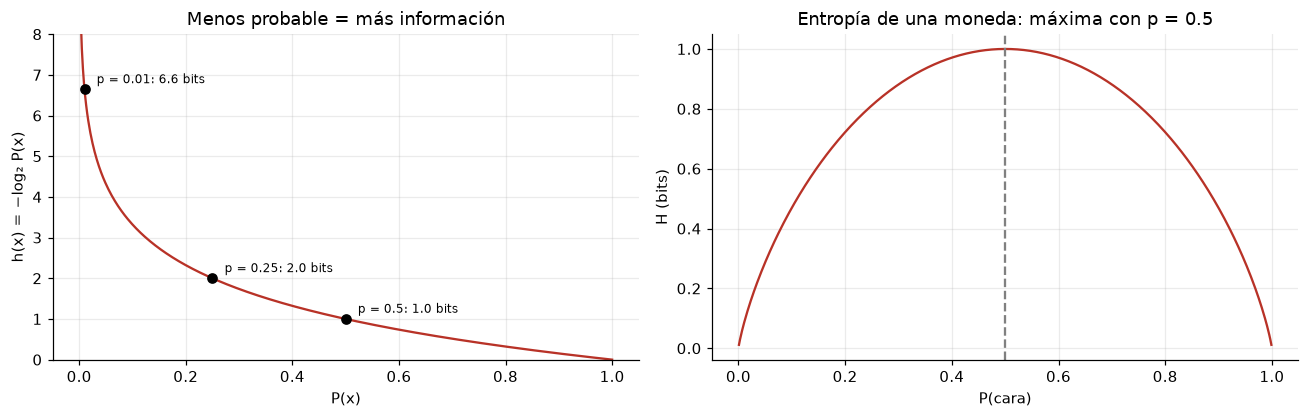

In [6]:
# Demostración 3: Contenido de información y entropía
p = np.linspace(0.001, 1, 500)
q = np.linspace(0.001, 0.999, 500)
H = -(q * np.log2(q) + (1 - q) * np.log2(1 - q))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.9))
ax[0].plot(p, -np.log2(p), color=C["prob"]); ax[0].set_ylim(0, 8)
for pp in [0.5, 0.25, 0.01]:
    ax[0].scatter(pp, -np.log2(pp), color="k", zorder=3)
    ax[0].annotate(f"p = {pp}: {-np.log2(pp):.1f} bits", (pp, -np.log2(pp)), textcoords="offset points", xytext=(8, 4), fontsize=8)
ax[0].set_xlabel("P(x)"); ax[0].set_ylabel("h(x) = −log₂ P(x)"); ax[0].set_title("Menos probable = más información")
ax[1].plot(q, H, color=C["prob"]); ax[1].axvline(0.5, ls="--", c="0.5")
ax[1].set_xlabel("P(cara)"); ax[1].set_ylabel("H (bits)"); ax[1].set_title("Entropía de una moneda: máxima con p = 0.5")
plt.tight_layout(); plt.show()

**Qué observar:** $h$ crece sin límite cuando $P\to0$ y vale 0 cuando $P=1$. La entropía, que es el promedio de $h$, es máxima cuando los dos resultados son igual de probables.

**Prueba a cambiar:** Calcula la entropía de un dado cargado, por ejemplo `[0.5, 0.1, 0.1, 0.1, 0.1, 0.1]`.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Interpretación.** ¿Qué significa que un evento tenga 6.6 bits de información?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Que es muy sorpresivo: su probabilidad es cerca de 0.01.
2. **Por qué.** $h=-\log_2P$ crece cuando la probabilidad baja.
3. **Con los datos.** Una moneda justa da 1 bit; un evento del 1 % da 6.6 bits.

</details>

**Extremos.** ¿Qué pasa con $h(x)$ si $P\to1$? ¿Y si $P\to0$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Tiende a 0 y a infinito.
2. **Por qué.** Lo seguro no informa; lo casi imposible sorprende sin límite.
3. **Con los datos.** La entropía de la moneda es máxima en $p=0.5$, cuando no sabes qué va a salir.

</details>

**Justificación.** ¿Por qué la información usa un logaritmo?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Para que la información de eventos independientes se sume.
2. **Por qué.** $\log(pq)=\log p+\log q$.
3. **Con los datos.** Dos monedas independientes dan $1+1=2$ bits.

</details>

## 4. Valor esperado y densidad de probabilidad

**Resultado**

$$\mathbb{E}\{x\}=\sum_n P(X=x_n)\,x_n$$

$$\mathbb{E}\{x\}=\int x\,p(x)\,dx$$

$$\int p(x)\,dx=1$$

**Idea:** Se suma cada valor posible multiplicado por su probabilidad de ocurrir: es un promedio ponderado. En el caso continuo la probabilidad de un punto exacto es cero, por eso se trabaja con la densidad y la suma pasa a integral.

**Qué muestra la gráfica:** La densidad normal con los rectángulos $p(x)\Delta x$ que aproximan el área, la probabilidad de un intervalo como área sombreada y el promedio de muestras acercándose al valor esperado.

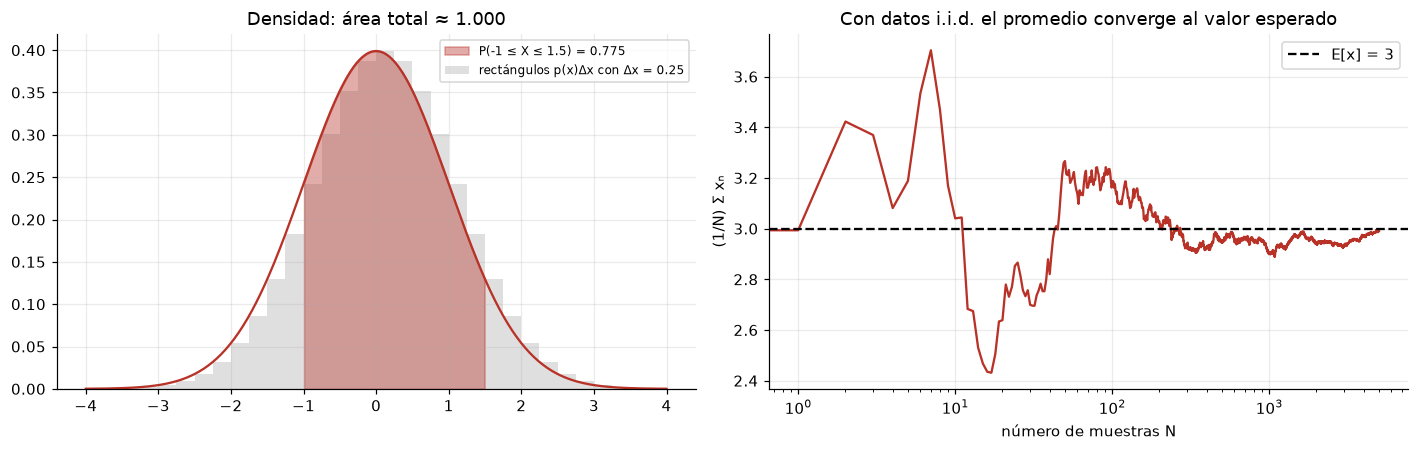

In [7]:
# Demostración 4: Valor esperado y densidad de probabilidad
x = np.linspace(-4, 4, 400); a, b, dx = -1, 1.5, 0.25
xs = np.arange(-4, 4, dx)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(x, norm.pdf(x), color=C["prob"])
ax[0].bar(xs, norm.pdf(xs), width=dx, align="edge", alpha=0.25, color="0.5", label=f"rectángulos p(x)Δx con Δx = {dx}")
m = (x >= a) & (x <= b)
ax[0].fill_between(x[m], norm.pdf(x[m]), color=C["prob"], alpha=0.4, label=f"P({a} ≤ X ≤ {b}) = {norm.cdf(b) - norm.cdf(a):.3f}")
ax[0].set_title(f"Densidad: área total ≈ {np.sum(norm.pdf(xs)) * dx:.3f}"); ax[0].legend(fontsize=8)

muestras = rng.normal(3, 2, 5000)
prom = np.cumsum(muestras) / np.arange(1, 5001)           # (1/N) Σ x_n para N = 1, 2, ...
ax[1].plot(prom, color=C["prob"]); ax[1].axhline(3, ls="--", c="k", label="E[x] = 3")
ax[1].set_xscale("log"); ax[1].set_xlabel("número de muestras N"); ax[1].set_ylabel("(1/N) Σ xₙ")
ax[1].set_title("Con datos i.i.d. el promedio converge al valor esperado"); ax[1].legend()
plt.tight_layout(); plt.show()

**Qué observar:** El área total da 1 y la probabilidad de un intervalo es un área, no la altura de la curva. El promedio oscila al principio y se estabiliza en 3 (ley de los grandes números).

**Prueba a cambiar:** Agranda `dx` a 1 y mira cómo empeora la aproximación del área.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Interpretación.** Si una densidad vale 0.4 en $x=0$, ¿significa que $P(X=0)=0.4$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** No: $P(X=0)=0$.
2. **Por qué.** En variables continuas la probabilidad es un área, $p(x)\Delta x$, no la altura de la curva.
3. **Con los datos.** La normal estándar vale 0.399 en 0, pero solo los intervalos tienen probabilidad.

</details>

**Justificación.** ¿Por qué el promedio de las muestras aproxima el valor esperado?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Por la ley de los grandes números, con datos i.i.d.
2. **Por qué.** Cada muestra pesa igual y las frecuencias se acercan a la distribución.
3. **Con los datos.** Con 5000 muestras el promedio se queda en 3, el valor esperado.

</details>

**Extremos.** ¿Qué pasa con la suma de rectángulos $\sum p(x)\Delta x$ si $\Delta x\to0$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Se convierte en la integral y da 1.
2. **Por qué.** Es la definición de integral de Riemann.
3. **Con los datos.** Con $\Delta x=0.25$ ya da casi 1.

</details>

# Geometría (espacio de Hilbert)

## 5. Espacio de Hilbert: producto interno, norma, distancia y métrica

**Resultado**

$$\langle a,b\rangle=a^Tb,\quad\|a\|_2^2=\langle a,a\rangle,\quad d(a,b)=\|a-b\|_2$$

$$\|a-b\|_2^2=\|a\|_2^2-2\langle a,b\rangle+\|b\|_2^2$$

**Idea:** El producto interno es la pieza que genera todo lo demás: con él se definen longitudes, distancias y ángulos. Si tienes producto interno, tienes geometría.

**Qué muestra la gráfica:** Los vectores $a$, $b$ y $a-b$ con sus normas, y las bolas unitarias de tres normas distintas.

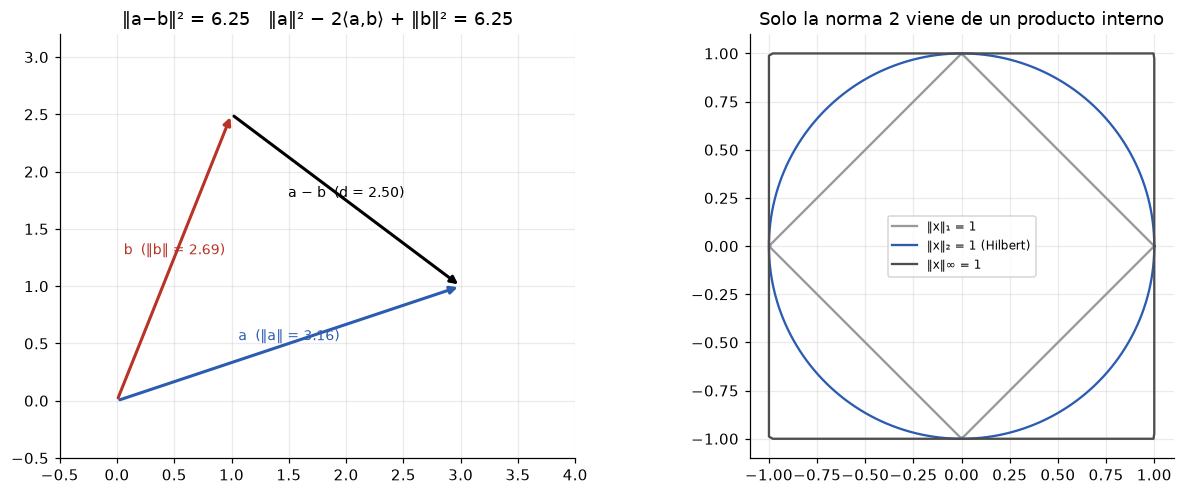

In [8]:
# Demostración 5: Espacio de Hilbert: producto interno, norma, distancia y métrica
a, b = np.array([3.0, 1.0]), np.array([1.0, 2.5])
def flecha(ax, o, v, c, t):
    ax.annotate("", xy=o + v, xytext=o, arrowprops=dict(arrowstyle="-|>", color=c, lw=2))
    ax.text(*(o + v / 2), t, color=c, fontsize=9, ha="center", va="bottom")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
o = np.zeros(2)
flecha(ax[0], o, a, C["geo"], f"a  (‖a‖ = {np.linalg.norm(a):.2f})")
flecha(ax[0], o, b, C["prob"], f"b  (‖b‖ = {np.linalg.norm(b):.2f})")
flecha(ax[0], b, a - b, "k", f"a − b  (d = {np.linalg.norm(a - b):.2f})")
ax[0].set_aspect("equal"); ax[0].set_xlim(-0.5, 4); ax[0].set_ylim(-0.5, 3.2)
ax[0].set_title(f"‖a−b‖² = {np.sum((a - b)**2):.2f}   ‖a‖² − 2⟨a,b⟩ + ‖b‖² = {a@a - 2*a@b + b@b:.2f}")

t = np.linspace(0, 2 * np.pi, 400); u = np.c_[np.cos(t), np.sin(t)]
for pnorm, c, nombre in [(1, "0.6", "‖x‖₁ = 1"), (2, C["geo"], "‖x‖₂ = 1 (Hilbert)"), (np.inf, "0.3", "‖x‖∞ = 1")]:
    v = u / np.linalg.norm(u, ord=pnorm, axis=1, keepdims=True)
    ax[1].plot(v[:, 0], v[:, 1], color=c, label=nombre)
ax[1].set_aspect("equal"); ax[1].legend(fontsize=8)
ax[1].set_title("Solo la norma 2 viene de un producto interno")
plt.tight_layout(); plt.show()

**Qué observar:** La expresión $\|a\|^2-2\langle a,b\rangle+\|b\|^2$ da exactamente la distancia al cuadrado. Solo la norma 2 (el círculo) sale de un producto interno, y por eso es la que cumple las condiciones de Hilbert.

**Prueba a cambiar:** Pon `b` perpendicular a `a`, por ejemplo `[-1, 3]`: el producto interno se vuelve 0 y la expresión se reduce a Pitágoras.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Dimensiones.** ¿De qué tamaño es $a^Tb$ si $a,b\in\mathbb{R}^{P\times1}$? ¿Y $ab^T$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $a^Tb$ es $1\times1$, un número; $ab^T$ es $P\times P$.
2. **Por qué.** $(1\times P)(P\times1)$ frente a $(P\times1)(1\times P)$.
3. **Con los datos.** El primero es el producto interno; el segundo, el producto exterior que usamos para $\boldsymbol\sigma^T\boldsymbol\sigma$.

</details>

**Justificación.** ¿Por qué la distancia se puede escribir solo con productos internos?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Por la expansión $\|a-b\|^2=\|a\|^2-2\langle a,b\rangle+\|b\|^2$.
2. **Por qué.** El producto interno es bilineal: se reparte como una multiplicación.
3. **Con los datos.** Es lo que después permite calcular distancias con el kernel (demostraciones 22 y 28).

</details>

**Interpretación.** ¿Qué significa $\langle a,b\rangle=0$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Que los vectores son perpendiculares.
2. **Por qué.** $\langle a,b\rangle=\|a\|\|b\|\cos\theta$ y $\cos90^\circ=0$.
3. **Con los datos.** No comparten ninguna dirección: ninguno "se parece" al otro.

</details>

## 6. Ley de cosenos ⇒ ⟨a, b⟩ = ‖a‖‖b‖ cos θ

**Resultado**

$$\langle a,b\rangle=\|a\|\,\|b\|\cos\theta$$

**Idea:** El producto interno no solo mide tamaños, también mide alineación. La geometría (triángulos) y el álgebra (vectores) calculan la misma longitud $\|a-b\|$; al igualar las dos expresiones aparece el coseno.

**Qué muestra la gráfica:** El triángulo de la demostración con $A$, $B$, $C$, $h$ y $x$, y el producto interno cuando $b$ gira alrededor de $a$.

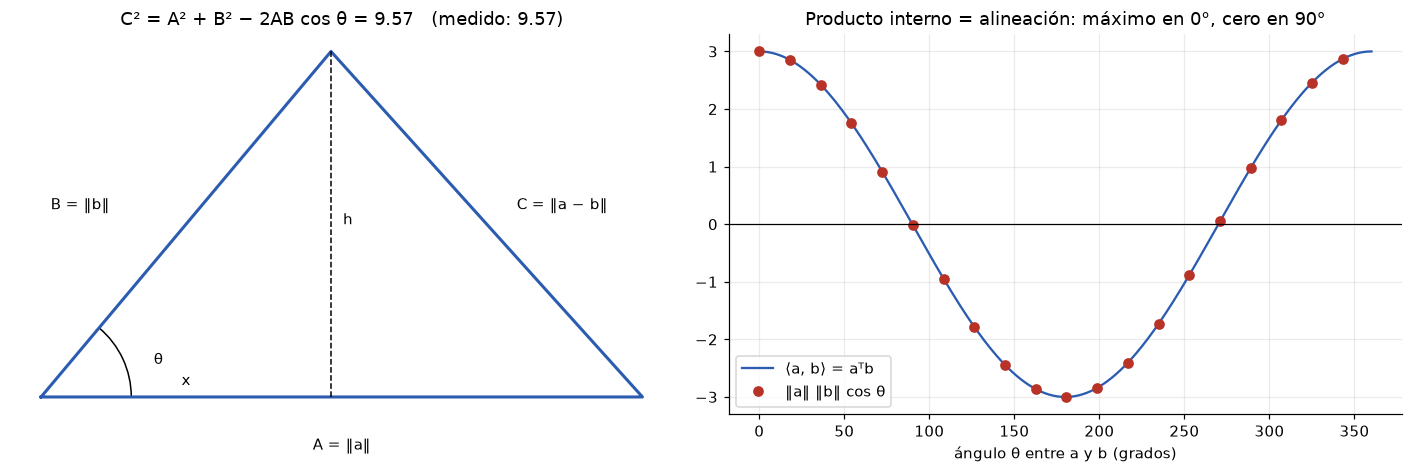

In [9]:
# Demostración 6: Ley de cosenos ⇒ ⟨a, b⟩ = ‖a‖‖b‖ cos θ
A_, B_, th = 4.0, 3.0, np.deg2rad(50)
P0, P1 = np.array([0.0, 0.0]), np.array([A_, 0.0])
P2 = B_ * np.array([np.cos(th), np.sin(th)])
xh, h = B_ * np.cos(th), B_ * np.sin(th)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].plot(*np.c_[P0, P1, P2, P0], color=C["geo"], lw=2)
ax[0].plot([xh, xh], [0, h], "k--", lw=1)
ax[0].add_patch(Arc(P0, 1.2, 1.2, theta1=0, theta2=np.rad2deg(th), color="k"))
ax[0].text(0.75, 0.22, "θ"); ax[0].text(A_ / 2, -0.35, "A = ‖a‖", ha="center")
ax[0].text(xh / 2 - 0.9, h / 2 + 0.1, "B = ‖b‖"); ax[0].text((A_ + xh) / 2 + 0.2, h / 2 + 0.1, "C = ‖a − b‖")
ax[0].text(xh + 0.08, h / 2, "h"); ax[0].text(xh / 2, 0.08, "x", ha="center")
C2 = A_**2 + B_**2 - 2 * A_ * B_ * np.cos(th)
ax[0].set_title(f"C² = A² + B² − 2AB cos θ = {C2:.2f}   (medido: {np.sum((P1 - P2)**2):.2f})")
ax[0].set_aspect("equal"); ax[0].axis("off")

ang = np.linspace(0, 2 * np.pi, 300)
a = np.array([2.0, 0.0]); bs = 1.5 * np.c_[np.cos(ang), np.sin(ang)]
ax[1].plot(np.rad2deg(ang), bs @ a, color=C["geo"], label="⟨a, b⟩ = aᵀb")
ax[1].plot(np.rad2deg(ang)[::15], (np.linalg.norm(a) * 1.5 * np.cos(ang))[::15], "o", color=C["prob"], label="‖a‖ ‖b‖ cos θ")
ax[1].axhline(0, c="k", lw=0.8); ax[1].set_xlabel("ángulo θ entre a y b (grados)"); ax[1].legend()
ax[1].set_title("Producto interno = alineación: máximo en 0°, cero en 90°")
plt.tight_layout(); plt.show()

**Qué observar:** La curva de $a^Tb$ y los puntos de $\|a\|\|b\|\cos\theta$ coinciden: máximo con vectores alineados, cero a 90° y negativo con vectores opuestos.

**Prueba a cambiar:** Cambia el ángulo `th` del triángulo (por ejemplo a 120°) y comprueba que la ley de cosenos sigue coincidiendo con la medida.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Extremos.** ¿Qué pasa con $\langle a,b\rangle$ si el ángulo es 0°, 90° o 180°?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Vale $\|a\|\|b\|$, 0 y $-\|a\|\|b\|$.
2. **Por qué.** $\cos\theta$ vale 1, 0 y −1.
3. **Con los datos.** Vectores alineados, perpendiculares y opuestos.

</details>

**Justificación.** ¿Por qué se pueden igualar las dos expresiones de $C^2$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque las dos miden la misma longitud, $\|a-b\|$.
2. **Por qué.** Una sale de Pitágoras y la otra de la bilinealidad del producto interno.
3. **Con los datos.** En el código de esta demostración, las dos expresiones dan el mismo valor.

</details>

**Interpretación.** ¿Qué significa el coseno entre dos imágenes vistas como vectores?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Qué tan alineadas están, sin importar su tamaño.
2. **Por qué.** Se divide entre las normas, así que el brillo total no cuenta, solo la forma.
3. **Con los datos.** Es la similitud coseno de los embeddings.

</details>

## 7. Sumatorias a forma vectorial (tarea)

**Resultado**

$$\sum_i x_iy_i=x^Ty$$

$$\sum_i x_iA_{ij}=(x^TA)_j$$

$$\sum_j A_{ij}y_j=(Ay)_i$$

$$\sum_i\sum_j x_iA_{ij}y_j=x^TAy$$

$$M_{ij}=x_iy_j\Rightarrow M=xy^T$$

**Idea:** La multiplicación de matrices es, por definición, una suma sobre el índice compartido. Reconocer qué índice se suma te dice dónde va cada vector y si lleva transpuesta.

**Qué muestra la gráfica:** Los productos término a término, antes de sumar, y en qué dirección suma cada caso.

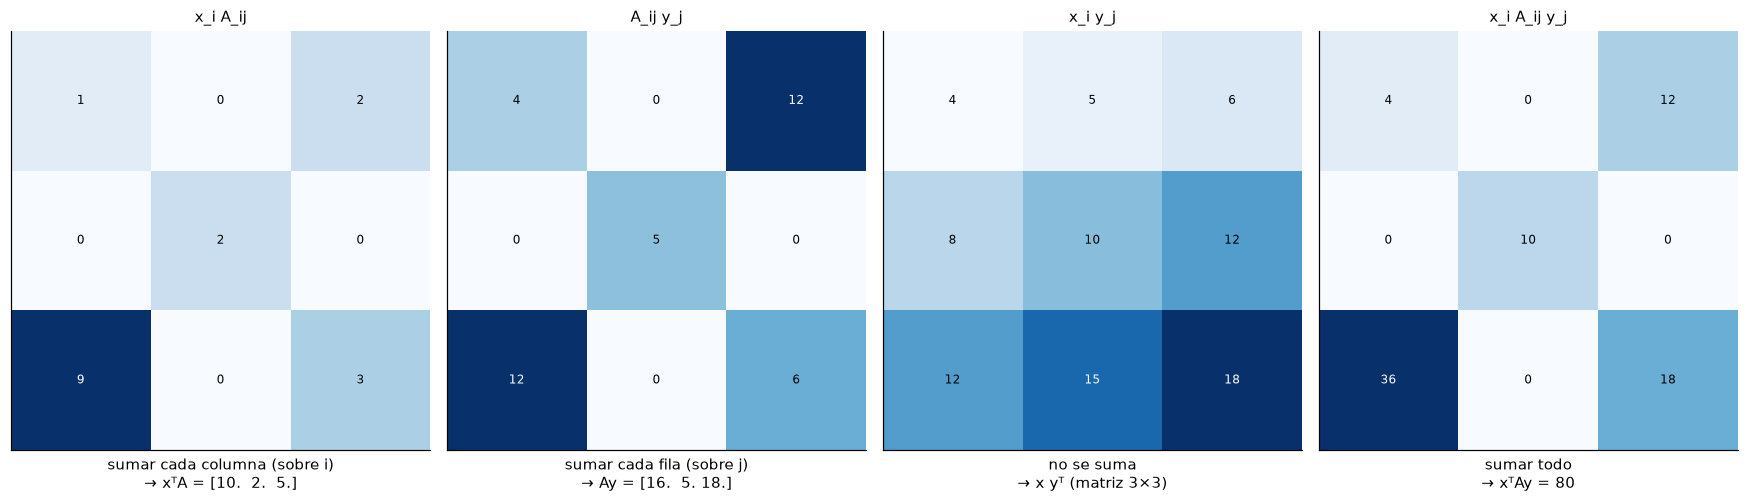

Con einsum: [10.  2.  5.] [16.  5. 18.] 80.0


In [10]:
# Demostración 7: Sumatorias a forma vectorial (tarea)
x = np.array([1.0, 2.0, 3.0]); y = np.array([4.0, 5.0, 6.0])
A = np.array([[1.0, 0, 2], [0, 1, 0], [3, 0, 1]])
M1 = x[:, None] * A                 # x_i A_ij  (antes de sumar)
M2 = A * y[None, :]                 # A_ij y_j
M3 = np.outer(x, y)                 # x_i y_j
M4 = x[:, None] * A * y[None, :]    # x_i A_ij y_j

fig, ax = plt.subplots(1, 4, figsize=(16, 5))
for a_, M, t in zip(ax, [M1, M2, M3, M4], ["x_i A_ij", "A_ij y_j", "x_i y_j", "x_i A_ij y_j"]):
    mapa_calor(a_, M, t, fmt="{:.0f}", cmap="Blues", centrado=False)
ax[0].set_xlabel(f"sumar cada columna (sobre i)\n→ xᵀA = {x @ A}")
ax[1].set_xlabel(f"sumar cada fila (sobre j)\n→ Ay = {A @ y}")
ax[2].set_xlabel("no se suma\n→ x yᵀ (matriz 3×3)")
ax[3].set_xlabel(f"sumar todo\n→ xᵀAy = {x @ A @ y:.0f}")
plt.tight_layout(); plt.show()
print("Con einsum:", np.einsum("i,ij->j", x, A), np.einsum("ij,j->i", A, y), np.einsum("i,ij,j->", x, A, y))

**Qué observar:** Sumar las columnas da $x^TA$, sumar las filas da $Ay$, no sumar da $xy^T$ y sumar todo da el escalar $x^TAy$. El índice que desaparece es el que se suma.

**Prueba a cambiar:** Escribe otras sumatorias con `np.einsum`, por ejemplo la traza `np.einsum('ii->', A)`.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Dimensiones.** ¿De qué tamaño queda $\sum_i x_iA_{ij}$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Un vector fila indexado por $j$: $(x^TA)_j$.
2. **Por qué.** El índice que se suma desaparece y $x$ va a la izquierda, transpuesto.
3. **Con los datos.** Con $x\in\mathbb{R}^{3}$ y $A\in\mathbb{R}^{3\times3}$ queda $1\times3$.

</details>

**Justificación.** ¿Por qué $xy^T$ es una matriz y $x^Ty$ un número?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Por el orden de los tamaños.
2. **Por qué.** $(n\times1)(1\times n)=n\times n$ frente a $(1\times n)(n\times1)=1\times1$.
3. **Con los datos.** $xy^T$ es el producto exterior: no se suma nada.

</details>

**Leer la matriz o gráfica.** En $\sum_i\sum_j x_iA_{ij}y_j$, ¿quién indexa las filas y quién las columnas?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $x$ las filas ($i$) y $y$ las columnas ($j$).
2. **Por qué.** Por eso $x$ va a la izquierda transpuesto y $y$ a la derecha.
3. **Con los datos.** Queda la forma bilineal $x^TAy$, un número.

</details>

# Momentos y covarianza

## 8. Varianza como momento centralizado

**Resultado**

$$\mathbb{E}\{x-\mu_x\}=0$$

$$\operatorname{Var}(x)=\mathbb{E}\{(x-\mu_x)^2\}=\mathbb{E}\{x^2\}-\mu_x^2$$

**Idea:** La varianza mide la dispersión alrededor de la media. Las desviaciones $x-\mu_x$ siempre promedian cero porque se compensan; por eso se elevan al cuadrado antes de promediar.

**Qué muestra la gráfica:** Cada dato con su desviación respecto a la media, y un histograma con la banda $\mu\pm\sigma$.

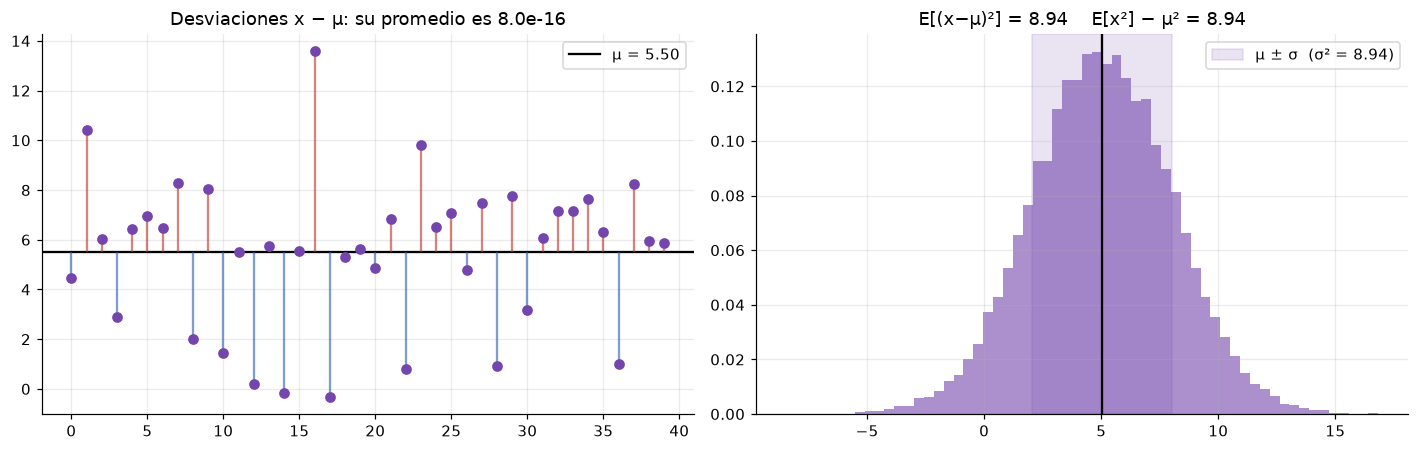

In [11]:
# Demostración 8: Varianza como momento centralizado
x = rng.normal(5, 3, 40); mu = x.mean()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].scatter(range(len(x)), x, color=C["mom"], zorder=3)
ax[0].axhline(mu, color="k", label=f"μ = {mu:.2f}")
ax[0].vlines(range(len(x)), mu, x, colors=np.where(x > mu, C["prob"], C["geo"]), alpha=0.6)
ax[0].set_title(f"Desviaciones x − μ: su promedio es {np.mean(x - mu):.1e}"); ax[0].legend()

g = rng.normal(5, 3, 20000); m, s = g.mean(), g.std()
ax[1].hist(g, bins=60, density=True, color=C["mom"], alpha=0.6)
ax[1].axvline(m, color="k"); ax[1].axvspan(m - s, m + s, color=C["mom"], alpha=0.15, label=f"μ ± σ  (σ² = {s**2:.2f})")
ax[1].set_title(f"E[(x−μ)²] = {np.mean((g - m)**2):.2f}    E[x²] − μ² = {np.mean(g**2) - m**2:.2f}")
ax[1].legend(); plt.tight_layout(); plt.show()

**Qué observar:** Las desviaciones rojas (positivas) y azules (negativas) se compensan: su promedio es 0. Por eso se elevan al cuadrado antes de promediar, y las dos fórmulas de la varianza dan el mismo número.

**Prueba a cambiar:** Cambia la desviación estándar en `rng.normal(5, 3, ...)` y mira cómo cambia el ancho de la banda.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Justificación.** ¿Por qué la varianza eleva las desviaciones al cuadrado?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque sin el cuadrado se cancelan.
2. **Por qué.** $\mathbb{E}\{x-\mu\}=0$ siempre.
3. **Con los datos.** Las desviaciones positivas y negativas se compensan: el primer momento centrado siempre da 0.

</details>

**Extremos.** ¿Qué pasa con la varianza si todos los datos son iguales?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Vale 0.
2. **Por qué.** Cada dato es igual a la media: $x-\mu=0$.
3. **Con los datos.** Es lo que pasa con los píxeles del borde de MNIST (demostración 31).

</details>

**Efecto de un cambio.** Si le sumo una constante a todos los datos, ¿afecta la varianza? ¿Y si los multiplico por $c$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Sumar no la afecta; multiplicar la multiplica por $c^2$.
2. **Por qué.** La media se desplaza igual que los datos, así que $x-\mu$ no cambia; al escalar, cada desviación se multiplica por $c$.
3. **Con los datos.** Aclarar todas las imágenes por igual no cambia su varianza.

</details>

## 9. Covarianza

**Resultado**

$$\operatorname{Cov}(x,y)=\mathbb{E}\{(x-\mu_x)(y-\mu_y)\}=\mathbb{E}\{xy\}-\mu_x\mu_y$$

**Idea:** Si cuando $x$ está por encima de su media $y$ también tiende a estarlo, los productos $(x-\mu_x)(y-\mu_y)$ son mayormente positivos. La covarianza promedia esos productos: mide cómo varían juntas.

**Qué muestra la gráfica:** Tres nubes de puntos coloreadas según el signo de $(x-\mu_x)(y-\mu_y)$, con las rectas de las medias.

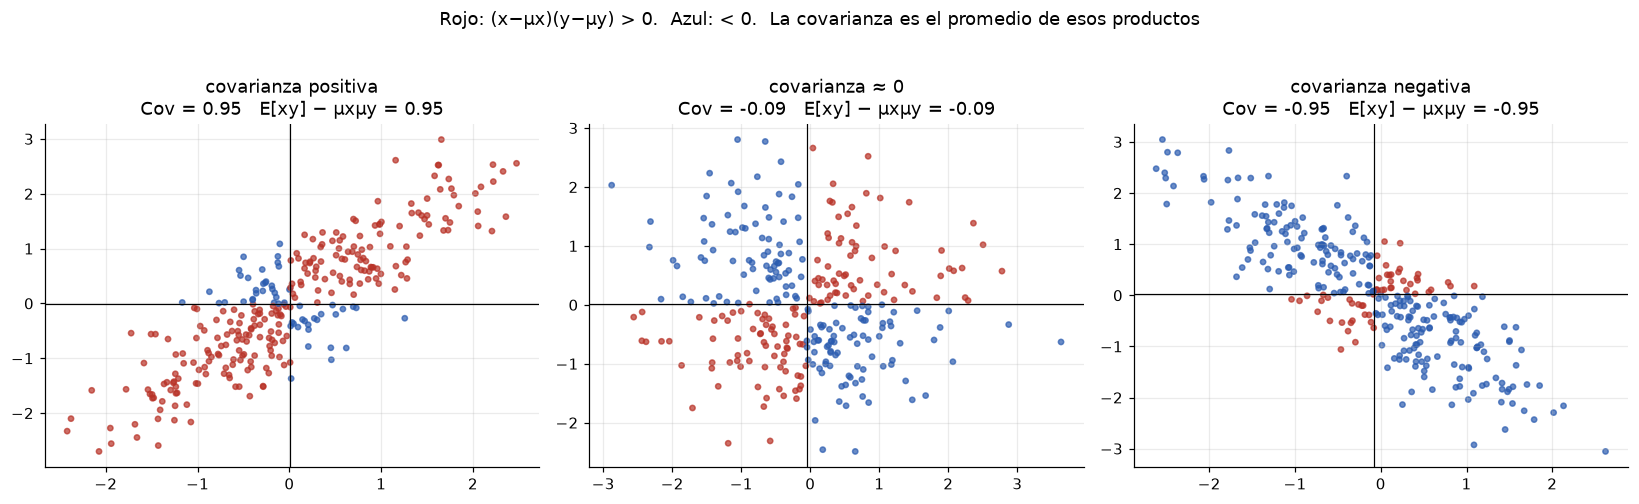

In [12]:
# Demostración 9: Covarianza
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
for a_, k, t in zip(ax, [1.0, 0.0, -1.0], ["covarianza positiva", "covarianza ≈ 0", "covarianza negativa"]):
    x = rng.normal(size=300); y = k * x + rng.normal(size=300) * (0.6 if k else 1.0)
    mx, my = x.mean(), y.mean(); prod = (x - mx) * (y - my)
    a_.scatter(x, y, c=np.where(prod > 0, C["prob"], C["geo"]), s=12, alpha=0.7)
    a_.axvline(mx, c="k", lw=0.8); a_.axhline(my, c="k", lw=0.8)
    a_.set_title(f"{t}\nCov = {prod.mean():.2f}   E[xy] − μxμy = {np.mean(x * y) - mx * my:.2f}")
fig.suptitle("Rojo: (x−μx)(y−μy) > 0.  Azul: < 0.  La covarianza es el promedio de esos productos", y=1.03)
plt.tight_layout(); plt.show()

**Qué observar:** Con covarianza positiva dominan los puntos rojos (cuadrantes I y III); con negativa, los azules; con covarianza cero se equilibran. Las dos fórmulas dan el mismo valor.

**Prueba a cambiar:** Usa `y = x**2` con `x` simétrica: la covarianza sale casi 0 aunque $y$ depende de $x$ (covarianza cero no implica independencia).

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Interpretación.** ¿Qué significa una covarianza positiva entre dos píxeles?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Que cuando uno se enciende, el otro tiende a encenderse.
2. **Por qué.** Dominan los productos $(x-\mu_x)(y-\mu_y)\gt 0$.
3. **Con los datos.** Dos píxeles vecinos por donde suele pasar el trazo.

</details>

**Justificación.** ¿Por qué una covarianza de 0 no garantiza independencia?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque solo mide relación lineal.
2. **Por qué.** Con $y=x^2$ y $x$ simétrica, la covarianza da 0 aunque $y$ depende de $x$.
3. **Con los datos.** La nube tiene forma de U: hay relación, pero no es una recta.

</details>

**Interpretación.** ¿Qué significa covarianza 0 en un píxel del borde?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Que ese píxel no varía.
2. **Por qué.** Siempre vale lo mismo, así que $(x-\mu)=0$ en cada imagen.
3. **Con los datos.** Vale 0 en todas las imágenes de MNIST.

</details>

## 10. Índice de correlación de Pearson como coseno

**Resultado**

$$\rho(x,y)=\frac{\operatorname{Cov}(x,y)}{\sqrt{\operatorname{Var}(x)\operatorname{Var}(y)}}=\frac{\langle x-\mu_x,\,y-\mu_y\rangle}{\|x-\mu_x\|\,\|y-\mu_y\|}=\cos\theta$$

**Idea:** La covarianza depende de las unidades (metros frente a centímetros). Pearson la normaliza: centrar, dividir por la norma, y lo que queda es un ángulo. Por eso siempre está entre $-1$ y $1$.

**Qué muestra la gráfica:** La nube de puntos y el ángulo entre los vectores centrados $x-\mu_x$ e $y-\mu_y$ (vistos como vectores de $N$ componentes).

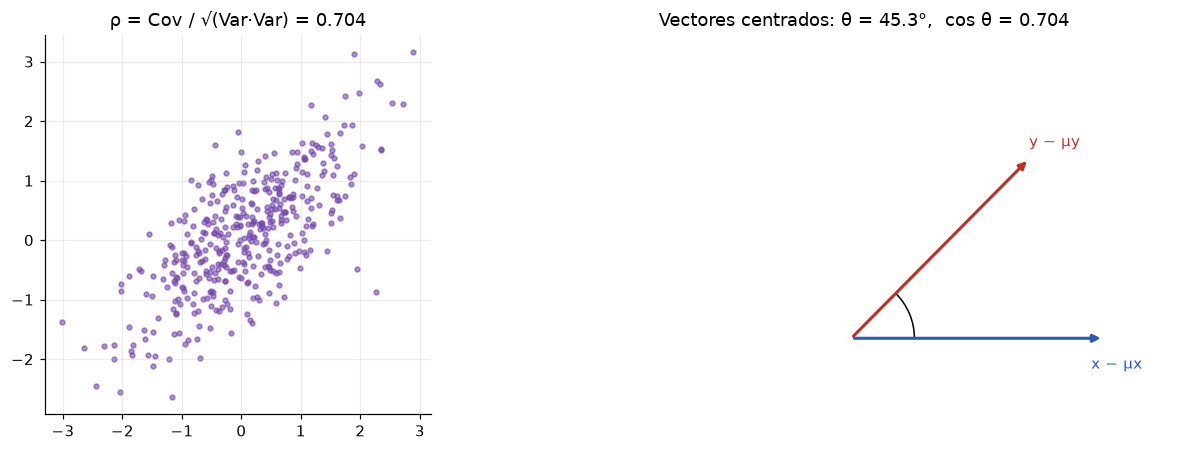

In [13]:
# Demostración 10: Índice de correlación de Pearson como coseno
def pearson(rho=0.7):
    x = rng.normal(size=400); y = rho * x + np.sqrt(1 - rho**2) * rng.normal(size=400)
    xc, yc = x - x.mean(), y - y.mean()
    cos = xc @ yc / (np.linalg.norm(xc) * np.linalg.norm(yc))
    th = np.arccos(np.clip(cos, -1, 1))
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
    ax[0].scatter(x, y, s=10, color=C["mom"], alpha=0.6); ax[0].set_aspect("equal")
    ax[0].set_title(f"ρ = Cov / √(Var·Var) = {np.corrcoef(x, y)[0, 1]:.3f}")
    ax[1].annotate("", xy=(1, 0), xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", lw=2, color=C["geo"]))
    ax[1].annotate("", xy=(np.cos(th), np.sin(th)), xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", lw=2, color=C["prob"]))
    ax[1].add_patch(Arc((0, 0), 0.5, 0.5, theta2=np.rad2deg(th)))
    ax[1].text(0.95, -0.12, "x − μx", color=C["geo"]); ax[1].text(np.cos(th), np.sin(th) + 0.05, "y − μy", color=C["prob"])
    ax[1].set_xlim(-1.2, 1.3); ax[1].set_ylim(-0.3, 1.2); ax[1].set_aspect("equal"); ax[1].axis("off")
    ax[1].set_title(f"Vectores centrados: θ = {np.rad2deg(th):.1f}°,  cos θ = {cos:.3f}")
    plt.tight_layout(); plt.show()

interactivo(pearson, rho=(-0.99, 0.99, 0.01, 0.7))

**Qué observar:** El coseno del ángulo es exactamente $\rho$: $\rho=1$ es un ángulo de 0°, $\rho=0$ es 90° y $\rho=-1$ es 180°.

**Prueba a cambiar:** Mueve el deslizador `rho` (en Colab o Jupyter aparece al ejecutar la celda).

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Extremos.** ¿Qué valores puede tomar $\rho$ y cuándo llega a 1 o a −1?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Entre −1 y 1. Llega a ±1 cuando una variable es una recta de la otra.
2. **Por qué.** $\rho$ es un coseno entre vectores centrados.
3. **Con los datos.** $\rho(x,x)=1$: la diagonal de la matriz de correlación.

</details>

**Justificación.** ¿Por qué se divide la covarianza entre las desviaciones estándar?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Para quitarle las unidades.
2. **Por qué.** La covarianza cambia con la escala; dividir la deja en $[-1,1]$.
3. **Con los datos.** Medir en centímetros o en metros da el mismo $\rho$.

</details>

**Efecto de un cambio.** Si multiplico $x$ por 100, ¿afecta $\rho$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** No.
2. **Por qué.** El 100 aparece arriba y abajo y se cancela.
3. **Con los datos.** La covarianza sí se multiplica por 100.

</details>

## 25. Media en forma matricial: Caso 1 y Caso 2

*En tus apuntes: págs. 28 y 30.*

**Resultado**

$$\mu=\frac1N\sum_{n=1}^{N}x_n=\frac1N\mathbf{1}_N^T\mathbb{X}\in\mathbb{R}^{1\times P}$$

$$\hat\mu=\frac1P\sum_{p=1}^{P}x_p=\frac1P\mathbb{X}\mathbf{1}_P\in\mathbb{R}^{N\times1}$$

$$\mu_{\mathcal H}=\frac1N\mathbf{1}_N^T\Phi(\mathbb{X})\in\mathbb{R}^{1\times Q}$$

**Idea:** La misma matriz se puede promediar en dos direcciones. Un vector de unos a la izquierda suma las filas: colapsa las $N$ imágenes en una imagen promedio. A la derecha suma las columnas: colapsa cada imagen en un solo número. Cuál usar depende de qué se considere observación y qué se considere variable.

**Qué muestra la gráfica:** Algunas imágenes de dígitos, la imagen promedio (Caso 1) y el brillo medio de cada imagen (Caso 2).

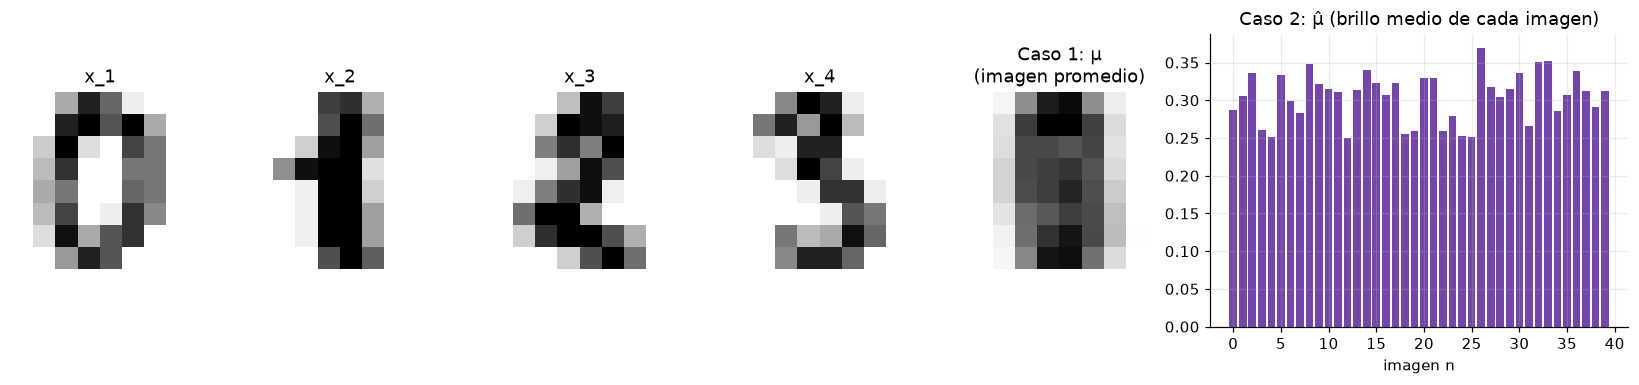

In [14]:
# Demostración 25: Media en forma matricial: Caso 1 y Caso 2
dig = load_digits()
Ximg = dig.images[:200].reshape(200, -1) / 16       # N = 200 imágenes, P = 64 píxeles
N, P = Ximg.shape
mu = np.ones(N) @ Ximg / N          # Caso 1: (1/N) 1ᵀX   (1×P)
mu_hat = Ximg @ np.ones(P) / P      # Caso 2: (1/P) X 1   (N×1)

fig = plt.figure(figsize=(15, 3.6))
for k in range(4):
    a_ = fig.add_subplot(1, 7, k + 1); a_.imshow(Ximg[k].reshape(8, 8), cmap="gray_r"); a_.axis("off"); a_.set_title(f"x_{k + 1}")
a_ = fig.add_subplot(1, 7, 5); a_.imshow(mu.reshape(8, 8), cmap="gray_r"); a_.axis("off"); a_.set_title("Caso 1: μ\n(imagen promedio)")
a_ = fig.add_subplot(1, 7, (6, 7)); a_.bar(range(40), mu_hat[:40], color=C["mom"])
a_.set_title("Caso 2: μ̂ (brillo medio de cada imagen)"); a_.set_xlabel("imagen n")
plt.tight_layout(); plt.show()

**Qué observar:** El Caso 1 conserva la forma de imagen ($1\times P$, se puede dibujar como imagen); el Caso 2 deja un solo número por imagen ($N\times1$).

**Prueba a cambiar:** Calcula la imagen promedio de un solo dígito, por ejemplo `dig.images[dig.target == 3]`.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Dimensiones.** Con $\mathbb{X}\in\mathbb{R}^{N\times784}$, ¿de qué tamaño son la media del Caso 1 y la del Caso 2?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $1\times784$ y $N\times1$.
2. **Por qué.** $\frac1N\mathbf{1}^T\mathbb{X}$ suma filas; $\frac1P\mathbb{X}\mathbf{1}$ suma columnas.
3. **Con los datos.** La primera se dibuja como imagen; la segunda es un número por imagen.

</details>

**Interpretación.** ¿Qué significa la imagen promedio?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Dónde suele haber trazo en todo el conjunto.
2. **Por qué.** Cada píxel es el promedio de ese píxel en todas las imágenes.
3. **Con los datos.** En MNIST es un borrón en el centro y negro en el borde.

</details>

**Efecto de un cambio.** Si reordeno las imágenes, ¿afecta la media del Caso 1?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** No.
2. **Por qué.** Una suma no depende del orden.
3. **Con los datos.** El orden sí importa para dibujar la matriz kernel por bloques (demostración 33).

</details>

## 11. Media y centrado en forma matricial

**Resultado**

$$\mu=\frac1P\,\mathbb{X}\mathbf{1}_P\in\mathbb{R}^{N\times1}$$

$$\mathbb{X}_c=\mathbb{X}-\frac1P\,\mathbb{X}\mathbf{1}_P\mathbf{1}_P^T$$

**Idea:** Multiplicar por un vector de unos es sumar. Después, $\mu\mathbf{1}^T$ copia la media en cada columna, así que se resta a toda la matriz de una vez, sin bucles.

**Qué muestra la gráfica:** La matriz $\mathbb{X}$, la matriz $\mu\mathbf{1}^T$ con la media copiada en cada columna y el resultado centrado.

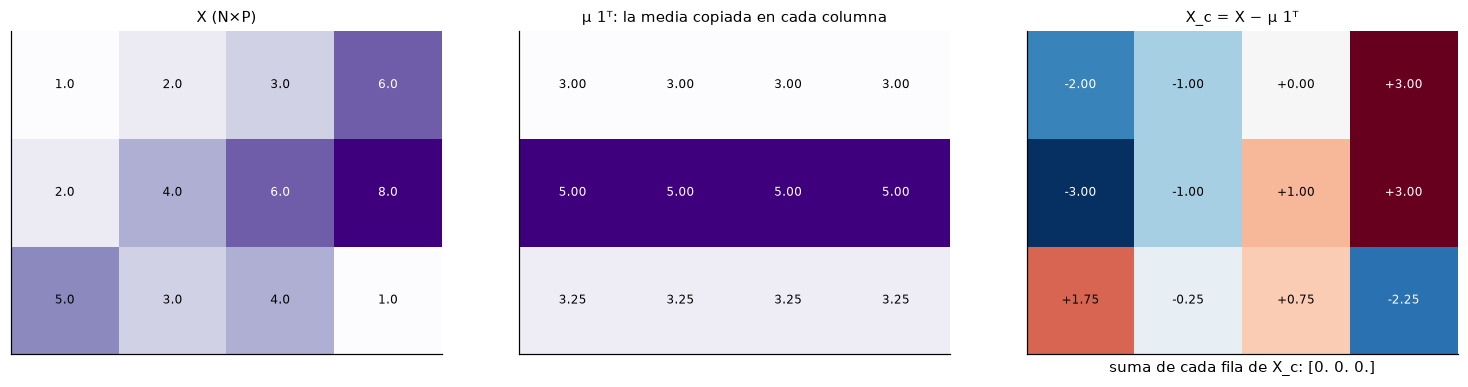

In [15]:
# Demostración 11: Media y centrado en forma matricial
X = np.array([[1, 2, 3, 6], [2, 4, 6, 8], [5, 3, 4, 1]], dtype=float)   # filas = variables
N, P = X.shape
mu = X @ np.ones(P) / P                       # (1/P) X 1_P
Xc = X - np.outer(mu, np.ones(P))             # X - μ 1ᵀ

fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
mapa_calor(ax[0], X, "X (N×P)", fmt="{:.1f}", cmap="Purples", centrado=False)
mapa_calor(ax[1], np.outer(mu, np.ones(P)), "μ 1ᵀ: la media copiada en cada columna", fmt="{:.2f}", cmap="Purples", centrado=False)
mapa_calor(ax[2], Xc, "X_c = X − μ 1ᵀ", fmt="{:+.2f}")
ax[2].set_xlabel(f"suma de cada fila de X_c: {Xc.sum(axis=1).round(10) + 0.0}")
plt.tight_layout(); plt.show()

**Qué observar:** Cada fila de $\mathbb{X}_c$ suma 0: el producto exterior $\mu\mathbf{1}^T$ resta la media de cada fila de una sola vez.

**Prueba a cambiar:** Cambia los valores de `X` y comprueba que las filas centradas siguen sumando 0.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Dimensiones.** ¿De qué tamaño es $\mu\mathbf{1}^T$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $N\times P$, el tamaño de $\mathbb{X}$.
2. **Por qué.** $(N\times1)(1\times P)$.
3. **Con los datos.** Copia la media de cada fila en todas sus columnas.

</details>

**Justificación.** ¿Por qué hace falta el producto exterior para restar la media?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque $\mu$ es un vector y $\mathbb{X}$ una matriz.
2. **Por qué.** Para restar, los dos deben tener el mismo tamaño; NumPy lo hace solo con *broadcasting*.
3. **Con los datos.** $\mathbb{X}-\mu\mathbf{1}^T$.

</details>

**Interpretación.** ¿Qué significa que cada fila de $\mathbb{X}_c$ sume 0?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Que los datos ya están centrados: no queda media.
2. **Por qué.** A cada valor se le restó la media de su fila.
3. **Con los datos.** Es el requisito para calcular la covarianza.

</details>

## 26. Covarianza matricial con el vector de unos (Review)

*En tus apuntes: págs. 28 a 31 (Review).*

**Resultado**

$$\operatorname{Cov}(\mathbb{X},\mathbb{X})=\mathbb{E}\{(\mathbb{X}-\mathbf{1}_N\mu)^T(\mathbb{X}-\mathbf{1}_N\mu)\}=\frac1N\mathbb{X}^T\mathbb{X}-\mu^T\mu\in\mathbb{R}^{P\times P}$$

**Idea:** Es la demostración 9, $\mathbb{E}\{xy\}-\mu_x\mu_y$, escrita para todas las variables a la vez. El truco es la identidad $\mathbb{X}^T\mathbf{1}_N=N\mu^T$: sumar las filas da $N$ veces la media. Con ella los tres términos con $\mu$ se reducen a uno solo.

**Qué muestra la gráfica:** Algunos productos exteriores $x_n^Tx_n$, su promedio $\frac1N\mathbb{X}^T\mathbb{X}$, la matriz $\mu^T\mu$ y la covarianza resultante.

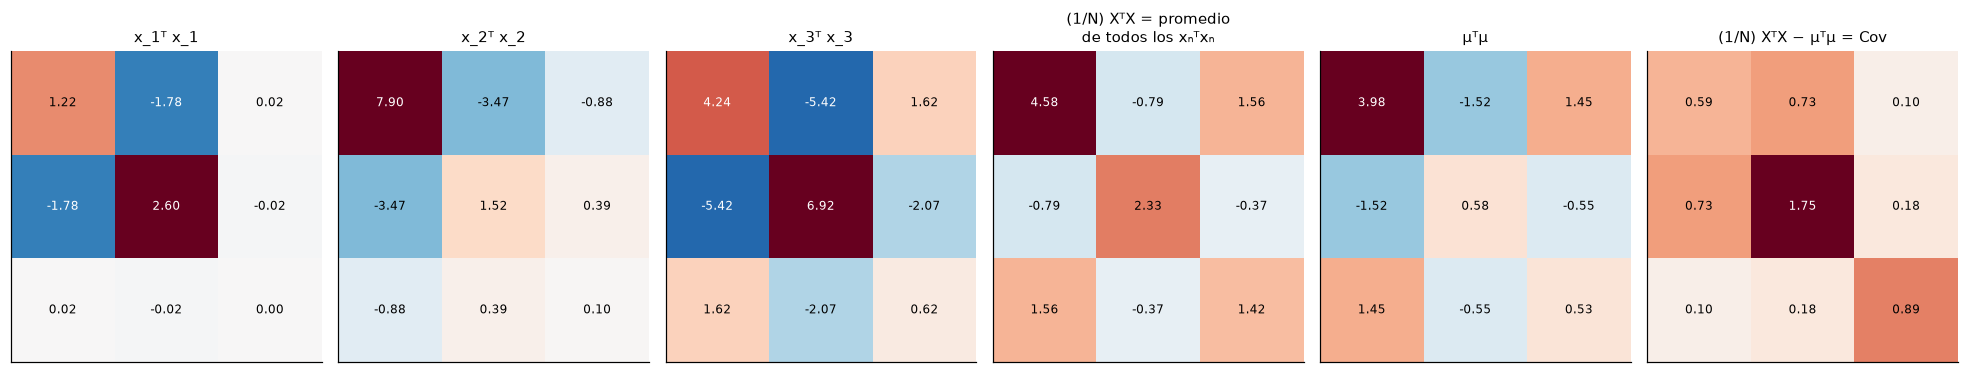

¿Igual a np.cov(X, rowvar=False, bias=True)? True


In [16]:
# Demostración 26: Covarianza matricial con el vector de unos (Review)
Xv = rng.normal(size=(50, 3)); Xv[:, 1] += 1.5 * Xv[:, 0]; Xv += [2, -1, 0.5]    # filas = muestras
N = len(Xv); mu = Xv.mean(0)
fig, ax = plt.subplots(1, 6, figsize=(18, 4))
for k in range(3):
    mapa_calor(ax[k], np.outer(Xv[k], Xv[k]), f"x_{k + 1}ᵀ x_{k + 1}")
mapa_calor(ax[3], Xv.T @ Xv / N, "(1/N) XᵀX = promedio\nde todos los xₙᵀxₙ")
mapa_calor(ax[4], np.outer(mu, mu), "μᵀμ")
mapa_calor(ax[5], Xv.T @ Xv / N - np.outer(mu, mu), "(1/N) XᵀX − μᵀμ = Cov")
plt.tight_layout(); plt.show()
print("¿Igual a np.cov(X, rowvar=False, bias=True)?",
      np.allclose(Xv.T @ Xv / N - np.outer(mu, mu), np.cov(Xv, rowvar=False, bias=True)))

**Qué observar:** $\frac1N\mathbb{X}^T\mathbb{X}$ es el promedio de los productos exteriores de cada muestra; al restar $\mu^T\mu$ desaparece el efecto de la media y queda la covarianza.

**Prueba a cambiar:** Cambia el `1.5` que relaciona las columnas 0 y 1 y mira la entrada (0, 1) de la covarianza.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Justificación.** ¿Por qué $\mathbb{X}^T\mathbf{1}_N=N\mu^T$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque sumar las filas da $N$ veces su promedio.
2. **Por qué.** $\mu=\frac1N\mathbf{1}^T\mathbb{X}$; se transpone y se multiplica por $N$.
3. **Con los datos.** Es lo que reduce los tres términos con $\mu$ a uno solo.

</details>

**Dimensiones.** ¿De qué tamaño es $\mathbb{X}^T\mathbf{1}_N\mu$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $P\times P$.
2. **Por qué.** $(P\times N)(N\times1)(1\times P)$.
3. **Con los datos.** Igual que los otros tres términos de la expansión.

</details>

**Leer la matriz o gráfica.** Si $\mathbb{X}^T\mathbb{X}=\sum_nx_n^Tx_n$, ¿qué aporta cada imagen?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Su producto exterior, una matriz $P\times P$.
2. **Por qué.** Cada imagen dice qué pares de píxeles se encienden juntos en ella.
3. **Con los datos.** La suma de todas es la base de la covarianza.

</details>

## 12. Matriz de covarianza y varianza total

**Resultado**

$$\operatorname{Cov}(\mathbb{X},\mathbb{X})=\frac1P\,\mathbb{X}_c\mathbb{X}_c^T\in\mathbb{R}^{N\times N}$$

$$\operatorname{Tr}(\operatorname{Cov})=\sum_n\operatorname{Var}(x_n)$$

*Ojo con la convención:* aquí las filas de $\mathbb{X}$ son variables (como en la demostración 11), por eso la covarianza es $N\times N$ y se divide entre $P$. Con filas = observaciones, como en el código y en MNIST, es $\frac1N\mathbb{X}_c^T\mathbb{X}_c\in\mathbb{R}^{P\times P}$ (demostración 26).

**Idea:** Cada entrada de $\mathbb{X}_c\mathbb{X}_c^T$ es un producto interno entre dos filas centradas, que es $P$ veces una covarianza. Una sola multiplicación calcula todas las covarianzas a la vez.

**Qué muestra la gráfica:** Datos en 2D con las elipses de su covarianza, la matriz $\Sigma$ y la matriz de correlación.

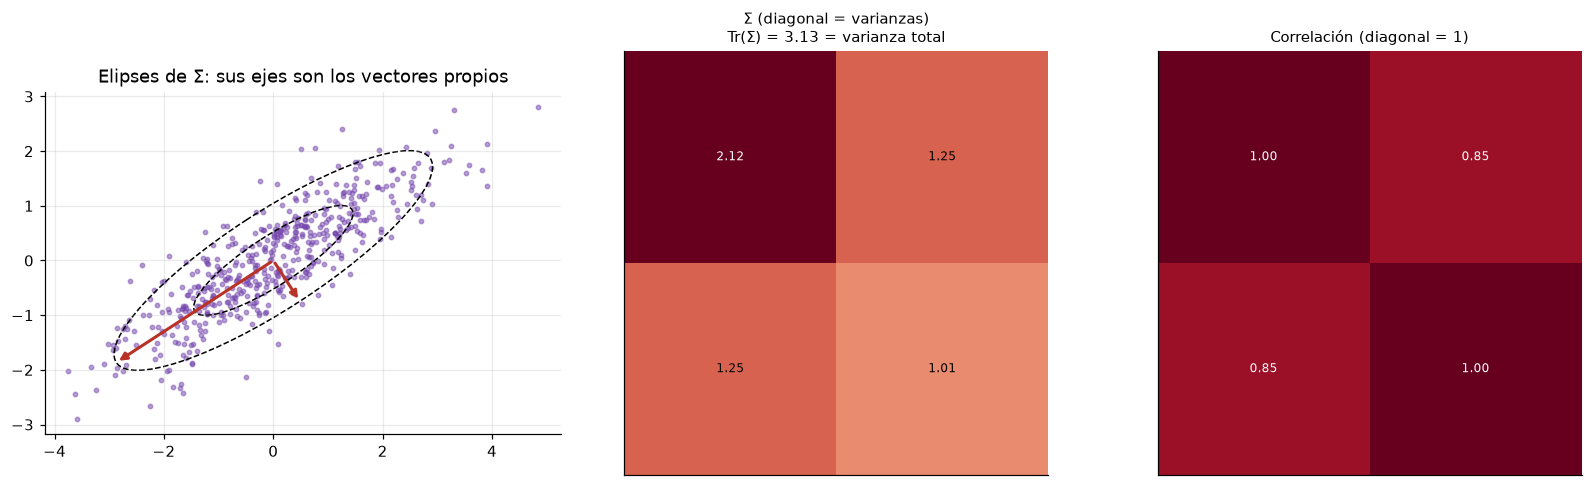

In [17]:
# Demostración 12: Matriz de covarianza y varianza total
Sigma_real = np.array([[2.0, 1.2], [1.2, 1.0]])
Xd = rng.multivariate_normal([0, 0], Sigma_real, 500)          # filas = observaciones
S = np.cov(Xd, rowvar=False, bias=True)
val, vec = np.linalg.eigh(S)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
ax[0].scatter(*Xd.T, s=8, alpha=0.5, color=C["mom"])
ang = np.degrees(np.arctan2(vec[1, 1], vec[0, 1]))
for k in [1, 2]:
    ax[0].add_patch(Ellipse((0, 0), 2 * k * np.sqrt(val[1]), 2 * k * np.sqrt(val[0]), angle=ang, fill=False, color="k", ls="--"))
for v, l in zip(vec.T, val):
    ax[0].annotate("", xy=2 * np.sqrt(l) * v, xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", color=C["prob"], lw=2))
ax[0].set_aspect("equal"); ax[0].set_title("Elipses de Σ: sus ejes son los vectores propios")
mapa_calor(ax[1], S, f"Σ (diagonal = varianzas)\nTr(Σ) = {np.trace(S):.2f} = varianza total")
R = S / np.sqrt(np.outer(np.diag(S), np.diag(S)))
mapa_calor(ax[2], R, "Correlación (diagonal = 1)")
plt.tight_layout(); plt.show()

**Qué observar:** Los ejes de la elipse son los vectores propios de $\Sigma$ (las componentes principales de PCA) y su largo depende de los valores propios. La traza suma las varianzas.

**Prueba a cambiar:** Cambia la covarianza `1.2` de `Sigma_real` por `-1.2` o por `0` y mira cómo gira o se endereza la elipse.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Dimensiones.** Con imágenes de 784 píxeles, ¿de qué tamaño es la matriz de covarianza?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $784\times784$.
2. **Por qué.** Relaciona cada píxel con cada píxel: $\frac1N\mathbb{X}_c^T\mathbb{X}_c$ con filas = imágenes.
3. **Con los datos.** No depende de cuántas imágenes haya.

</details>

**Leer la matriz o gráfica.** ¿Qué hay en la diagonal y qué hay fuera de ella?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** En la diagonal, las varianzas; fuera, las covarianzas.
2. **Por qué.** La entrada $(i,i)$ compara un píxel consigo mismo.
3. **Con los datos.** En MNIST, la diagonal reacomodada a $28\times28$ es la imagen de varianza (demostración 32).

</details>

**Interpretación.** ¿Qué significa la traza de la covarianza?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** La varianza total.
2. **Por qué.** Es la suma de las varianzas de todas las variables.
3. **Con los datos.** Mide cuánto se dispersan las imágenes en conjunto.

</details>

## 27. Ejemplo numérico de covarianza (1 de octubre)

*En tus apuntes: pág. 32 (1 de octubre).*

**Resultado**

$$\mathbb{X}=\begin{bmatrix}1&1&1&1\\2&2&2&2\\3&3&3&3\end{bmatrix},\quad\mu=[2\ 2\ 2\ 2]$$

$$\mathbb{X}_c^T\mathbb{X}_c=2\mathbf{J},\quad\operatorname{Cov}=\tfrac23\,\mathbf{J}$$

$$\mathbf{J}=\mathbf{1}_4\mathbf{1}_4^T$$

**Idea:** Cada fila es constante, pero cada columna sí cambia (vale 1, 2 y 3). Por eso la respuesta depende de qué se considere variable. Entre columnas (Caso 1) hay covarianza y es igual para todos los pares, porque las cuatro columnas son idénticas. Entre filas (Caso 2) la covarianza es cero, porque ninguna fila varía.

**Qué muestra la gráfica:** La matriz del ejemplo, los bloques $(x_i-\mu)^T(x_j-\mu)$ y las tres respuestas de `np.cov` según sus opciones.

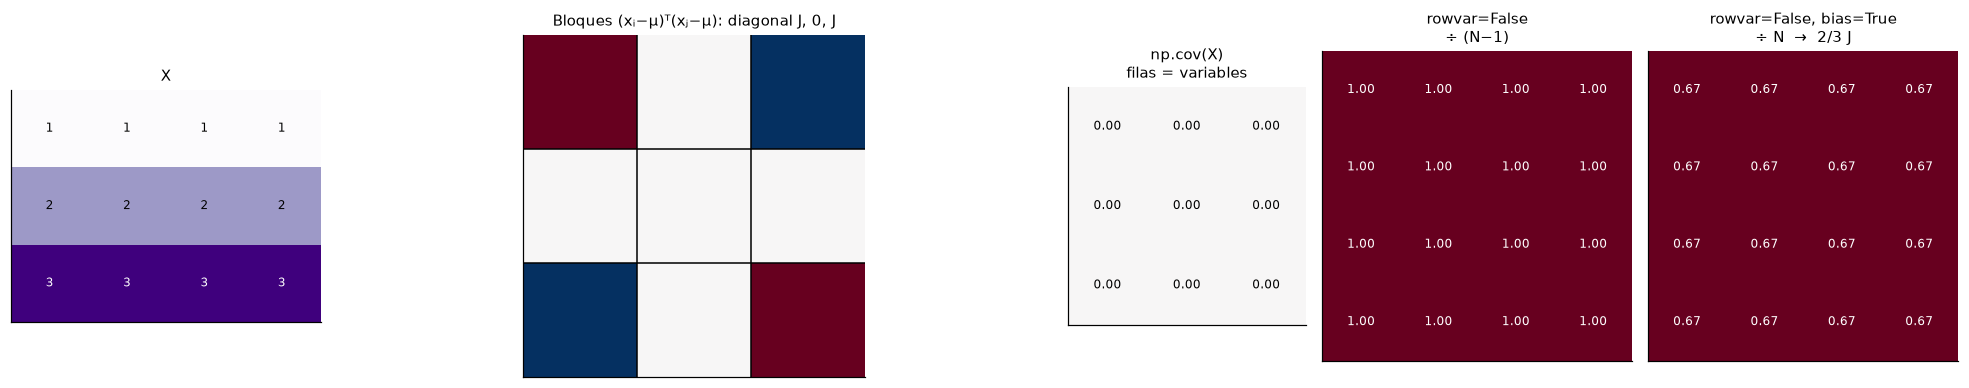

In [18]:
# Demostración 27: Ejemplo numérico de covarianza (1 de octubre)
E_ = np.array([[1, 1, 1, 1], [2, 2, 2, 2], [3, 3, 3, 3]], dtype=float)
m = E_.mean(0); d = E_ - m
bloques = np.block([[np.outer(d[i], d[j]) for j in range(3)] for i in range(3)])
fig, ax = plt.subplots(1, 5, figsize=(18, 3.6), gridspec_kw={"width_ratios": [1.3, 3, 1, 1.3, 1.3]})
mapa_calor(ax[0], E_, "X", fmt="{:.0f}", cmap="Purples", centrado=False)
mapa_calor(ax[1], bloques, "Bloques (xᵢ−μ)ᵀ(xⱼ−μ): diagonal J, 0, J", anotar=False)
for t in [3.5, 7.5]:
    ax[1].axhline(t, c="k", lw=1); ax[1].axvline(t, c="k", lw=1)
mapa_calor(ax[2], np.cov(E_), "np.cov(X)\nfilas = variables", fmt="{:.2f}")
mapa_calor(ax[3], np.cov(E_, rowvar=False), "rowvar=False\n÷ (N−1)", fmt="{:.2f}")
mapa_calor(ax[4], np.cov(E_, rowvar=False, bias=True), "rowvar=False, bias=True\n÷ N  →  2/3 J", fmt="{:.2f}")
plt.tight_layout(); plt.show()

**Qué observar:** Solo los bloques de la diagonal aportan ($\mathbf{J}$, 0 y $\mathbf{J}$). `np.cov` da ceros, $\mathbf{J}$ o $\frac23\mathbf{J}$ para los mismos datos, según qué considere variable y si divide entre $N$ o $N-1$.

**Prueba a cambiar:** Cambia una fila para que no sea constante, por ejemplo `[1, 2, 1, 2]`, y mira cómo cambia `np.cov(X)`.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Justificación.** ¿Por qué la covarianza entre filas da 0 en el ejemplo?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque cada fila es constante.
2. **Por qué.** Al restarle su media, cada fila queda en 0.
3. **Con los datos.** $\mathbb{X}-\hat\mu\mathbf{1}^T=0$.

</details>

**Efecto de un cambio.** ¿Afecta usar `np.cov` con `rowvar` y `bias`?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Sí: da ceros, $\mathbf{J}$ o $\frac23\mathbf{J}$.
2. **Por qué.** Cambia qué se toma como variable y si se divide entre $N$ o $N-1$.
3. **Con los datos.** Es la advertencia sobre Python de tus apuntes.

</details>

**Leer la matriz o gráfica.** En la matriz de bloques, ¿por qué solo aportan los de la diagonal?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque la covarianza suma cada muestra consigo misma.
2. **Por qué.** $\sum_n(x_n-\mu)^T(x_n-\mu)$ no incluye los cruces entre muestras distintas.
3. **Con los datos.** $\mathbf{J}+0+\mathbf{J}=2\mathbf{J}$.

</details>

# Gaussiana y máxima verosimilitud

## 13. Gaussiana: el valor esperado es μ

**Resultado**

$$\mathcal{N}(x\mid\mu,\sigma^2)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\Big\{-\frac{(x-\mu)^2}{2\sigma^2}\Big\}$$

$$\mathbb{E}\{x\}=\mu$$

**Idea:** La campana es simétrica alrededor de $\mu$: lo que sobra a la derecha compensa lo que falta a la izquierda. El cambio de variable lleva todo a una normal estándar centrada en 0, donde esa simetría hace que la integral impar valga cero.

**Qué muestra la gráfica:** La gaussiana simétrica alrededor de $\mu$ y la función impar $z\varphi(z)$ que aparece tras el cambio de variable.

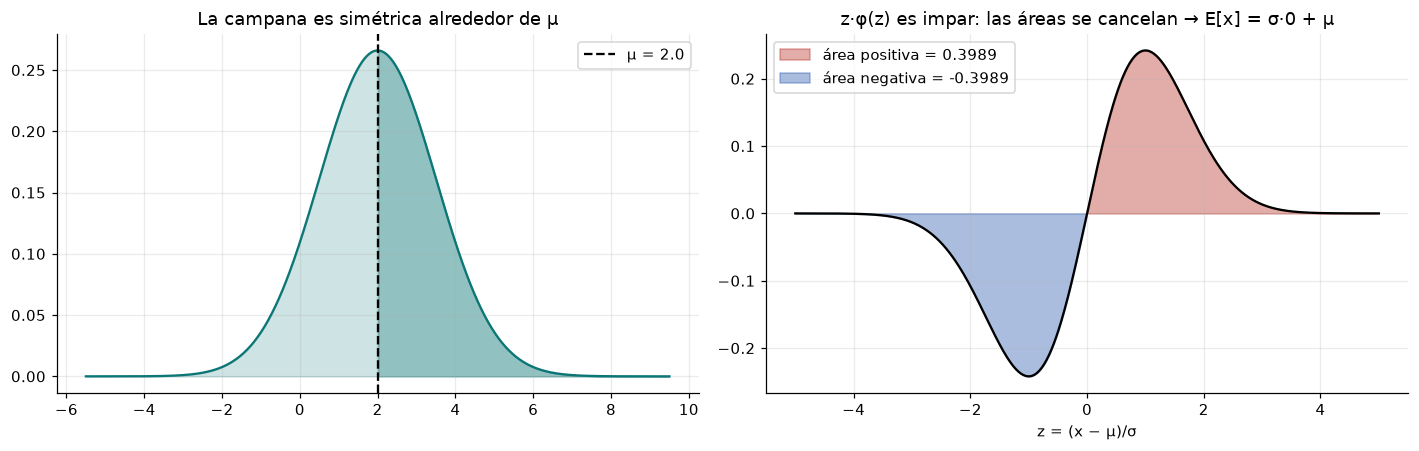

In [19]:
# Demostración 13: Gaussiana: el valor esperado es μ
mu, s = 2.0, 1.5
z = np.linspace(-5, 5, 500); x = mu + s * z
g = z * norm.pdf(z)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(x, norm.pdf(x, mu, s), color=C["gauss"])
ax[0].fill_between(x, norm.pdf(x, mu, s), where=x < mu, color=C["gauss"], alpha=0.2)
ax[0].fill_between(x, norm.pdf(x, mu, s), where=x >= mu, color=C["gauss"], alpha=0.45)
ax[0].axvline(mu, ls="--", c="k", label=f"μ = {mu}"); ax[0].legend(); ax[0].set_title("La campana es simétrica alrededor de μ")
pos, neg = z > 0, z < 0
ax[1].plot(z, g, color="k")
ax[1].fill_between(z, g, where=pos, color=C["prob"], alpha=0.4, label=f"área positiva = {integral(g[pos], z[pos]):.4f}")
ax[1].fill_between(z, g, where=neg, color=C["geo"], alpha=0.4, label=f"área negativa = {integral(g[neg], z[neg]):.4f}")
ax[1].set_xlabel("z = (x − μ)/σ"); ax[1].legend(); ax[1].set_title("z·φ(z) es impar: las áreas se cancelan → E[x] = σ·0 + μ")
plt.tight_layout(); plt.show()

**Qué observar:** Las áreas positiva y negativa de $z\varphi(z)$ son iguales y se cancelan; solo sobrevive $\mu\int\varphi=\mu$.

**Prueba a cambiar:** Cambia `mu` y `s`: la cancelación no depende de ellos, porque después del cambio de variable siempre se integra lo mismo.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Justificación.** ¿Por qué la integral de $z\varphi(z)$ vale 0?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque es una función impar.
2. **Por qué.** Por la simetría, el área positiva es igual a la negativa.
3. **Con los datos.** El código de esta demostración lo comprueba: $\int z\varphi(z)\,dz$ da 0.

</details>

**Interpretación.** ¿Qué significa $\mu$ en la gaussiana?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** El centro de la campana y su valor esperado.
2. **Por qué.** $\mathbb{E}\{x\}=\mu$.
3. **Con los datos.** Por eso se estima con el promedio (demostración 15).

</details>

**Efecto de un cambio.** ¿Afecta $\sigma$ al valor esperado?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** No.
2. **Por qué.** $\sigma$ multiplica la parte impar, que vale 0.
3. **Con los datos.** Campanas anchas o estrechas pueden tener el mismo centro.

</details>

## 14. Gaussiana: segundo momento y varianza

**Resultado**

$$\mathbb{E}\{x^2\}=\mu^2+\sigma^2$$

$$\operatorname{Var}(x)=\sigma^2$$

**Idea:** Es el mismo cambio de variable. El único término nuevo, $\int z^2e^{-z^2/2}dz$, se resuelve por partes; el término de borde desaparece porque la exponencial cae más rápido de lo que cualquier polinomio crece.

**Qué muestra la gráfica:** El integrando $z^2\varphi(z)$, el término de borde de la integración por partes y la comparación entre $\mathbb{E}\{x^2\}$ y $\mu^2+\sigma^2$.

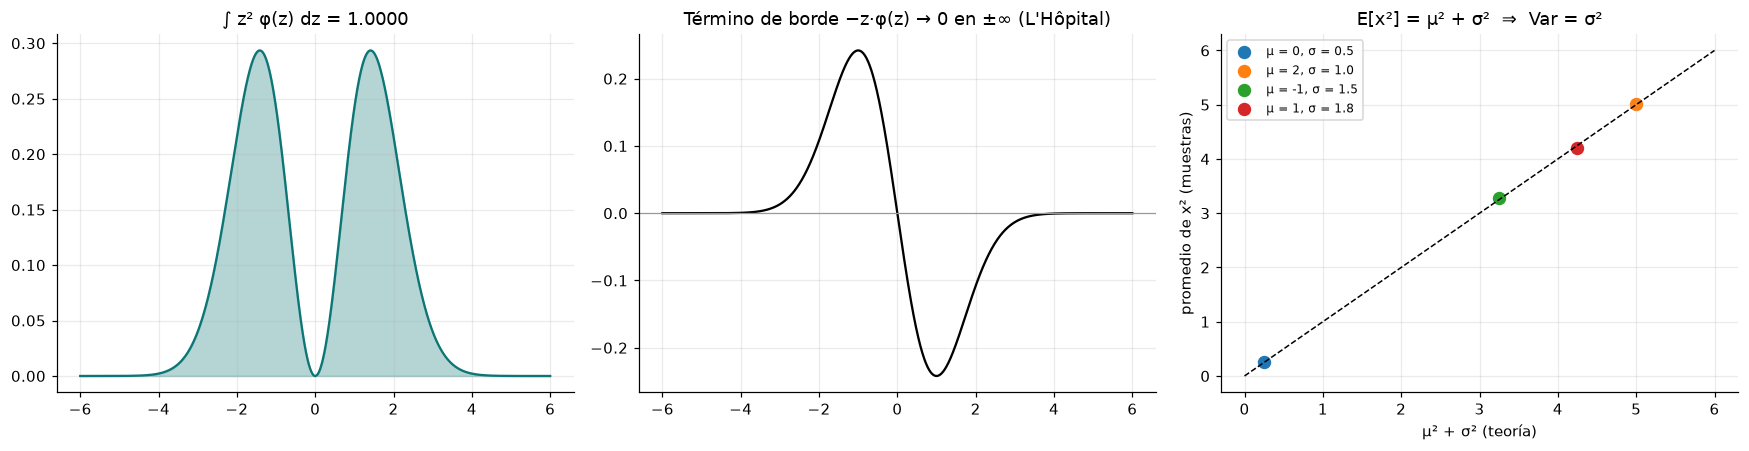

In [20]:
# Demostración 14: Gaussiana: segundo momento y varianza
z = np.linspace(-6, 6, 1200); phi = norm.pdf(z)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].plot(z, z**2 * phi, color=C["gauss"]); ax[0].fill_between(z, z**2 * phi, color=C["gauss"], alpha=0.3)
ax[0].set_title(f"∫ z² φ(z) dz = {integral(z**2 * phi, z):.4f}")
ax[1].plot(z, -z * phi, color="k"); ax[1].axhline(0, c="0.6", lw=0.8)
ax[1].set_title("Término de borde −z·φ(z) → 0 en ±∞ (L'Hôpital)")
for m, s_ in [(0, 0.5), (2, 1.0), (-1, 1.5), (1, 1.8)]:
    xs = rng.normal(m, s_, 20000)
    ax[2].scatter(m**2 + s_**2, np.mean(xs**2), s=60, label=f"μ = {m}, σ = {s_}")
ax[2].plot([0, 6], [0, 6], "k--", lw=1)
ax[2].set_xlabel("μ² + σ² (teoría)"); ax[2].set_ylabel("promedio de x² (muestras)"); ax[2].legend(fontsize=8)
ax[2].set_title("E[x²] = μ² + σ²  ⇒  Var = σ²")
plt.tight_layout(); plt.show()

**Qué observar:** El área bajo $z^2\varphi(z)$ es 1, el borde $-z\varphi(z)$ se anula en los extremos y los puntos simulados caen sobre la diagonal.

**Prueba a cambiar:** Agrega otras parejas de $\mu$ y $\sigma$ a la lista del tercer panel.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Justificación.** ¿Por qué el término de borde $-z\varphi(z)$ se anula?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque la exponencial cae más rápido de lo que crece $z$.
2. **Por qué.** Por L'Hôpital, $\frac{z}{e^{z^2/2}}\to0$.
3. **Con los datos.** El código lo muestra: $z\varphi(z)$ ya es casi 0 en $z=5$.

</details>

**Interpretación.** ¿Qué significa $\mathbb{E}\{x^2\}=\mu^2+\sigma^2$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Que el segundo momento junta el centro y la dispersión.
2. **Por qué.** $\operatorname{Var}=\mathbb{E}\{x^2\}-\mu^2$.
3. **Con los datos.** Con $\mu=2$ y $\sigma=1$, $\mathbb{E}\{x^2\}=5$.

</details>

**Extremos.** ¿Qué pasa si $\sigma\to0$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $\mathbb{E}\{x^2\}\to\mu^2$: la campana se vuelve un punto.
2. **Por qué.** No queda dispersión.
3. **Con los datos.** La precisión $\beta=1/\sigma^2$ tiende a infinito.

</details>

## 15. Máxima verosimilitud de μ

**Resultado**

$$\max_{\mu}\prod_{n=1}^{N}\mathcal{N}(x_n\mid\mu,\sigma^2)\;\Longrightarrow\;\mu_{ML}=\frac1N\sum_{n=1}^{N}x_n$$

**Idea:** Se busca el $\mu$ que hace más probables los datos observados, el que le cuadra a la mayoría de los datos. El logaritmo no mueve el máximo y convierte un producto difícil en una suma fácil de derivar.

**Qué muestra la gráfica:** La log-verosimilitud como función de $\mu$ y tres gaussianas candidatas sobre el histograma de los datos.

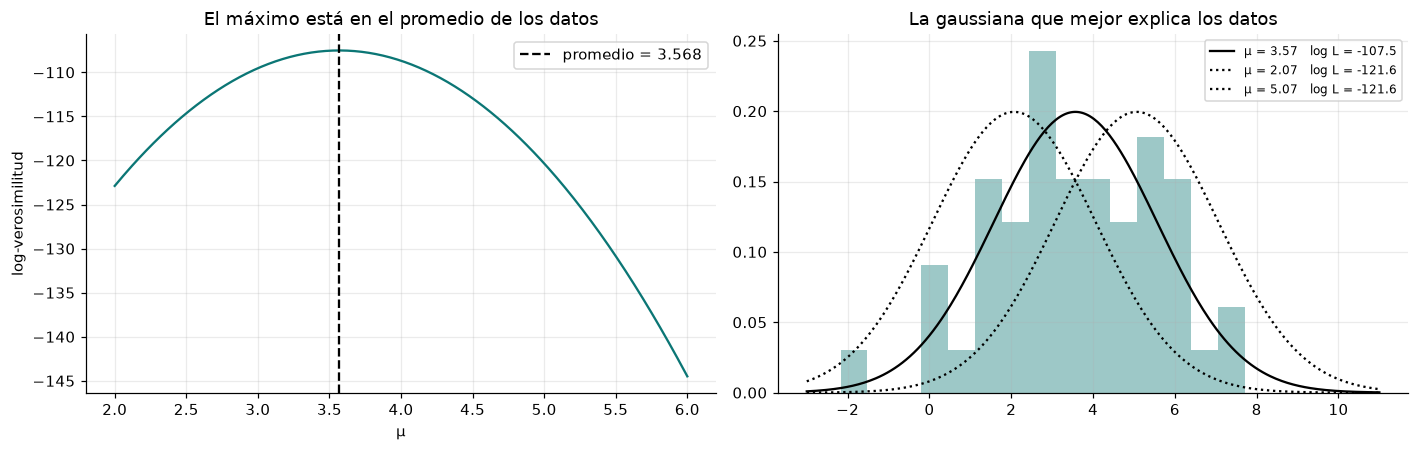

In [21]:
# Demostración 15: Máxima verosimilitud de μ
x = rng.normal(4, 2, 50)
mus = np.linspace(2, 6, 400)
logL = np.array([norm.logpdf(x, m, 2).sum() for m in mus])
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(mus, logL, color=C["gauss"]); ax[0].axvline(x.mean(), ls="--", c="k", label=f"promedio = {x.mean():.3f}")
ax[0].set_xlabel("μ"); ax[0].set_ylabel("log-verosimilitud"); ax[0].legend(); ax[0].set_title("El máximo está en el promedio de los datos")
xx = np.linspace(-3, 11, 300)
ax[1].hist(x, bins=15, density=True, alpha=0.4, color=C["gauss"])
for m, estilo in [(x.mean(), "-"), (x.mean() - 1.5, ":"), (x.mean() + 1.5, ":")]:
    ax[1].plot(xx, norm.pdf(xx, m, 2), estilo, color="k", label=f"μ = {m:.2f}   log L = {norm.logpdf(x, m, 2).sum():.1f}")
ax[1].legend(fontsize=8); ax[1].set_title("La gaussiana que mejor explica los datos")
plt.tight_layout(); plt.show()

**Qué observar:** El máximo de la curva cae justo en el promedio. Las gaussianas desplazadas explican peor los datos y tienen menor $\log L$.

**Prueba a cambiar:** Usa solo 5 datos (`rng.normal(4, 2, 5)`) y mira cuánto se aleja el máximo del valor real 4.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Justificación.** ¿Por qué se puede maximizar el logaritmo en vez de la verosimilitud?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque el logaritmo es creciente: no mueve el máximo.
2. **Por qué.** Además convierte el producto en suma, que es fácil de derivar.
3. **Con los datos.** La curva de log L tiene su máximo en el mismo $\mu$.

</details>

**Interpretación.** ¿Qué significa que $\mu_{ML}$ sea el promedio?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Que el promedio es el centro que hace más probables los datos.
2. **Por qué.** Es donde la derivada de la log-verosimilitud vale 0.
3. **Con los datos.** Es la gaussiana que mejor se ajusta al histograma.

</details>

**Extremos.** ¿Qué pasa con $\mu_{ML}$ si hay muy pocos datos?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Puede quedar lejos de la media real.
2. **Por qué.** Su varianza es $\sigma^2/N$.
3. **Con los datos.** Con 5 datos el máximo se mueve mucho más que con 50.

</details>

## 16. Máxima verosimilitud de σ²

**Resultado**

$$\sigma^2_{ML}=\frac1N\sum_{n=1}^{N}(x_n-\mu_{ML})^2$$

**Idea:** Mismo principio, ahora con $\sigma^2$ como incógnita, y el resultado es la varianza de los datos. Como $\mu_{ML}$ se calcula con esos mismos datos, queda pegada a ellos y subestima la dispersión: de ahí el sesgo.

**Qué muestra la gráfica:** La log-verosimilitud como función de $\sigma^2$ y el sesgo de $\sigma^2_{ML}$ según el número de datos.

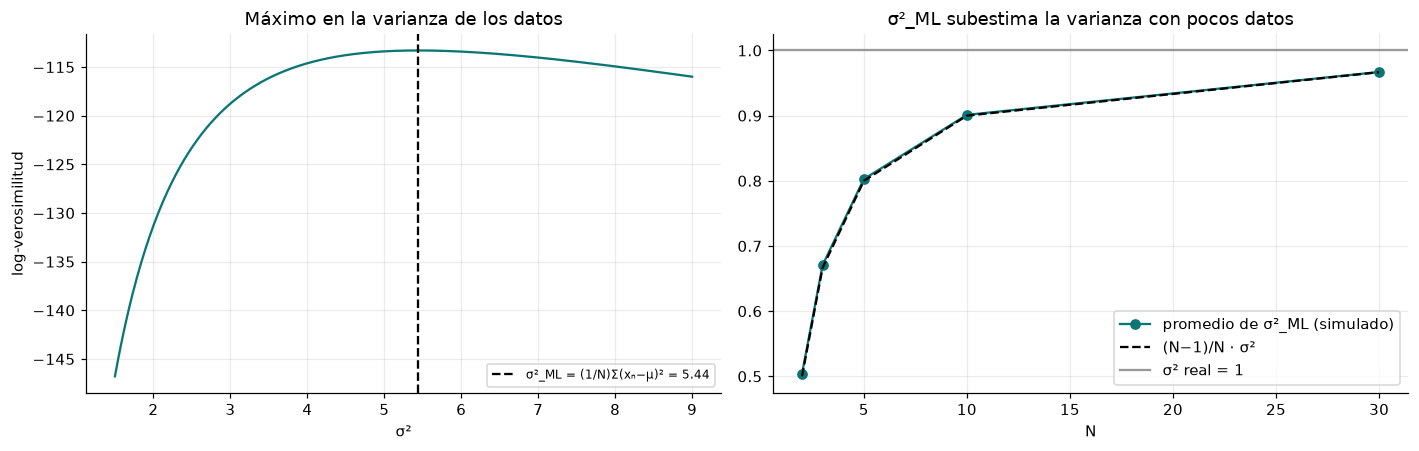

In [22]:
# Demostración 16: Máxima verosimilitud de σ²
x = rng.normal(4, 2, 50); m = x.mean()
s2s = np.linspace(1.5, 9, 400)
logL = np.array([norm.logpdf(x, m, np.sqrt(v)).sum() for v in s2s])
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(s2s, logL, color=C["gauss"]); ax[0].axvline(x.var(), ls="--", c="k", label=f"σ²_ML = (1/N)Σ(xₙ−μ)² = {x.var():.2f}")
ax[0].set_xlabel("σ²"); ax[0].set_ylabel("log-verosimilitud"); ax[0].legend(fontsize=8); ax[0].set_title("Máximo en la varianza de los datos")
Ns = [2, 3, 5, 10, 30]
promedio = [rng.normal(0, 1, (20000, n)).var(axis=1).mean() for n in Ns]
ax[1].plot(Ns, promedio, "o-", color=C["gauss"], label="promedio de σ²_ML (simulado)")
ax[1].plot(Ns, [(n - 1) / n for n in Ns], "k--", label="(N−1)/N · σ²")
ax[1].axhline(1, c="0.6", label="σ² real = 1"); ax[1].set_xlabel("N"); ax[1].legend()
ax[1].set_title("σ²_ML subestima la varianza con pocos datos")
plt.tight_layout(); plt.show()

**Qué observar:** El máximo está en la varianza de los datos. Con $N$ pequeño el promedio de $\sigma^2_{ML}$ queda por debajo de 1 y sigue la curva $(N-1)/N$.

**Prueba a cambiar:** Cambia `var(axis=1)` por `var(axis=1, ddof=1)` y mira cómo desaparece el sesgo.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Justificación.** ¿Por qué $\sigma^2_{ML}$ está sesgado?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque usa $\mu_{ML}$, que sale de los mismos datos.
2. **Por qué.** El promedio queda pegado a los datos y subestima la dispersión: $\mathbb{E}\{\sigma^2_{ML}\}=\frac{N-1}{N}\sigma^2$.
3. **Con los datos.** Con $N=3$, en promedio da $\frac23$ de la varianza real.

</details>

**Efecto de un cambio.** ¿Afecta dividir entre $N$ o entre $N-1$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Con muchos datos casi no; con pocos, sí.
2. **Por qué.** La diferencia es el factor $\frac{N}{N-1}$.
3. **Con los datos.** `np.var` divide entre $N$; `np.cov`, entre $N-1$ (demostración 27).

</details>

**Extremos.** ¿Qué pasa con el sesgo si $N\to\infty$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Desaparece.
2. **Por qué.** $\frac{N-1}{N}\to1$.
3. **Con los datos.** Con 30 datos ya es casi 1.

</details>

# Regresión

## 17. Mínimos cuadrados

**Resultado**

$$\min_w\|y-\mathbb{X}w\|_2^2\;\Longrightarrow\;w=(\mathbb{X}^T\mathbb{X})^{-1}\mathbb{X}^Ty$$

**Idea:** El error cuadrático es una parábola en varias dimensiones (función convexa): tiene un único fondo y en el fondo la pendiente es cero. Resolver gradiente igual a cero da la fórmula cerrada.

**Qué muestra la gráfica:** La recta ajustada con sus residuos y las curvas de nivel del error $J(w)$ en el plano de los pesos.

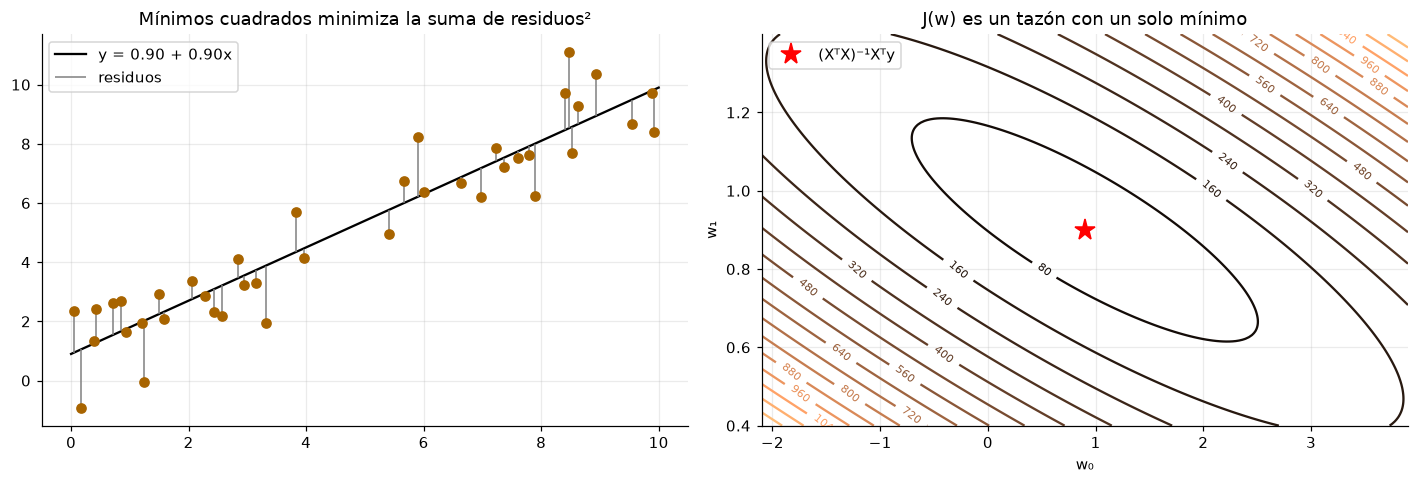

In [23]:
# Demostración 17: Mínimos cuadrados
N = 40
x = rng.uniform(0, 10, N); y = 1.5 + 0.8 * x + rng.normal(0, 1.2, N)
X = np.c_[np.ones(N), x]
w = np.linalg.solve(X.T @ X, X.T @ y)                 # (XᵀX)⁻¹ Xᵀ y
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(x, y, color=C["reg"], zorder=3)
xx = np.array([0, 10]); ax[0].plot(xx, w[0] + w[1] * xx, "k", label=f"y = {w[0]:.2f} + {w[1]:.2f}x")
ax[0].vlines(x, y, X @ w, color="0.5", lw=1, label="residuos")
ax[0].legend(); ax[0].set_title("Mínimos cuadrados minimiza la suma de residuos²")
w0, w1 = np.meshgrid(np.linspace(w[0] - 3, w[0] + 3, 200), np.linspace(w[1] - 0.5, w[1] + 0.5, 200))
J = ((y - w0[..., None] - w1[..., None] * x)**2).sum(-1)
cs = ax[1].contour(w0, w1, J, levels=15, cmap="copper"); ax[1].clabel(cs, fontsize=7)
ax[1].plot(*w, "r*", ms=14, label="(XᵀX)⁻¹Xᵀy")
ax[1].set_xlabel("w₀"); ax[1].set_ylabel("w₁"); ax[1].legend(); ax[1].set_title("J(w) es un tazón con un solo mínimo")
plt.tight_layout(); plt.show()

**Qué observar:** $J(w)$ tiene forma de tazón (es convexa) con un único mínimo, y la estrella de la fórmula cerrada cae justo en el fondo.

**Prueba a cambiar:** Agrega un dato atípico, por ejemplo `y[0] = 30`, y mira cómo se mueve la recta.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Dimensiones.** ¿De qué tamaño son $\mathbb{X}^T\mathbb{X}$, $\mathbb{X}^Ty$ y $w$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $P\times P$, $P\times1$ y $P\times1$.
2. **Por qué.** $(P\times N)(N\times P)$ y $(P\times N)(N\times1)$.
3. **Con los datos.** Hay un peso por cada variable.

</details>

**Justificación.** ¿Por qué mínimos cuadrados tiene un solo mínimo?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque el error es un tazón convexo y, si las columnas de $\mathbb{X}$ son linealmente independientes, estrictamente convexo.
2. **Por qué.** Su Hessiana, $2\mathbb{X}^T\mathbb{X}$, siempre es semidefinida positiva; es definida positiva solo cuando $\mathbb{X}$ tiene rango completo, y solo entonces el mínimo es único.
3. **Con los datos.** Las curvas de nivel son elipses alrededor de un único punto.

</details>

**Efecto de un cambio.** Si dos columnas de $\mathbb{X}$ son iguales, ¿afecta la solución?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Sí: $\mathbb{X}^T\mathbb{X}$ deja de ser invertible.
2. **Por qué.** Las columnas dependientes dan un valor propio 0.
3. **Con los datos.** Por eso existe Ridge (demostración 18).

</details>

## 18. Mínimos cuadrados regularizados (Ridge)

**Resultado**

$$\min_w\|y-\mathbb{X}w\|_2^2+\lambda\|w\|_2^2\;\Longrightarrow\;w=(\mathbb{X}^T\mathbb{X}+\lambda I_P)^{-1}\mathbb{X}^Ty$$

**Idea:** Se castiga a los pesos grandes. Sumar $\lambda I$ a la diagonal sube todos los valores propios en $\lambda$, así que ninguno queda en cero y la matriz siempre se puede invertir.

**Qué muestra la gráfica:** Cómo cambian los pesos al aumentar $\lambda$ (trayectorias de Ridge) y los valores propios de $\mathbb{X}^T\mathbb{X}$ antes y después de sumar $\lambda$.

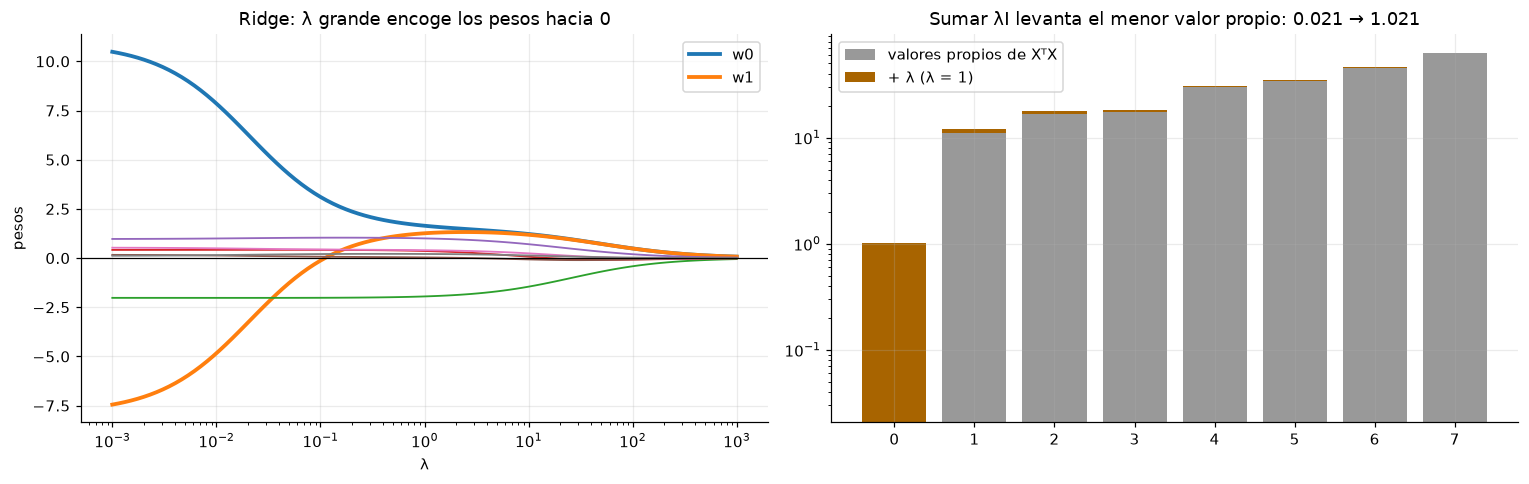

In [24]:
# Demostración 18: Mínimos cuadrados regularizados (Ridge)
N, P = 30, 8
X = rng.normal(size=(N, P)); X[:, 1] = X[:, 0] + 0.05 * rng.normal(size=N)   # columnas 0 y 1 casi iguales
w_real = np.array([3, 0, -2, 0, 1, 0, 0.5, 0])
y = X @ w_real + rng.normal(size=N)
lams = np.logspace(-3, 3, 100)
W = np.array([np.linalg.solve(X.T @ X + l * np.eye(P), X.T @ y) for l in lams])

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for j in range(P):
    ax[0].plot(lams, W[:, j], lw=2.5 if j < 2 else 1.2, label=f"w{j}" if j < 2 else None)
ax[0].set_xscale("log"); ax[0].axhline(0, c="k", lw=0.8); ax[0].legend()
ax[0].set_xlabel("λ"); ax[0].set_ylabel("pesos"); ax[0].set_title("Ridge: λ grande encoge los pesos hacia 0")
eig = np.linalg.eigvalsh(X.T @ X)
ax[1].bar(range(P), eig, color="0.6", label="valores propios de XᵀX")
ax[1].bar(range(P), np.ones(P), bottom=eig, color=C["reg"], label="+ λ (λ = 1)")
ax[1].set_yscale("log"); ax[1].legend()
ax[1].set_title(f"Sumar λI levanta el menor valor propio: {eig.min():.3f} → {eig.min() + 1:.3f}")
plt.tight_layout(); plt.show()

**Qué observar:** Las dos variables casi iguales ($w_0$ y $w_1$, líneas gruesas) tienen pesos inestables con $\lambda$ pequeño; al subir $\lambda$ se estabilizan y todos se encogen hacia 0. El menor valor propio sube, por eso la matriz se vuelve invertible.

**Prueba a cambiar:** Quita la línea que hace casi iguales las columnas 0 y 1 y compara las trayectorias.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Extremos.** ¿Qué pasa con los pesos si $\lambda\to0$? ¿Y si $\lambda\to\infty$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Vuelven a mínimos cuadrados, o tienden a 0.
2. **Por qué.** $\lambda$ pesa la penalización $\|w\|^2$ frente al error.
3. **Con los datos.** En el código, $\|w\|$ baja al aumentar $\lambda$.

</details>

**Justificación.** ¿Por qué sumar $\lambda I$ vuelve invertible la matriz?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque sube todos los valores propios en $\lambda$.
2. **Por qué.** Ninguno queda en 0.
3. **Con los datos.** Si el menor valor propio era casi 0, pasa a valer al menos $\lambda$.

</details>

**Efecto de un cambio.** Si en vez de $+\lambda$ pongo $-\lambda$, ¿afecta?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Sí, y mucho.
2. **Por qué.** Premia los pesos grandes y puede volver la matriz no invertible.
3. **Con los datos.** Es el error de signo que había en tus apuntes.

</details>

## 19. Caso 1: máxima verosimilitud con ruido gaussiano

**Resultado**

$$\varepsilon\sim\mathcal{N}(0,\sigma^2)\;\Longrightarrow\;\max_w\ln p(y\mid\mathbb{X},w)\iff\min_w\|y-\mathbb{X}w\|_2^2$$

**Idea:** Con ruido gaussiano, la probabilidad de cada dato cae con el cuadrado de su error. Maximizar la probabilidad de todos los datos es lo mismo que minimizar la suma de errores al cuadrado: mínimos cuadrados deja de ser una elección arbitraria.

**Qué muestra la gráfica:** La suma de errores cuadrados y la log-verosimilitud negativa como funciones de la pendiente, y el histograma de residuos.

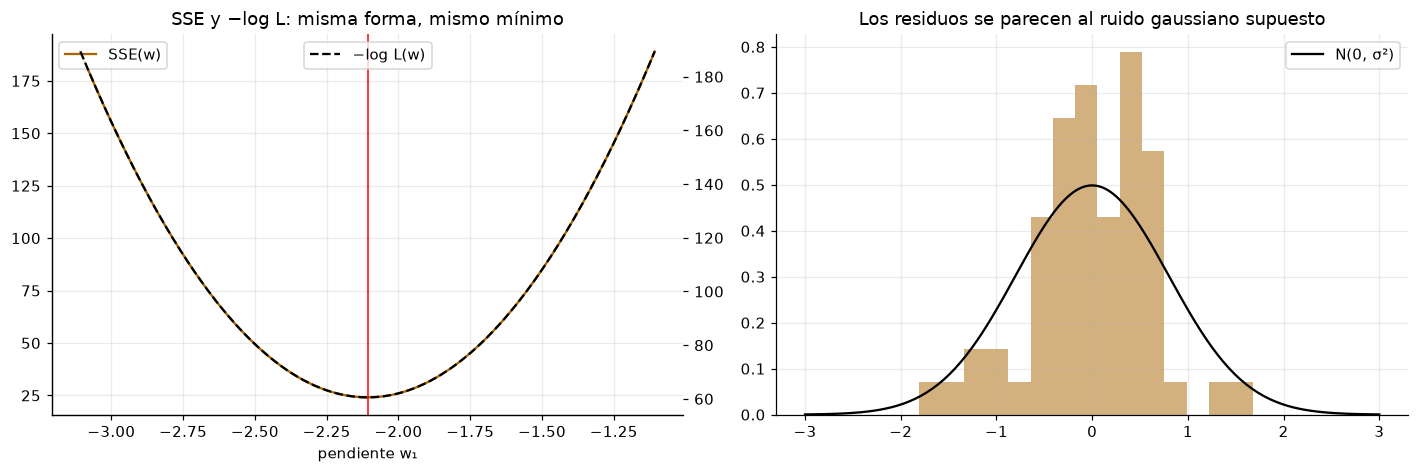

In [25]:
# Demostración 19: Caso 1: máxima verosimilitud con ruido gaussiano
N, sigma = 60, 0.8
x = rng.uniform(-3, 3, N); y = 1 - 2 * x + rng.normal(0, sigma, N)
X = np.c_[np.ones(N), x]
w_mc = np.linalg.lstsq(X, y, rcond=None)[0]
pend = np.linspace(w_mc[1] - 1, w_mc[1] + 1, 300)
SSE = np.array([np.sum((y - w_mc[0] - p * x)**2) for p in pend])
negL = N / 2 * np.log(2 * np.pi * sigma**2) + SSE / (2 * sigma**2)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].plot(pend, SSE, color=C["reg"], label="SSE(w)")
a2 = ax[0].twinx(); a2.plot(pend, negL, "k--", label="−log L(w)"); a2.grid(False)
ax[0].axvline(w_mc[1], c="r", lw=1); ax[0].set_xlabel("pendiente w₁")
ax[0].legend(loc="upper left"); a2.legend(loc="upper center")
ax[0].set_title("SSE y −log L: misma forma, mismo mínimo")
res = y - X @ w_mc; zz = np.linspace(-3, 3, 200)
ax[1].hist(res, bins=15, density=True, alpha=0.5, color=C["reg"])
ax[1].plot(zz, norm.pdf(zz, 0, sigma), "k", label="N(0, σ²)"); ax[1].legend()
ax[1].set_title("Los residuos se parecen al ruido gaussiano supuesto")
plt.tight_layout(); plt.show()

**Qué observar:** Las dos curvas tienen el mínimo en el mismo punto: $-\log L$ es la SSE escalada por $\frac{1}{2\sigma^2}$ más una constante. Los residuos tienen forma de gaussiana, el supuesto del Caso 1.

**Prueba a cambiar:** Cambia el ruido por uno de Laplace (`rng.laplace(0, sigma, N)`) y mira cómo cambia el histograma de residuos.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Justificación.** ¿Por qué maximizar la verosimilitud gaussiana es lo mismo que minimizar el error cuadrático?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque $-\log L$ es una constante más $\frac{SSE}{2\sigma^2}$.
2. **Por qué.** La constante no depende de $w$ y $\frac{1}{2\sigma^2}$ solo escala.
3. **Con los datos.** En la gráfica, las dos curvas tienen el mínimo en el mismo punto.

</details>

**Efecto de un cambio.** ¿Afecta $\sigma$ al $w$ óptimo?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** No.
2. **Por qué.** Solo cambia la altura de la curva, no dónde está el mínimo.
3. **Con los datos.** $\sigma$ sí importa para las probabilidades, no para la recta.

</details>

**Interpretación.** ¿Qué supuesto hay detrás de usar el error cuadrático medio?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Que el ruido es gaussiano e i.i.d.
2. **Por qué.** Ese supuesto convierte la verosimilitud en la suma de errores al cuadrado.
3. **Con los datos.** Los residuos deberían verse como una campana.

</details>

## 20. Caso 2: MAP con prior gaussiano sobre w

**Resultado**

$$w\sim\mathcal{N}(0,\sigma_w^2I)\;\Longrightarrow\;\max_w\ln p(w\mid y)\iff\min_w\|y-\mathbb{X}w\|_2^2+\frac{\sigma^2}{\sigma_w^2}\|w\|_2^2$$

**Idea:** El prior dice: antes de ver datos, creo que los pesos son pequeños. Con Bayes, esa creencia se suma a la verosimilitud como un término extra, y ese término es exactamente la penalización de Ridge.

**Qué muestra la gráfica:** Las curvas de nivel de la verosimilitud, del prior y de la posterior en el plano de los pesos.

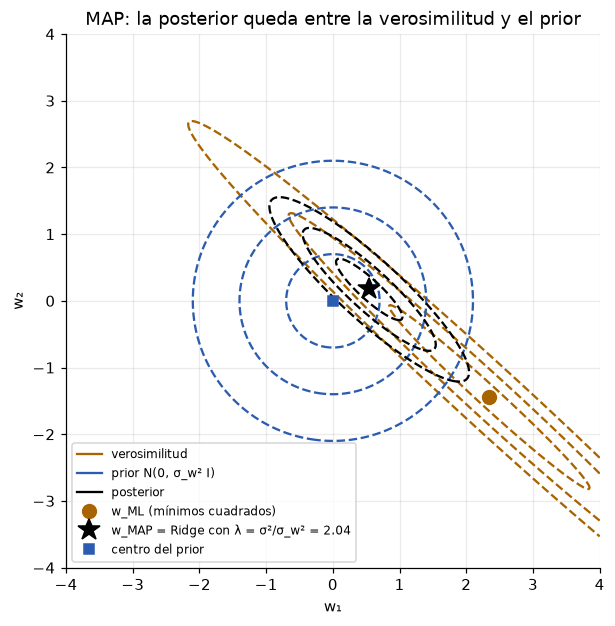

In [26]:
# Demostración 20: Caso 2: MAP con prior gaussiano sobre w
N, sigma, sw = 10, 1.0, 0.7
X = rng.normal(size=(N, 2)); X[:, 1] = X[:, 0] + 0.3 * rng.normal(size=N)
y = X @ np.array([1.5, -0.5]) + rng.normal(0, sigma, N)
lam = sigma**2 / sw**2
w_ml = np.linalg.solve(X.T @ X, X.T @ y)
w_map = np.linalg.solve(X.T @ X + lam * np.eye(2), X.T @ y)

lim = max(4, np.abs(w_ml).max() + 1)
g = np.linspace(-lim, lim, 300); W0, W1 = np.meshgrid(g, g)
Wf = np.c_[W0.ravel(), W1.ravel()]
logLik = -((y - Wf @ X.T)**2).sum(1) / (2 * sigma**2)
logPrior = -(Wf**2).sum(1) / (2 * sw**2)

fig, ax = plt.subplots(figsize=(6.8, 6.3))
for Z, c, nombre in [(logLik, C["reg"], "verosimilitud"), (logPrior, C["geo"], "prior N(0, σ_w² I)"), (logLik + logPrior, "k", "posterior")]:
    ax.contour(W0, W1, Z.reshape(W0.shape), levels=np.sort(Z.max() - np.array([0.5, 2, 4.5])), colors=c)
    ax.plot([], [], color=c, label=nombre)
ax.plot(*w_ml, "o", color=C["reg"], ms=9, label="w_ML (mínimos cuadrados)")
ax.plot(*w_map, "k*", ms=15, label=f"w_MAP = Ridge con λ = σ²/σ_w² = {lam:.2f}")
ax.plot(0, 0, "s", color=C["geo"], label="centro del prior")
ax.set_xlabel("w₁"); ax.set_ylabel("w₂"); ax.set_aspect("equal"); ax.legend(fontsize=8, loc="lower left")
ax.set_title("MAP: la posterior queda entre la verosimilitud y el prior")
plt.show()

**Qué observar:** La estrella (MAP, igual a Ridge) queda entre el punto de mínimos cuadrados y el centro del prior: el prior la jala hacia 0.

**Prueba a cambiar:** Reduce `sw` (prior más estrecho) y mira cómo el MAP se acerca a 0; auméntalo y mira cómo se acerca a $w_{ML}$.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Interpretación.** ¿Qué significa poner el prior $w\sim\mathcal{N}(0,\sigma_w^2I)$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Creer, antes de ver datos, que los pesos son pequeños.
2. **Por qué.** El prior está centrado en 0.
3. **Con los datos.** Ese prior es exactamente la penalización de Ridge.

</details>

**Extremos.** ¿Qué pasa si $\sigma_w\to0$? ¿Y si $\sigma_w\to\infty$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Los pesos se van a 0, o se vuelve a mínimos cuadrados.
2. **Por qué.** $\lambda=\frac{\sigma^2}{\sigma_w^2}$ tiende a infinito o a 0.
3. **Con los datos.** Prior muy seguro frente a prior sin opinión.

</details>

**Leer la matriz o gráfica.** En las curvas de nivel, ¿dónde queda el MAP?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Entre el punto de mínimos cuadrados y el centro del prior.
2. **Por qué.** La posterior combina las dos curvas.
3. **Con los datos.** Con un prior estrecho el MAP queda cerca de 0; con uno ancho, cerca de mínimos cuadrados.

</details>

# Kernels

## 21. Matriz de Gram vía SVD y truco del kernel

**Resultado**

$$\Phi=USV^T\;\Longrightarrow\;\Phi^T\Phi=VS^TSV^T\ (Q\times Q),$$

$$\Phi\Phi^T=USS^TU^T\ (N\times N)$$

**Idea:** $\Phi^T\Phi$ y $\Phi\Phi^T$ se construyen con las mismas piezas $S$; solo cambian las bases. Por eso comparten la información útil, los valores $s_i^2$. Si $Q$ es enorme conviene la versión $N\times N$, que solo necesita productos internos: ese es el truco del kernel.

**Qué muestra la gráfica:** Los valores propios de $\Phi\Phi^T$ ($N\times N$) y de $\Phi^T\Phi$ ($Q\times Q$), y la matriz de Gram calculada con y sin $\varphi$.

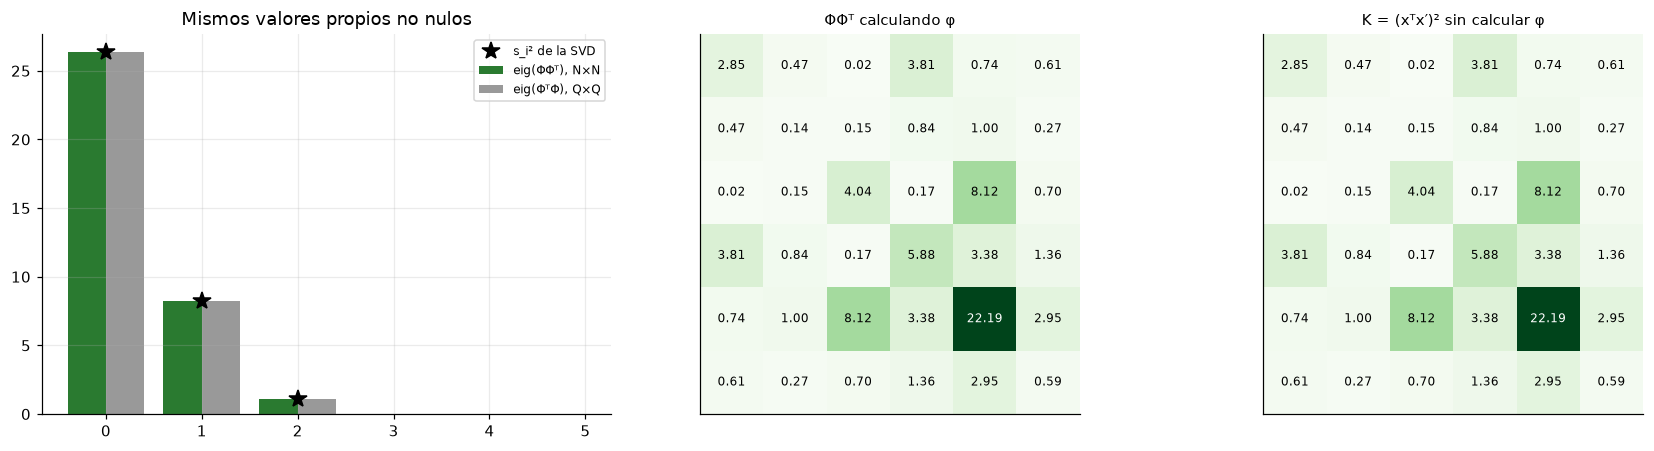

In [27]:
# Demostración 21: Matriz de Gram vía SVD y truco del kernel
Xs = rng.normal(size=(6, 2))
F = np.c_[Xs[:, 0]**2, np.sqrt(2) * Xs[:, 0] * Xs[:, 1], Xs[:, 1]**2]     # Φ(X): N×Q = 6×3
ev_N = np.sort(np.linalg.eigvalsh(F @ F.T))[::-1]                           # N×N
ev_Q = np.sort(np.linalg.eigvalsh(F.T @ F))[::-1]                           # Q×Q
s = np.linalg.svd(F, compute_uv=False)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].bar(np.arange(6) - 0.2, ev_N, 0.4, color=C["kern"], label="eig(ΦΦᵀ), N×N")
ax[0].bar(np.arange(3) + 0.2, ev_Q, 0.4, color="0.6", label="eig(ΦᵀΦ), Q×Q")
ax[0].plot(range(3), s**2, "k*", ms=12, label="s_i² de la SVD")
ax[0].legend(fontsize=8); ax[0].set_title("Mismos valores propios no nulos")
mapa_calor(ax[1], F @ F.T, "ΦΦᵀ calculando φ", cmap="Greens", centrado=False)
mapa_calor(ax[2], (Xs @ Xs.T)**2, "K = (xᵀx′)² sin calcular φ", cmap="Greens", centrado=False)
plt.tight_layout(); plt.show()

**Qué observar:** Los valores no nulos coinciden con $s_i^2$; los otros $N-Q$ valores de la matriz grande son cero. Las dos matrices de Gram son idénticas: eso es el truco del kernel.

**Prueba a cambiar:** Cambia el número de datos en `rng.normal(size=(6, 2))` y mira cuántos valores propios quedan en cero.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Dimensiones.** ¿De qué tamaño son $\Phi^T\Phi$ y $\Phi\Phi^T$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $Q\times Q$ y $N\times N$.
2. **Por qué.** $\Phi(\mathbb{X})$ es $N\times Q$.
3. **Con los datos.** Con $Q\to\infty$ solo se puede calcular la $N\times N$: la matriz kernel.

</details>

**Justificación.** ¿Por qué las dos tienen los mismos valores propios no nulos?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque las dos se arman con los mismos valores singulares.
2. **Por qué.** $S^TS$ y $SS^T$ comparten los $s_i^2$.
3. **Con los datos.** En la gráfica, las barras de las dos matrices coinciden con las estrellas $s_i^2$ de la SVD.

</details>

**Espacio.** ¿La matriz kernel vive en el espacio original o en el RKHS?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Sus entradas son productos internos en el RKHS.
2. **Por qué.** Pero la matriz relaciona muestras: es $N\times N$, sin columnas-píxel.
3. **Con los datos.** Se calcula con los datos originales.

</details>

## 22. Hilbert en el espacio de características

**Resultado**

$$d^2\big(\phi(x),\phi(x')\big)=K(x,x)-2K(x,x')+K(x',x')$$

$$\cos\theta=\frac{K(x,x')}{\sqrt{K(x,x)\,K(x',x')}}$$

**Idea:** Toda la geometría (norma, distancia, ángulo) se construye con productos internos, como vimos en la demostración 5. Si el kernel da los productos internos del espacio de $\phi$, da toda su geometría sin conocer $\phi$.

**Qué muestra la gráfica:** Dos círculos que no se pueden separar con una recta, su imagen en el espacio de características y las distancias calculadas solo con el kernel.

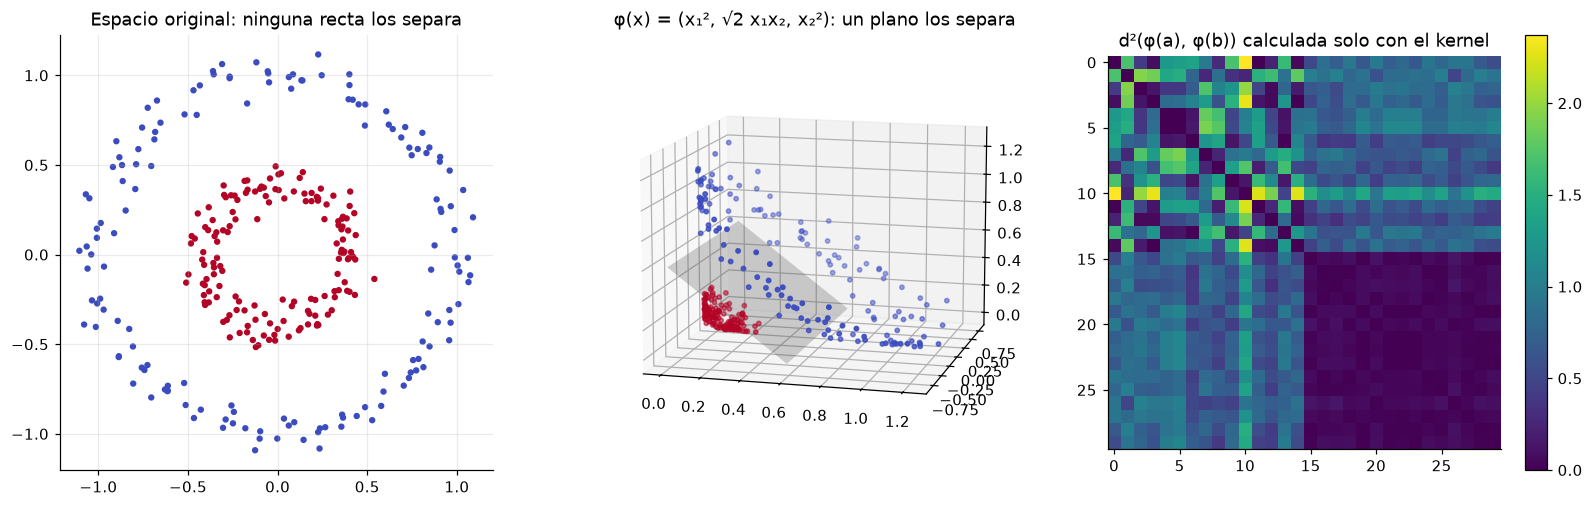

¿Coincide con φ explícita? True


In [28]:
# Demostración 22: Hilbert en el espacio de características
Xc_, yc_ = make_circles(300, factor=0.4, noise=0.06, random_state=0)
Fc_ = np.c_[Xc_[:, 0]**2, np.sqrt(2) * Xc_[:, 0] * Xc_[:, 1], Xc_[:, 1]**2]
orden = np.argsort(yc_)[::10]                      # submuestra ordenada por clase
k = lambda a, b: (a @ b)**2
D2k = np.array([[k(a, a) - 2 * k(a, b) + k(b, b) for b in Xc_[orden]] for a in Xc_[orden]])

fig = plt.figure(figsize=(15, 4.6))
ax1 = fig.add_subplot(1, 3, 1); ax1.scatter(*Xc_.T, c=yc_, cmap="coolwarm", s=10); ax1.set_aspect("equal")
ax1.set_title("Espacio original: ninguna recta los separa")
ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax2.scatter(Fc_[:, 0], Fc_[:, 1], Fc_[:, 2], c=yc_, cmap="coolwarm", s=8)
u1, u2 = np.meshgrid(np.linspace(0, 0.6, 2), np.linspace(-0.8, 0.8, 2))
ax2.plot_surface(u1, u2, 0.6 - u1, alpha=0.25, color="0.5")     # plano x₁² + x₂² = 0.6
ax2.view_init(elev=12, azim=-75)
ax2.set_title("φ(x) = (x₁², √2 x₁x₂, x₂²): un plano los separa")
ax3 = fig.add_subplot(1, 3, 3); im = ax3.imshow(D2k, cmap="viridis"); fig.colorbar(im, ax=ax3); ax3.grid(False)
ax3.set_title("d²(φ(a), φ(b)) calculada solo con el kernel")
plt.tight_layout(); plt.show()
Fo = Fc_[orden]
print("¿Coincide con φ explícita?", np.allclose(D2k, ((Fo[:, None, :] - Fo[None, :, :])**2).sum(-1)))

**Qué observar:** Con $\varphi$ los círculos quedan a distinta altura y un plano los separa. El mapa de distancias tiene bloques por clase, y coincide con el que se obtiene construyendo $\varphi$.

**Prueba a cambiar:** Cambia `factor` en `make_circles` (qué tan separados están los círculos).

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Espacio.** La distancia $d^2(\varphi(a),\varphi(b))$, ¿está en el espacio original o en el RKHS?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** En el RKHS.
2. **Por qué.** Compara $\varphi(a)$ con $\varphi(b)$, aunque se calcula con kernels de los datos originales.
3. **Con los datos.** Por eso los círculos que no se separan con una recta sí se separan allí con un plano.

</details>

**Justificación.** ¿Por qué no hace falta conocer $\varphi$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque distancias y ángulos solo usan productos internos.
2. **Por qué.** Y el kernel da los productos internos.
3. **Con los datos.** $K(a,a)-2K(a,b)+K(b,b)$.

</details>

**Interpretación.** ¿Qué significa un coseno cercano a 1 en el RKHS?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Que, para el kernel, las dos muestras se parecen mucho.
2. **Por qué.** $\varphi(a)$ y $\varphi(b)$ apuntan en la misma dirección.
3. **Con los datos.** Lo mismo que en la demostración 6, pero en el espacio de características.

</details>

## 23. Kernel RBF y ancho de banda

**Resultado**

$$K(x_i,x_j)=\exp\Big\{-\frac{\|x_i-x_j\|_2^2}{2\sigma^2}\Big\}$$

$$\sigma\to0\Rightarrow K\to I$$

$$\sigma\to\infty\Rightarrow K\to\mathbf{1}\mathbf{1}^T$$

**Idea:** Es una similitud que decae con la distancia. El ancho de banda $\sigma$ dicta hasta dónde pasa la información: muy pequeño y cada punto solo se ve a sí mismo; muy grande y todos parecen iguales. Se busca que el kernel viva entre esos dos extremos.

**Qué muestra la gráfica:** La forma del kernel según la distancia y la matriz $\mathbb{K}$ de dos lunas ordenadas por clase.

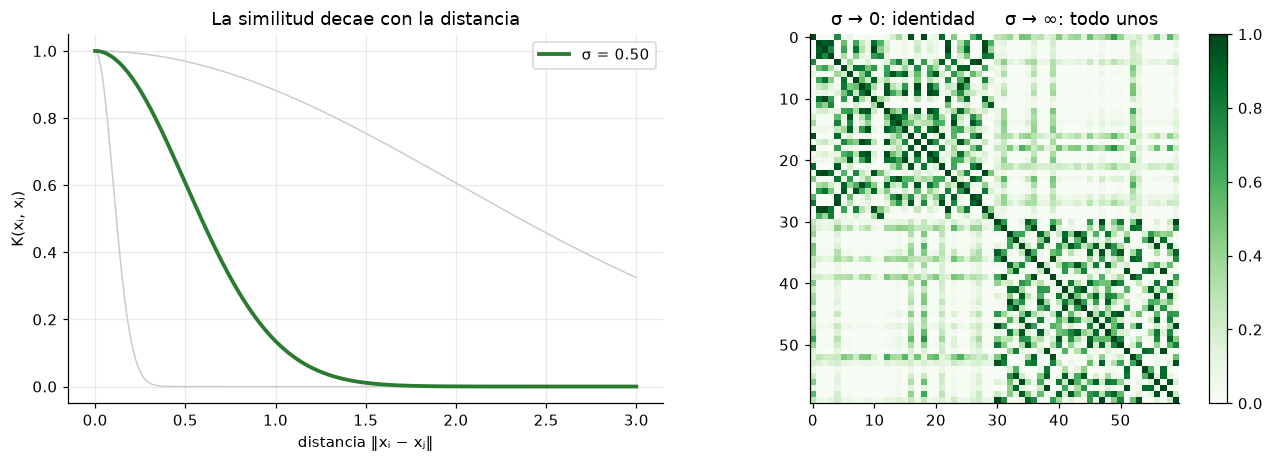

In [29]:
# Demostración 23: Kernel RBF y ancho de banda
Xm, ym = make_moons(60, noise=0.08, random_state=1)
Xm = Xm[np.argsort(ym)]                                # ordenar por clase para ver bloques
D = ((Xm[:, None, :] - Xm[None, :, :])**2).sum(-1)

def rbf(sigma=0.5):
    K = np.exp(-D / (2 * sigma**2))
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
    d = np.linspace(0, 3, 300)
    for s_ in [0.1, 0.5, 2.0]:
        ax[0].plot(d, np.exp(-d**2 / (2 * s_**2)), color="0.8", lw=1)
    ax[0].plot(d, np.exp(-d**2 / (2 * sigma**2)), color=C["kern"], lw=2.5, label=f"σ = {sigma:.2f}")
    ax[0].set_xlabel("distancia ‖xᵢ − xⱼ‖"); ax[0].set_ylabel("K(xᵢ, xⱼ)"); ax[0].legend()
    ax[0].set_title("La similitud decae con la distancia")
    im = ax[1].imshow(K, vmin=0, vmax=1, cmap="Greens"); fig.colorbar(im, ax=ax[1]); ax[1].grid(False)
    ax[1].set_title("σ → 0: identidad     σ → ∞: todo unos")
    plt.tight_layout(); plt.show()

interactivo(rbf, sigma=(0.02, 5.0, 0.02, 0.5))

**Qué observar:** Con $\sigma$ pequeño $\mathbb{K}$ es casi la identidad (cada punto solo se parece a sí mismo); con $\sigma$ grande es casi todo unos. En medio aparecen los dos bloques, uno por clase.

**Prueba a cambiar:** Mueve el deslizador `sigma` de un extremo al otro.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Extremos.** ¿Qué pasa con la matriz kernel si $\sigma$ es muy grande? ¿Y si es muy pequeño?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Todo se parece con todo; o nada se parece con nada.
2. **Por qué.** Con $\sigma$ grande, $\mathbb{K}\to\mathbf{1}\mathbf{1}^T$; con $\sigma$ pequeño, $\mathbb{K}\to I$.
3. **Con los datos.** En los dos casos la matriz no sirve para comparar: se busca un $\sigma$ intermedio.

</details>

**Justificación.** ¿Por qué la diagonal del kernel da 1?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque cada imagen se compara consigo misma.
2. **Por qué.** La distancia es 0 y $e^0=1$: "yo me parezco a mí mismo al máximo".
3. **Con los datos.** Pasa igual con cualquier $\sigma$.

</details>

**Leer la matriz o gráfica.** ¿Qué significa un valor de 0.9 entre dos imágenes?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Que, para ese $\sigma$, se parecen mucho.
2. **Por qué.** Están muy cerca en el espacio original.
3. **Con los datos.** Con las imágenes ordenadas por clase, esos valores forman bloques claros.

</details>

## 24. Covarianza en el espacio de características (pizarrón)

*En tus apuntes: págs. 26, 29 y 31 (fotos del pizarrón).*

**Resultado**

$$\operatorname{Cov}(\Phi(\mathbb{X}),\Phi(\mathbb{X}))=\mathbb{E}\{(\Phi(\mathbb{X})-\mathbf{1}_N\mu_{\mathcal H})(\Phi(\mathbb{X})-\mathbf{1}_N\mu_{\mathcal H})^T\}$$

$$=\frac1N\sum_{n=1}^{N}K(x_n,x_n)-\frac{1}{N^2}\sum_{n=1}^{N}\sum_{n'=1}^{N}K(x_n,x_{n'})$$

**Idea:** Como $Q\to\infty$, $\varphi$ no se puede guardar en memoria. Pero cada producto $\varphi(x_n)\varphi^T(x_m)$ es un valor del kernel. Al expandir el producto como en la demostración 26, cada término se convierte en una suma de kernels. Con vectores fila, $\varphi(x_n)\varphi^T(x_n)$ es un número, así que el resultado es la covarianza total: la traza de la covarianza.

**Qué muestra la gráfica:** Los términos del pizarrón sumados uno a uno (en verde los que suman, en rojo los que restan) y la nube de puntos $\varphi(x_n)$ con su media $\mu_{\mathcal H}$.

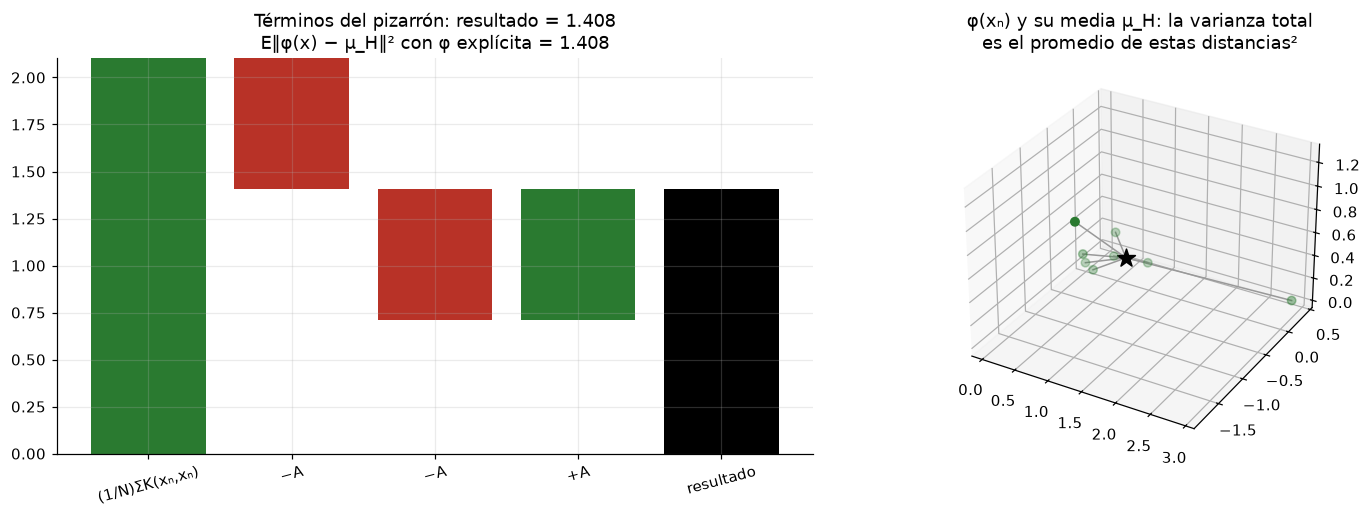

In [30]:
# Demostración 24: Covarianza en el espacio de características (pizarrón)
Xs = rng.normal(size=(8, 2)); N = len(Xs)
K = (Xs @ Xs.T)**2                                  # K(a,b) = φ(a)φᵀ(b)
t1, A = np.trace(K) / N, K.sum() / N**2
F = np.c_[Xs[:, 0]**2, np.sqrt(2) * Xs[:, 0] * Xs[:, 1], Xs[:, 1]**2]
m = F.mean(0)

fig = plt.figure(figsize=(14, 4.8))
ax = fig.add_subplot(1, 2, 1)
pasos = [("(1/N)ΣK(xₙ,xₙ)", t1), ("−A", -A), ("−A", -A), ("+A", A)]
acum = 0.0
for k, (t, v) in enumerate(pasos):
    ax.bar(k, v, bottom=acum, color=C["kern"] if v > 0 else C["prob"]); acum += v
ax.bar(len(pasos), acum, color="k")
ax.set_xticks(range(5), [p[0] for p in pasos] + ["resultado"], rotation=15)
ax.set_title(f"Términos del pizarrón: resultado = {acum:.3f}\nE‖φ(x) − μ_H‖² con φ explícita = {np.mean(((F - m)**2).sum(1)):.3f}")
ax3 = fig.add_subplot(1, 2, 2, projection="3d")
ax3.scatter(*F.T, color=C["kern"], s=30); ax3.scatter(*m, color="k", s=150, marker="*")
for f in F:
    ax3.plot(*np.c_[f, m], color="0.6", lw=1)
ax3.set_title("φ(xₙ) y su media μ_H: la varianza total\nes el promedio de estas distancias²")
plt.tight_layout(); plt.show()

**Qué observar:** $-A-A+A$ deja un solo $-A$, y el resultado coincide con el promedio de las distancias al cuadrado de cada $\varphi(x_n)$ a la media.

**Prueba a cambiar:** Aumenta el número de datos en `rng.normal(size=(8, 2))`.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Dimensiones.** El resultado del pizarrón, ¿es una matriz o un número?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Un número.
2. **Por qué.** Es la traza de la covarianza: la covarianza total.
3. **Con los datos.** La matriz completa sería $Q\times Q$, o $N\times N$ si se centra el kernel (demostración 29).

</details>

**Justificación.** ¿Por qué en el pizarrón se tacha un término?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque tres términos valen lo mismo, $A$.
2. **Por qué.** $-A-A+A=-A$.
3. **Con los datos.** Queda $\frac1N\sum_nK(x_n,x_n)-A$.

</details>

**Espacio.** ¿Esta varianza está en la misma escala que la del espacio original?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** No: está en el RKHS.
2. **Por qué.** Su escala depende del kernel y de $\sigma$.
3. **Con los datos.** Con el RBF, $\frac1N\operatorname{Tr}(\mathbb{K})=1$ siempre.

</details>

## 28. Distancias al cuadrado vectorizadas y matriz kernel RBF

*En tus apuntes: págs. 26 y 27 (23 de septiembre) y tu código.*

**Resultado**

$$\mathbf{D}=\mathbf{z}\mathbf{1}_N^T-2\,\mathbb{X}\mathbb{X}^T+\mathbf{1}_N\mathbf{z}^T,\quad\mathbf{z}=\operatorname{diag}(\mathbb{X}\mathbb{X}^T)\in\mathbb{R}^{N\times1}$$

$$\mathbb{K}=\exp\Big\{-\frac{\mathbf{D}}{2\sigma^2}\Big\}$$

**Idea:** Calcular $\|x_i-x_j\|^2$ con dos bucles es lento. La expansión de Hilbert (demostración 5) parte la distancia en tres piezas, y las tres ya están dentro de $\mathbb{X}\mathbb{X}^T$: las normas en su diagonal y los productos internos fuera de ella. Solo falta acomodarlas como matrices $N\times N$.

**Qué muestra la gráfica:** Las tres piezas de la fórmula, su suma $\mathbf{D}$, el kernel $\mathbb{K}$ y el tiempo del doble bucle frente a la versión vectorizada.

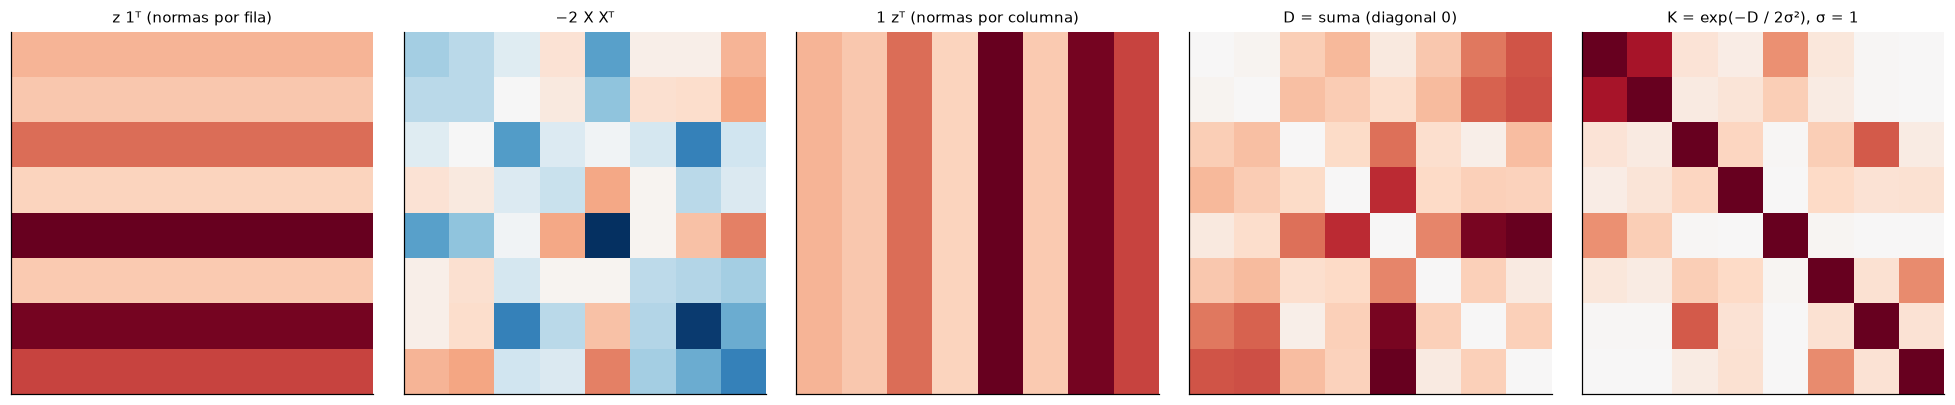

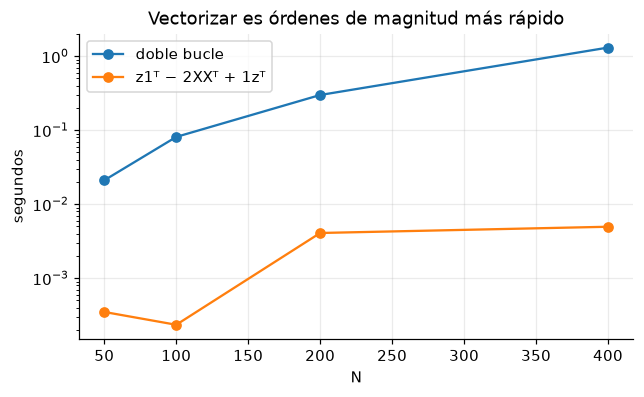

In [31]:
# Demostración 28: Distancias al cuadrado vectorizadas y matriz kernel RBF
Xr = rng.normal(size=(8, 3))
G = Xr @ Xr.T; z = np.diag(G)[:, None]; uno = np.ones((8, 1))
partes = [z @ uno.T, -2 * G, uno @ z.T]
Dm = sum(partes)
fig, ax = plt.subplots(1, 5, figsize=(18, 3.6))
titulos = ["z 1ᵀ (normas por fila)", "−2 X Xᵀ", "1 zᵀ (normas por columna)", "D = suma (diagonal 0)", "K = exp(−D / 2σ²), σ = 1"]
for a_, M, t in zip(ax, partes + [Dm, np.exp(-Dm / 2)], titulos):
    mapa_calor(a_, M, t, anotar=False)
plt.tight_layout(); plt.show()

Ns, t_bucle, t_vec = [50, 100, 200, 400], [], []
for n in Ns:
    Z = rng.normal(size=(n, 20))
    t0 = time.perf_counter(); _ = np.array([[np.sum((a - b)**2) for b in Z] for a in Z]); t_bucle.append(time.perf_counter() - t0)
    t0 = time.perf_counter(); g = Z @ Z.T; zz = np.diag(g)[:, None]; _ = zz - 2 * g + zz.T; t_vec.append(time.perf_counter() - t0)
plt.figure(figsize=(6.5, 3.6))
plt.plot(Ns, t_bucle, "o-", label="doble bucle"); plt.plot(Ns, t_vec, "o-", label="z1ᵀ − 2XXᵀ + 1zᵀ")
plt.yscale("log"); plt.xlabel("N"); plt.ylabel("segundos"); plt.legend()
plt.title("Vectorizar es órdenes de magnitud más rápido"); plt.show()

**Qué observar:** $\mathbf{z}\mathbf{1}^T$ es constante en cada fila y $\mathbf{1}\mathbf{z}^T$ en cada columna; la suma tiene diagonal 0. La versión vectorizada es mucho más rápida y la diferencia crece con $N$.

**Prueba a cambiar:** Aumenta la dimensión de los datos en `rng.normal(size=(n, 20))`.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Justificación.** ¿Por qué $\operatorname{Diag}(\mathbb{X}\mathbb{X}^T)-2\mathbb{X}\mathbb{X}^T+\operatorname{Diag}(\mathbb{X}\mathbb{X}^T)$ está mal?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque una matriz diagonal solo tiene las normas en la diagonal.
2. **Por qué.** Fuera de ella faltan $\|x_i\|^2$ y $\|x_j\|^2$.
3. **Con los datos.** Fuera de la diagonal da $-2\langle x_i,x_j\rangle$, no la distancia.

</details>

**Dimensiones.** ¿De qué tamaño son $\mathbf{z}$, $\mathbf{z}\mathbf{1}^T$ y $\mathbf{D}$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $N\times1$, $N\times N$ y $N\times N$.
2. **Por qué.** $\mathbf{z}$ tiene una norma por imagen; el producto exterior la copia en todas las columnas.
3. **Con los datos.** Con 100 imágenes, $\mathbf{D}$ es $100\times100$.

</details>

**Efecto de un cambio.** ¿Afecta aplicar `np.maximum(D, 0)`?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Casi no.
2. **Por qué.** Solo quita negativos diminutos que aparecen por redondeo.
3. **Con los datos.** Sin eso, el kernel podría dar valores apenas mayores que 1.

</details>

## 29. Centrado del kernel: HKH

*En tus apuntes: pág. 33.*

**Resultado**

$$\operatorname{Cov}(\Phi(\mathbb{X}))=\mathbb{K}-\mathbb{K}J-J\mathbb{K}+J\mathbb{K}J$$

$$=(I-J)\,\mathbb{K}\,(I-J)=H\mathbb{K}H,$$

$$J=\frac1N\mathbf{1}_N\mathbf{1}_N^T$$

*Precisión:* $H\mathbb{K}H=\Phi_c\Phi_c^T$ es la matriz de Gram centrada ($N\times N$), no la covarianza $\frac1N\Phi_c^T\Phi_c$ ($Q\times Q$). Por la SVD (demostración 21) comparten los valores propios no nulos, salvo el factor $\frac1N$; por eso se le llama covarianza en el espacio del kernel.

**Idea:** Centrar $\Phi(\mathbb{X})$ es multiplicarlo por la matriz de centrado $H=I-J$, como en la demostración 11 pero por el otro lado. Como $\mathbb{K}=\Phi\Phi^T$, centrar las características equivale a encerrar el kernel entre dos $H$, sin necesidad de conocer $\Phi$.

**Qué muestra la gráfica:** $\mathbb{K}$ y $H\mathbb{K}H$, la media de cada fila antes y después de centrar, y la proyección de kernel PCA.

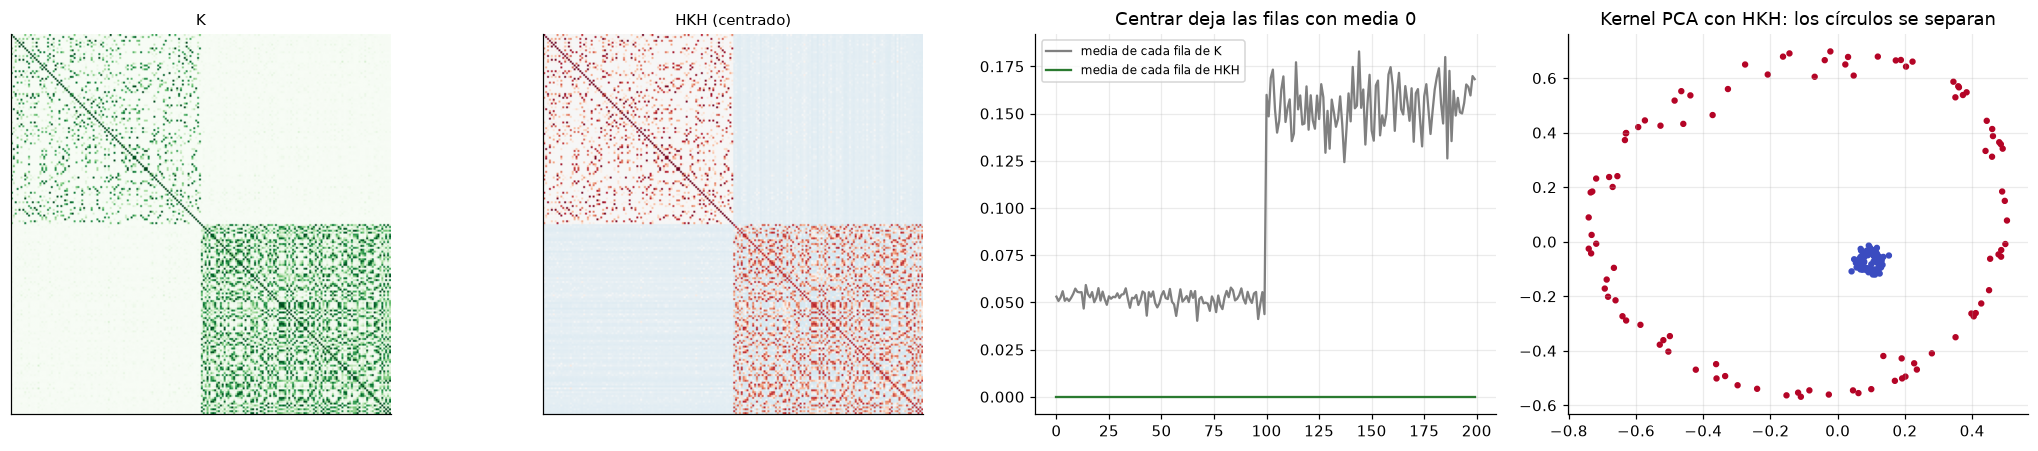

In [32]:
# Demostración 29: Centrado del kernel: HKH
Xc_, yc_ = make_circles(200, factor=0.35, noise=0.05, random_state=2)
o = np.argsort(yc_); Xc_, yc_ = Xc_[o], yc_[o]
N = len(Xc_)
Dc = ((Xc_[:, None] - Xc_[None])**2).sum(-1)
K = np.exp(-Dc / (2 * 0.25**2))
H = np.eye(N) - np.ones((N, N)) / N
Kc = H @ K @ H
val, vec = np.linalg.eigh(Kc); val, vec = val[::-1], vec[:, ::-1]
proj = vec[:, :2] * np.sqrt(np.maximum(val[:2], 0))        # kernel PCA

fig, ax = plt.subplots(1, 4, figsize=(19, 4.2))
mapa_calor(ax[0], K, "K", cmap="Greens", centrado=False, anotar=False)
mapa_calor(ax[1], Kc, "HKH (centrado)", anotar=False)
ax[2].plot(K.mean(1), color="0.5", label="media de cada fila de K")
ax[2].plot(Kc.mean(1), color=C["kern"], label="media de cada fila de HKH")
ax[2].legend(fontsize=8); ax[2].set_title("Centrar deja las filas con media 0")
ax[3].scatter(proj[:, 0], proj[:, 1], c=yc_, cmap="coolwarm", s=10)
ax[3].set_title("Kernel PCA con HKH: los círculos se separan")
plt.tight_layout(); plt.show()

**Qué observar:** Las filas de $H\mathbb{K}H$ tienen media 0. Con el kernel centrado, las dos primeras componentes de kernel PCA separan los dos círculos.

**Prueba a cambiar:** Usa `K` en lugar de `Kc` en `np.linalg.eigh` y compara la proyección.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Justificación.** ¿Por qué el último término es $+J\mathbb{K}J$ y no $+\frac1N J\mathbb{K}J$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque $J$ ya incluye el $\frac1N$.
2. **Por qué.** $\frac{1}{N^2}\mathbf{1}\mathbf{1}^T\mathbb{K}\mathbf{1}\mathbf{1}^T=J\mathbb{K}J$.
3. **Con los datos.** Con el $\frac1N$ de más, el resultado ya no coincide con $H\mathbb{K}H$.

</details>

**Efecto de un cambio.** ¿Nos cambia algo centrar el kernel?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Sí.
2. **Por qué.** Las filas quedan con media 0 y aparecen valores negativos.
3. **Con los datos.** Kernel PCA se calcula siempre con el kernel centrado.

</details>

**Interpretación.** ¿Qué significa un valor negativo en $H\mathbb{K}H$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Que dos muestras se alejan de la media en direcciones opuestas.
2. **Por qué.** Es una covarianza en el RKHS, no una similitud.
3. **Con los datos.** Por eso la correlación del RKHS va de −1 a 1.

</details>

## 30. MMD: Maximum Mean Discrepancy (solución de la última página)

*En tus apuntes: pág. 34 (resuelta aquí).*

**Resultado**

$$\operatorname{MMD}^2=\|\mu_x-\mu_y\|_{\mathcal H}^2$$

$$=\frac{1}{N^2}\sum_{n,n'}K(x_n,x_{n'})-\frac{2}{NM}\sum_{n,m}K(x_n,y_m)$$

$$+\frac{1}{M^2}\sum_{m,m'}K(y_m,y_{m'})$$

**Idea:** Para saber si dos conjuntos de datos vienen de la misma distribución se comparan sus medias. No en el espacio original, donde dos distribuciones distintas pueden tener la misma media, sino en el espacio de características: allí, con un kernel como el RBF, la media $\mu_x$ resume toda la distribución. Como el MMD es una distancia al cuadrado, se expande igual que en la demostración 5, y cada producto interno se reemplaza por sus sumatorias de kernels (la recomendación de la página).

**Qué muestra la gráfica:** Las dos muestras, la matriz kernel conjunta con sus bloques, una prueba de permutaciones y el MMD² frente a cambios de media y de escala.

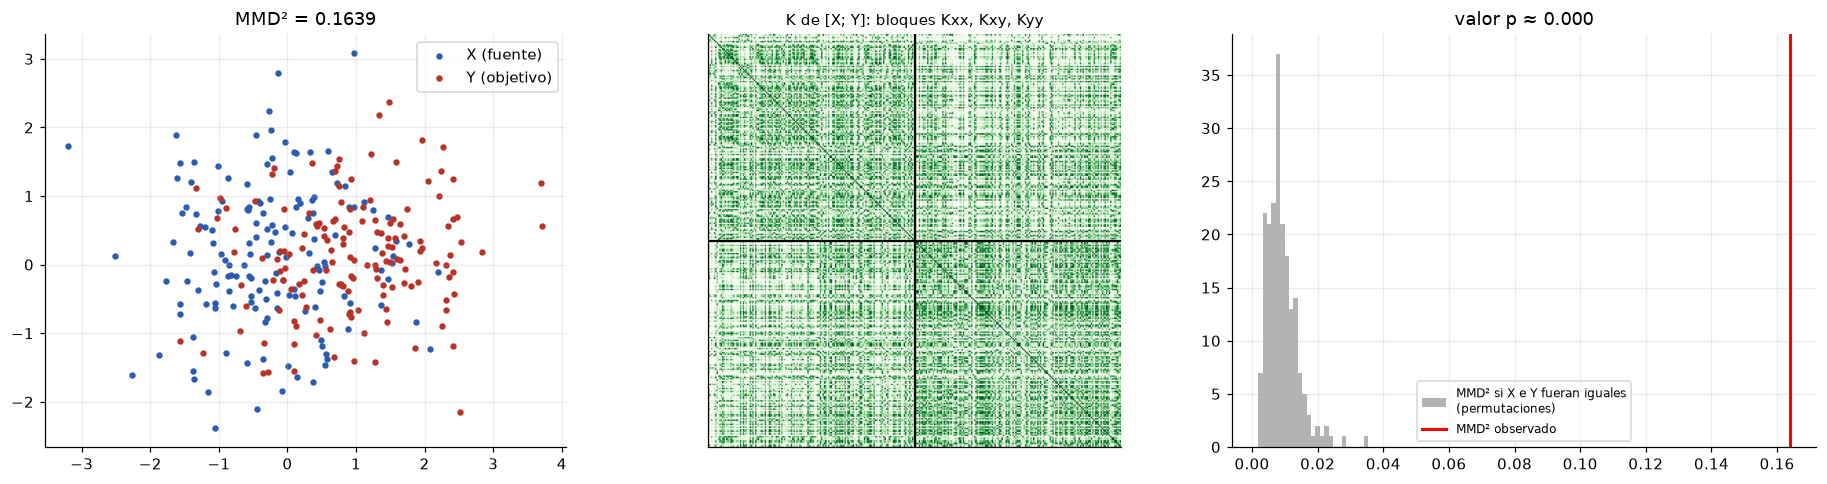

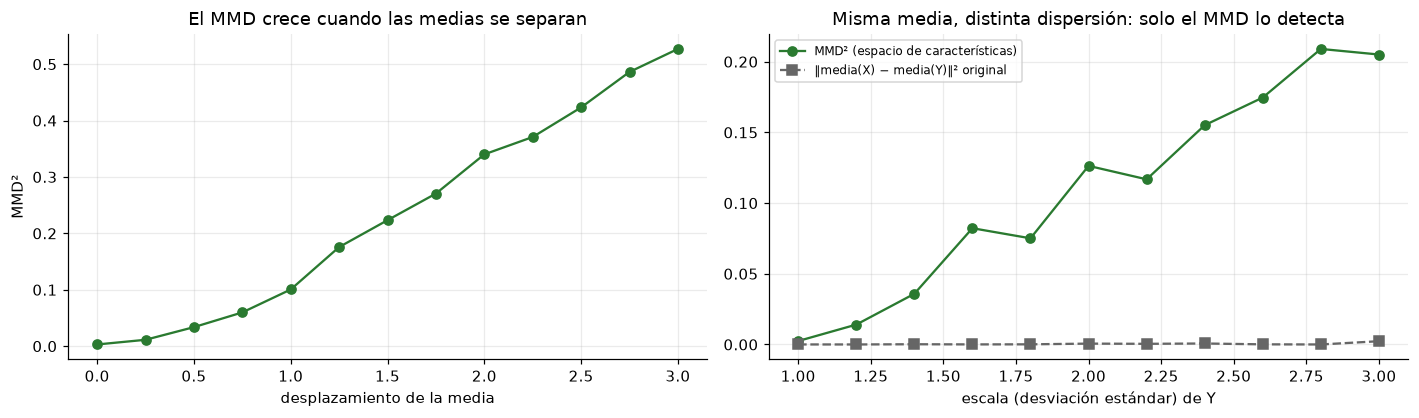

In [33]:
# Demostración 30: MMD: Maximum Mean Discrepancy (solución de la última página)
def kernel_xy(A, B, s2=1.0):
    Dab = (A**2).sum(1)[:, None] - 2 * A @ B.T + (B**2).sum(1)[None, :]    # demostración 28
    return np.exp(-np.maximum(Dab, 0) / (2 * s2))

def mmd2(A, B, s2=1.0):        # (1/N²)ΣΣK(x,x') − (2/NM)ΣΣK(x,y) + (1/M²)ΣΣK(y,y')
    return kernel_xy(A, A, s2).mean() - 2 * kernel_xy(A, B, s2).mean() + kernel_xy(B, B, s2).mean()

def mmd_visual(desplazamiento=1.0, escala=1.0):
    Xa = rng.normal(0, 1, (150, 2)); Yb = rng.normal(0, escala, (150, 2)) + [desplazamiento, 0]
    Z = np.vstack([Xa, Yb]); obs = mmd2(Xa, Yb)
    nulos = [mmd2(Z[p[:150]], Z[p[150:]]) for p in (rng.permutation(300) for _ in range(200))]
    fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
    ax[0].scatter(*Xa.T, s=10, color=C["geo"], label="X (fuente)"); ax[0].scatter(*Yb.T, s=10, color=C["prob"], label="Y (objetivo)")
    ax[0].set_aspect("equal"); ax[0].legend(); ax[0].set_title(f"MMD² = {obs:.4f}")
    mapa_calor(ax[1], kernel_xy(Z, Z), "K de [X; Y]: bloques Kxx, Kxy, Kyy", cmap="Greens", centrado=False, anotar=False)
    ax[1].axhline(149.5, c="k"); ax[1].axvline(149.5, c="k")
    ax[2].hist(nulos, bins=25, color="0.7", label="MMD² si X e Y fueran iguales\n(permutaciones)")
    ax[2].axvline(obs, c="r", lw=2, label="MMD² observado"); ax[2].legend(fontsize=8)
    ax[2].set_title(f"valor p ≈ {np.mean(np.array(nulos) >= obs):.3f}")
    plt.tight_layout(); plt.show()

interactivo(mmd_visual, desplazamiento=(0.0, 3.0, 0.1, 1.0), escala=(0.5, 3.0, 0.1, 1.0))

# MMD frente a la diferencia de medias en el espacio original
Xa = rng.normal(0, 1, (200, 2))
desp, esc = np.linspace(0, 3, 13), np.linspace(1, 3, 11)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.9))
ax[0].plot(desp, [mmd2(Xa, rng.normal(0, 1, (200, 2)) + [d, 0]) for d in desp], "o-", color=C["kern"])
ax[0].set_xlabel("desplazamiento de la media"); ax[0].set_ylabel("MMD²"); ax[0].set_title("El MMD crece cuando las medias se separan")
ax[1].plot(esc, [mmd2(Xa, rng.normal(0, e, (200, 2))) for e in esc], "o-", color=C["kern"], label="MMD² (espacio de características)")
Xg = rng.normal(0, 1, (20000, 2))                     # muchas muestras para que la media sea estable
ax[1].plot(esc, [np.sum((Xg.mean(0) - rng.normal(0, e, (20000, 2)).mean(0))**2) for e in esc], "s--", color="0.4", label="‖media(X) − media(Y)‖² original")
ax[1].set_xlabel("escala (desviación estándar) de Y"); ax[1].legend(fontsize=8)
ax[1].set_title("Misma media, distinta dispersión: solo el MMD lo detecta")
plt.tight_layout(); plt.show()

**Qué observar:** Si $\mathbb{X}$ e $\mathbb{Y}$ vienen de la misma distribución, los cuatro bloques de la matriz se parecen y el MMD² cae dentro del histograma de permutaciones; si no, queda a la derecha (valor p pequeño). El MMD detecta cambios de escala que la diferencia de medias en el espacio original no ve.

**Prueba a cambiar:** Mueve los deslizadores `desplazamiento` y `escala`; con los dos en su valor neutro (0 y 1) el valor p debe ser grande.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Interpretación.** Si los tres promedios del MMD coinciden, ¿qué significa?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Que la MMD da 0 y no se pueden distinguir las dos distribuciones.
2. **Por qué.** En promedio, una imagen de $\mathbb{X}$ se parece a otra de $\mathbb{X}$ igual que a una de $\mathbb{Y}$: en el RKHS tienen la misma media.
3. **Con los datos.** $\operatorname{MMD}^2=\bar K_{XX}+\bar K_{YY}-2\bar K_{XY}$.

</details>

**Interpretación.** Si coinciden los dos promedios internos pero el cruzado es menor, ¿qué significa?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Que son distribuciones distintas: la MMD es mayor que 0.
2. **Por qué.** Los dos grupos son igual de compactos, pero están en lugares distintos del espacio.
3. **Con los datos.** Los 0 se parecen mucho entre sí y los 1 también, pero un 0 no se parece a un 1.

</details>

**Interpretación.** Si el promedio cruzado coincide con uno de los internos, ¿qué significa?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Que siguen siendo distintas: con dos promedios iguales no basta.
2. **Por qué.** La MMD queda igual a la diferencia entre los dos internos.
3. **Con los datos.** Un grupo está más concentrado que el otro.

</details>

**Justificación.** ¿Puede el promedio cruzado ser mayor que el promedio de los dos internos?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** No.
2. **Por qué.** Como $\operatorname{MMD}^2\ge0$, $\bar K_{XY}\le\frac{\bar K_{XX}+\bar K_{YY}}{2}$.
3. **Con los datos.** Por eso un MMD negativo con la versión sesgada indicaría un error de cálculo.

</details>

**Extremos.** ¿Qué pasa con la MMD si $\sigma$ es muy grande? ¿Y si es muy pequeño?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Con $\sigma$ grande da casi 0 aunque las distribuciones sean distintas; con $\sigma$ pequeño, el kernel tampoco sirve para comparar.
2. **Por qué.** Con $\sigma$ grande los tres promedios tienden a 1. Con $\sigma$ pequeño solo queda la diagonal: $\bar K_{XX}\to\frac1N$, $\bar K_{YY}\to\frac1M$, $\bar K_{XY}\to0$.
3. **Con los datos.** Con $\sigma$ pequeño, $\operatorname{MMD}^2\to\frac1N+\frac1M$ sin importar los datos.

</details>

**Espacio.** ¿Las medias del MMD se comparan en el espacio original?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** No: en el RKHS.
2. **Por qué.** $\mu_x=\mathbb{E}\{\varphi(\mathbb{X})\}$ guarda más que la media de los píxeles.
3. **Con los datos.** Por eso detecta cambios de dispersión que la media original no ve.

</details>

# Práctica con imágenes (clase de MNIST)

Tres demostraciones de la clase práctica con MNIST, en el orden en que se vieron: la imagen media y la de varianza con la escala de color (32), la correlación de los píxeles y su $\varepsilon$ (31), y la correlación en el RKHS de 100 imágenes ordenadas por clase (33). Cada imagen es una fila de la matriz $\mathbb{X}\in\mathbb{R}^{N\times784}$; para verla se vuelve a dar forma de $28\times28$ con `reshape`.

## 32. Imagen media, imagen de varianza y escala de color

*Fuente: clase grabada de práctica con MNIST.*

**Resultado**

$$\mu=\frac1N\mathbf{1}_N^T\mathbb{X}\in\mathbb{R}^{1\times P}$$

$$\sigma^2_p=\frac1N\sum_{n=1}^{N}(x_{np}-\mu_p)^2$$

$$\tilde v=\frac{v-\min v}{\max v-\min v}\in[0,1]$$

**Idea:** La media y la varianza por píxel son vectores $1\times P$: un valor por píxel. Con `reshape(28, 28)` se ven como imágenes. Tienen una estructura parecida, porque en el borde las dos valen 0, pero escalas muy distintas. Para compararlas hay que llevarlas al mismo rango (min-max) y dibujarlas con la misma escala de color.

**Lo que dijo en clase.** En clase se preguntó qué pasa si se pone 350 como valor máximo en imágenes que llegan hasta 255. La imagen nunca alcanza el color máximo y se ve más pálida, aunque los datos no cambien. Para comparar dos imágenes hay que usar los mismos `vmin` y `vmax`.

**Qué muestra la gráfica:** Arriba, la imagen media, la imagen de varianza y su diferencia después de normalizarlas. Abajo, la misma imagen con tres escalas de color.

media entre 0.0 y 139.96    varianza entre 0.0 y 12973.94


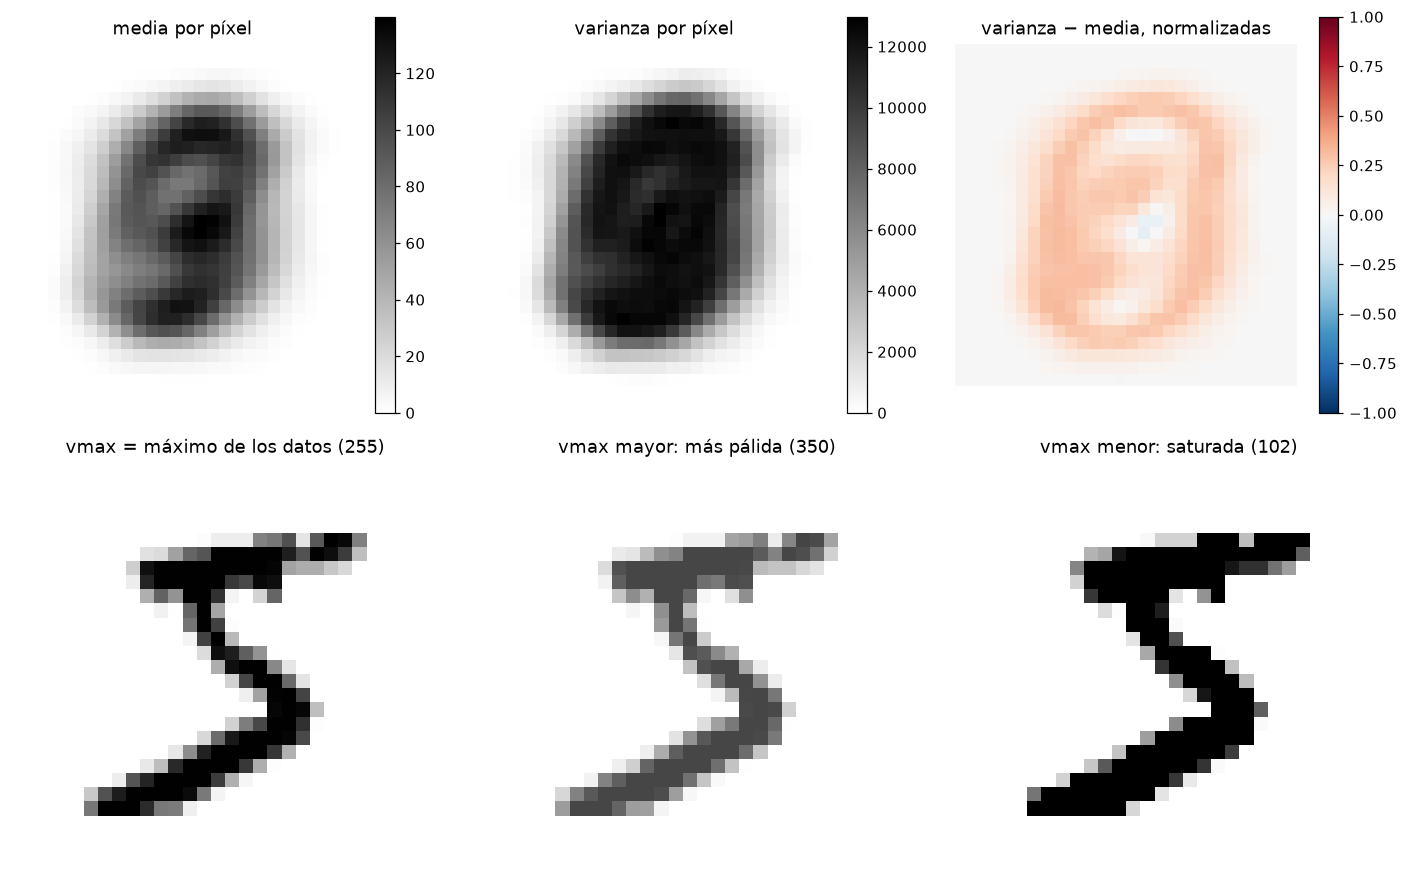

In [34]:
# Demostración 32: Imagen media, imagen de varianza y escala de color
X, y = cargar_mnist(5000)                          # filas = imágenes, valores originales (0 a 255)
lado = int(np.sqrt(X.shape[1]))
mu, va = X.mean(axis=0), X.var(axis=0)             # media y varianza por píxel: vectores 1×P
minmax = lambda v: (v - v.min()) / (v.max() - v.min())
print("media entre", mu.min(), "y", round(mu.max(), 2), "   varianza entre", va.min(), "y", round(va.max(), 2))

fig, ax = plt.subplots(2, 3, figsize=(13, 8))
paneles = [(mu, "media por píxel", "gray_r", None), (va, "varianza por píxel", "gray_r", None),
           (minmax(va) - minmax(mu), "varianza − media, normalizadas", "RdBu_r", 1)]
for a, (img, t, cm, lim) in zip(ax[0], paneles):
    im = a.imshow(img.reshape(lado, lado), cmap=cm, vmin=-lim if lim else None, vmax=lim)
    a.set_title(t); fig.colorbar(im, ax=a)
vmax = X.max()                                     # la misma imagen con tres escalas de color
for a, v, t in zip(ax[1], [vmax, vmax * 350 / 255, vmax * 0.4], ["vmax = máximo de los datos", "vmax mayor: más pálida", "vmax menor: saturada"]):
    a.imshow(X[0].reshape(lado, lado), cmap="gray_r", vmin=0, vmax=v); a.set_title(f"{t} ({v:.3g})")
for a in ax.flat:
    a.axis("off")
plt.tight_layout(); plt.show()

**Qué observar:** Media y varianza tienen la misma estructura (las dos valen 0 en el borde), pero la varianza se enciende en los bordes del trazo, donde las imágenes más cambian. En la fila de abajo los datos son los mismos: solo cambia `vmax`.

**Prueba a cambiar:** Calcula la media y la varianza de una sola clase, por ejemplo con `X[y == 3]`.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Leer la matriz o gráfica.** ¿Se parecen la imagen de la media y la de la varianza?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** En estructura sí; en escala no.
2. **Por qué.** Las dos valen 0 en el borde, pero la media dice dónde hay trazo y la varianza dónde cambia el trazo.
3. **Con los datos.** La varianza se enciende más en los bordes del dígito.

</details>

**Espacio.** ¿Están en escala la media y la varianza?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** No.
2. **Por qué.** Los píxeles van de 0 a 255; en MNIST la media por píxel llega a unos 140 y la varianza a unos 13 000.
3. **Con los datos.** Se normalizan con min-max a $[0,1]$ antes de compararlas.

</details>

**Extremos.** ¿Qué pasa si pongo `vmax=350` en una imagen que llega hasta 255?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Se ve más pálida.
2. **Por qué.** Ningún píxel llega al color máximo.
3. **Con los datos.** Los datos no cambiaron, solo la escala de color.

</details>

## 31. Matriz de correlación de píxeles y el ε

*Fuente: clase grabada de práctica con MNIST.*

**Resultado**

$$\rho_{ij}=\frac{\Sigma_{ij}}{\sigma_i\sigma_j+\varepsilon}$$

$$\mathbf{R}=\Sigma\oslash\big(\boldsymbol\sigma^T\boldsymbol\sigma+\varepsilon\big)\in\mathbb{R}^{P\times P},\quad\boldsymbol\sigma=\sqrt{\operatorname{diag}(\Sigma)}\in\mathbb{R}^{1\times P}$$

**Idea:** Es el índice de Pearson (demostración 10) calculado para todos los pares de píxeles a la vez. El denominador $\sigma_i\sigma_j$ de todos los pares es un producto exterior, y la división es elemento a elemento, así que el tamaño no cambia. El problema aparece en los píxeles del borde de MNIST: valen 0 en todas las imágenes, su varianza es 0 y la división da $\frac00$. El $\varepsilon$ lo resuelve, y debe elegirlo uno mismo.

**Lo que dijo en clase.** Tu profesor insiste en no dejarle la decisión a Python. Con la advertencia de división entre cero, Python pone NaN por su cuenta. Si eliges tú el $\varepsilon$ (pequeño frente a las varianzas, por ejemplo $10^{-8}$ veces la mayor), sabes exactamente qué diferencia introduces en el resultado.

**Qué muestra la gráfica:** La varianza de cada píxel como imagen, los píxeles que nunca cambian y la matriz de correlación de los píxeles sin $\varepsilon$ y con $\varepsilon$.

tamaño de Σ: (784, 784)    píxeles con varianza 0: 145 de 784
NaN sin ε: 206335    NaN con ε: 0


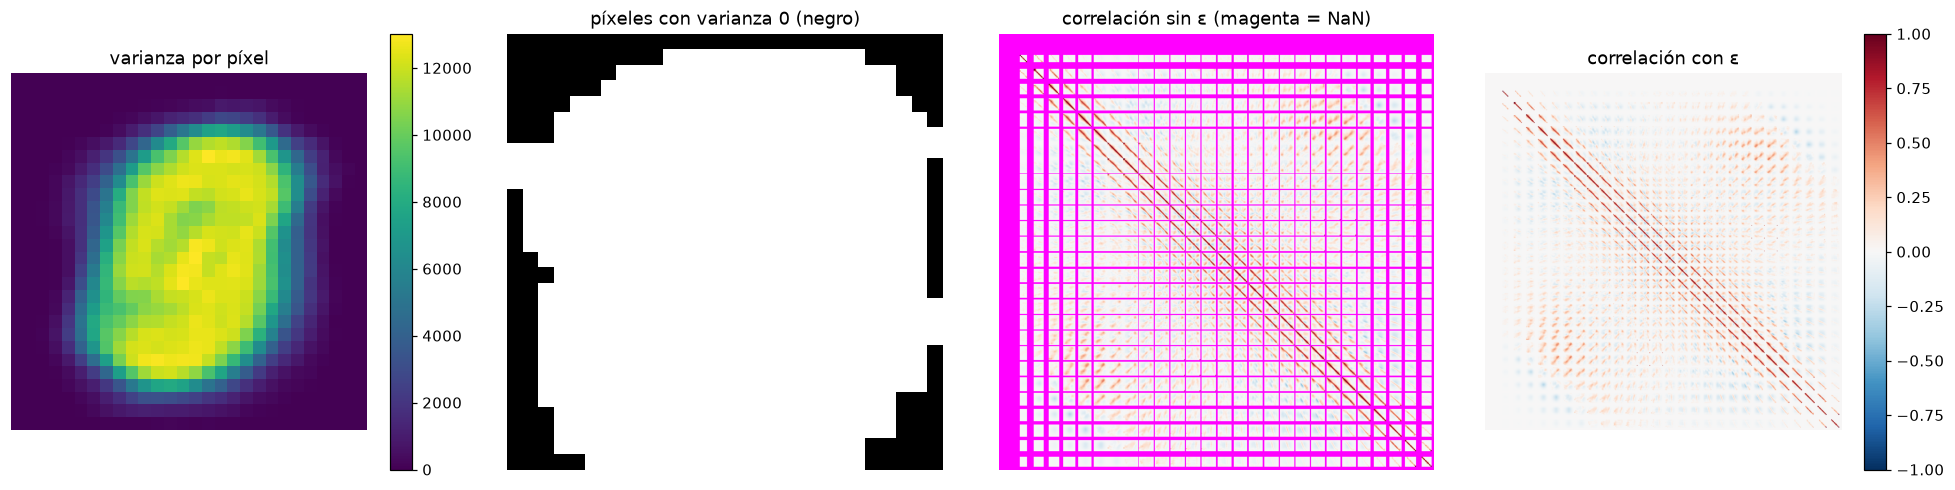

In [35]:
# Demostración 31: Matriz de correlación de píxeles y el ε
X, y = cargar_mnist(2000)                          # N×P, filas = imágenes
N, P = X.shape; lado = int(np.sqrt(P))
Xc = X - X.mean(axis=0)                            # X − 1_N μ (Caso 1)
S = Xc.T @ Xc / N                                  # covarianza de los píxeles: P×P
sd = np.sqrt(np.diag(S))                           # desviación de cada píxel: 1×P
print("tamaño de Σ:", S.shape, "   píxeles con varianza 0:", int(np.sum(sd == 0)), "de", P)

with np.errstate(divide="ignore", invalid="ignore"):
    R_sin = S / np.outer(sd, sd)                   # σᵀσ es P×P; los píxeles quietos dan 0/0 = NaN
eps = 1e-8 * sd.max()**2                           # ε elegido por nosotros, pequeño frente a las varianzas
R = S / (np.outer(sd, sd) + eps)
print("NaN sin ε:", int(np.isnan(R_sin).sum()), "   NaN con ε:", int(np.isnan(R).sum()))

fig, ax = plt.subplots(1, 4, figsize=(18, 4.4))
im = ax[0].imshow((sd**2).reshape(lado, lado), cmap="viridis"); ax[0].set_title("varianza por píxel"); fig.colorbar(im, ax=ax[0])
ax[1].imshow((sd == 0).reshape(lado, lado), cmap="gray_r"); ax[1].set_title("píxeles con varianza 0 (negro)")
ax[2].imshow(R_sin, cmap=plt.get_cmap("RdBu_r").with_extremes(bad="magenta"), vmin=-1, vmax=1)
ax[2].set_title("correlación sin ε (magenta = NaN)")
im = ax[3].imshow(R, cmap="RdBu_r", vmin=-1, vmax=1); ax[3].set_title("correlación con ε"); fig.colorbar(im, ax=ax[3])
for a in ax:
    a.axis("off")
plt.tight_layout(); plt.show()

**Qué observar:** Los píxeles del borde tienen varianza 0, así que su fila y su columna de la correlación salen NaN (las franjas magenta). Con $\varepsilon$ esas franjas pasan a 0 y el resto de la matriz no cambia.

**Prueba a cambiar:** Sube `eps` a `1e-1 * sd.max()**2`: todas las correlaciones se apagan y la diagonal deja de valer 1.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Justificación.** ¿Por qué sale la advertencia de división entre cero al calcular la correlación?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque hay píxeles con varianza 0.
2. **Por qué.** Los píxeles del borde valen 0 en todas las imágenes, y la correlación divide entre las varianzas de la diagonal de la covarianza.
3. **Con los datos.** Por eso se suma un $\varepsilon$ que controlamos nosotros.

</details>

**Efecto de un cambio.** ¿Afecta el $\varepsilon$ al resultado?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** No, si es pequeño.
2. **Por qué.** Comparado con las varianzas reales, casi no cambia los cocientes.
3. **Con los datos.** Solo convierte los NaN de los bordes en 0.

</details>

**Dimensiones.** ¿De qué tamaño es $\boldsymbol\sigma^T\boldsymbol\sigma$ y por qué?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $784\times784$.
2. **Por qué.** $(784\times1)(1\times784)$, para dividir elemento a elemento a $\Sigma$.
3. **Con los datos.** La correlación mantiene el tamaño de la covarianza.

</details>

**Leer la matriz o gráfica.** ¿Qué significan las franjas magenta (NaN) en la correlación sin $\varepsilon$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Son los píxeles del borde.
2. **Por qué.** Su fila y su columna dan $\frac00$.
3. **Con los datos.** Con el $\varepsilon$ esas franjas pasan a 0.

</details>

## 33. Kernel RBF entre clases: matriz 100×100 y correlación en el RKHS

*Fuente: clase grabada de práctica con MNIST (ejercicio final).*

**Resultado**

$$\mathbb{K}_{ij}=\exp\Big\{-\frac{\|x_i-x_j\|^2}{2\sigma^2}\Big\}$$

$$\mathbb{K}_c=H\mathbb{K}H$$

$$\rho_{\mathcal H}(i,j)=\frac{(\mathbb{K}_c)_{ij}}{\sqrt{(\mathbb{K}_c)_{ii}(\mathbb{K}_c)_{jj}}+\varepsilon}$$

**Idea:** Es el índice de Pearson, pero entre imágenes y en el espacio de características: la covarianza es el kernel centrado ($H\mathbb{K}H$) y las "varianzas" son su diagonal. Si las filas de $\mathbb{X}$ están ordenadas por clase, la matriz $100\times100$ muestra bloques: los de la diagonal comparan imágenes de la misma clase y los de fuera revelan qué clases se parecen entre sí.

**Lo que dijo en clase.** En el RKHS ya no se puede graficar por píxeles, como se hacía con la covarianza original. Cada imagen es un vector $\varphi(x)$ de dimensión $Q\to\infty$ que nunca se construye, así que lo único que existe es la matriz $N\times N$ entre imágenes. Para apilar las clases en orden se usa `np.vstack`, no `reshape`, que puede desordenar las imágenes.

**Qué muestra la gráfica:** La matriz kernel de 100 imágenes ordenadas por clase, su correlación en el RKHS y el promedio de cada bloque clase por clase.

clases que más se parecen: 7 y 9 (0.09), 1 y 5 (0.06), 4 y 7 (0.02), 0 y 2 (0.02)


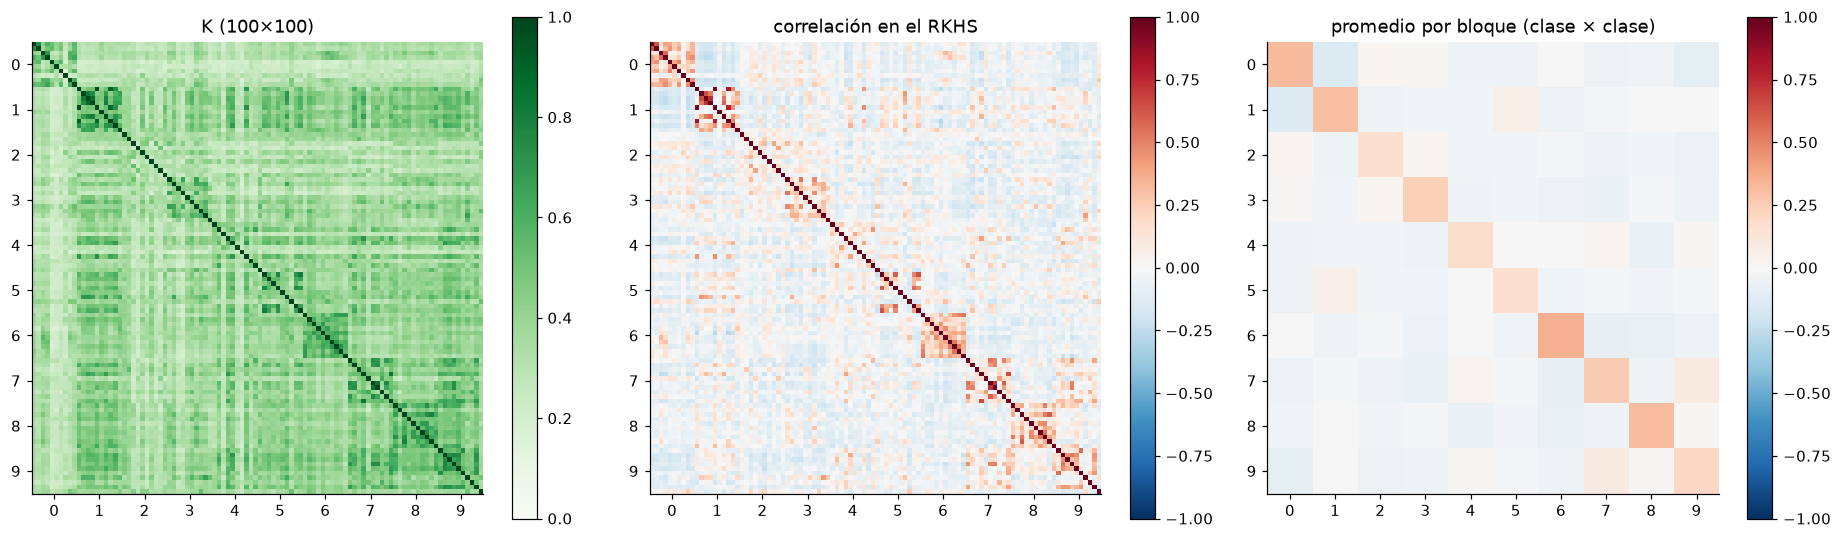

In [36]:
# Demostración 33: Kernel RBF entre clases: matriz 100×100 y correlación en el RKHS
X, y = cargar_mnist(10000)
X = X / X.max()
Xo = np.vstack([X[y == c][:10] for c in range(10)])           # 100×P: 10 imágenes por clase, en orden (vstack, no reshape)
z = (Xo**2).sum(1)
D = np.maximum(z[:, None] - 2 * Xo @ Xo.T + z[None, :], 0)    # distancias sin bucles (demostración 28)
mediana = np.median(D[D > 0])
H = np.eye(100) - np.ones((100, 100)) / 100

def rkhs(factor=1.0):
    K = np.exp(-D / (factor * mediana))                         # 2σ² = factor · mediana
    Kc = H @ K @ H                                              # kernel centrado
    d = np.sqrt(np.clip(np.diag(Kc), 0, None))
    R = Kc / (np.outer(d, d) + 1e-12)                           # correlación en el RKHS
    B = R.reshape(10, 10, 10, 10).mean(axis=(1, 3))             # promedio de cada bloque 10×10
    pares = sorted(((B[a, b], a, b) for a in range(10) for b in range(a + 1, 10)), reverse=True)
    print("clases que más se parecen:", ", ".join(f"{a} y {b} ({v:.2f})" for v, a, b in pares[:4]))
    fig, ax = plt.subplots(1, 3, figsize=(17, 5))
    for a, M, t, cm, lo in [(ax[0], K, "K (100×100)", "Greens", 0), (ax[1], R, "correlación en el RKHS", "RdBu_r", -1),
                            (ax[2], B, "promedio por bloque (clase × clase)", "RdBu_r", -1)]:
        im = a.imshow(M, cmap=cm, vmin=lo, vmax=1); a.set_title(t); fig.colorbar(im, ax=a); a.grid(False)
        paso = 10 if M.shape[0] == 100 else 1
        a.set_xticks(np.arange(10) * paso + (paso - 1) / 2, range(10)); a.set_yticks(np.arange(10) * paso + (paso - 1) / 2, range(10))
    plt.tight_layout(); plt.show()

interactivo(rkhs, factor=(0.05, 20.0, 0.05, 1.0))

**Qué observar:** Los bloques de la diagonal son claros: las imágenes de una misma clase se parecen. Un bloque claro fuera de la diagonal señala dos clases que se confunden; la celda imprime las cuatro parejas más parecidas.

**Prueba a cambiar:** Mueve el deslizador `factor` hacia 0.05 y hacia 20. Con 0.05 desaparecen los bloques de las dos matrices. Con 20, $\mathbb{K}$ queda casi todo en 1, pero la correlación en el RKHS conserva los bloques: al centrar, se vuelve la correlación con el kernel lineal.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Leer la matriz o gráfica.** "¿Quién está acá?": un bloque claro en la fila 4 y la columna 9, ¿tiene sentido?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Sí: el 4 se parece al 9.
2. **Por qué.** Comparten el trazo vertical y la parte de arriba casi cerrada.
3. **Con los datos.** Es una confusión típica, pero depende de $\sigma$ y de las imágenes que se tomen: la celda imprime las parejas que más se parecen en tu muestra.

</details>

**Justificación.** ¿Por qué la diagonal de la correlación en el RKHS da 1?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque cada imagen se compara consigo misma.
2. **Por qué.** Se divide entre la raíz de la diagonal: $\frac{(\mathbb{K}_c)_{ii}}{(\mathbb{K}_c)_{ii}}=1$.
3. **Con los datos.** Igual que en Pearson (demostración 10).

</details>

**Espacio.** ¿Puedo graficar esta covarianza por píxeles, como la original?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** No.
2. **Por qué.** En el RKHS no hay columnas-píxel: cada imagen es $\varphi(x)$ de dimensión infinita.
3. **Con los datos.** Solo existe la matriz $100\times100$ entre imágenes.

</details>

**Dimensiones.** ¿De qué tamaño nos va a dar la matriz?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $100\times100$.
2. **Por qué.** Compara cada imagen con cada imagen: $N\times N$.
3. **Con los datos.** No depende de los 784 píxeles.

</details>

**Extremos.** ¿Qué pasa con los bloques si $\sigma$ es muy grande o muy pequeño?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** En $\mathbb{K}$ desaparecen en los dos extremos. En la correlación del RKHS solo desaparecen con $\sigma$ pequeño.
2. **Por qué.** Con $\sigma$ pequeño, $\mathbb{K}\to I$ y nada se parece. Con $\sigma$ grande, $\mathbb{K}\approx\mathbf{1}\mathbf{1}^T-\frac{\mathbf{D}}{2\sigma^2}$; como $H\mathbf{1}=0$, al centrar queda $H\mathbb{K}H\approx\frac{1}{\sigma^2}H\mathbb{X}\mathbb{X}^TH$, y al normalizar el $\frac{1}{\sigma^2}$ se cancela: es la correlación con el kernel lineal.
3. **Con los datos.** Con MNIST y `factor` = 20, los bloques de la diagonal promedian 0.31 y los de fuera −0.03, lo mismo que con el kernel lineal.

</details>

# Ejercicios resueltos

Nueve ejercicios de métodos kernel, espacios de características y formulación matricial. Cada uno trae el enunciado, la solución paso a paso, una gráfica que la comprueba y preguntas de práctica. Los marcados como *Visto en clase* se resolvieron en la sesión del 7 de octubre; los demás tienen una solución propuesta, armada con las demostraciones del mapa.

**1. Regresión en espacios de características y formulación kernel**

- **1.1. Mínimos cuadrados regularizados en el espacio de características.** Función objetivo, variable desconocida y papel de $\lambda$. *Visto en clase.*
- **1.2. Solución matricial del estimador regularizado.** Notación matricial, condiciones de optimalidad y forma con kernels. *Visto en clase.*
- **1.3. Mapeo polinómico: matriz de diseño y verificación en código.** Matriz de diseño con $\varphi(x)=[1,x,x^2]^T$, pesos teóricos y reconstrucción. *Visto en clase.*
- **1.4. Truco del kernel a partir de la SVD.** Por qué $\Phi^T\Phi$ y $\Phi\Phi^T$ tienen la misma información y basta la matriz de Gram. *Visto en clase.*

**2. Espacios RKHS, embeddings de media y discrepancia entre distribuciones**

- **2.1. Embedding de media empírico con kernel lineal y RBF.** $\hat\mu_P(z)=\frac1N\sum_n k(x_n,z)$ con kernel lineal y RBF, y los extremos de $\sigma$. *Visto en clase.*
- **2.2. Momentos brutos, centrados y estandarizados.** Las tres referencias en el espacio original y sus matrices en el espacio del kernel. *Solución propuesta.*
- **2.3. Discrepancia entre clases de MNIST con el MMD.** $\|\mu_P-\mu_Q\|^2$ en forma matricial y la matriz $10\times10$ entre clases. *Visto en clase.*

**3. Forma matricial de kernels y geometría inducida**

- **3.1. Matriz de distancias cuadradas en forma matricial.** $\mathbf{D}=\mathbf{z}\mathbf{1}^T+\mathbf{1}\mathbf{z}^T-2\mathbb{X}\mathbb{X}^T$ con la matriz de datos, las normas y el vector de unos. *Solución propuesta.*
- **3.2. Matriz kernel RBF: diagonal, simetría y semidefinición positiva.** Diagonal 1 (esfera unitaria), simetría y valores propios no negativos. *Solución propuesta.*

**Antes de responder**

- Justifica cada paso y nombra la propiedad que usas: linealidad del valor esperado, transpuesta de un escalar, propiedad reproductora, ortonormalidad de $U$ y $V$.
- Escribe las dimensiones de cada objeto: $t\in\mathbb{R}^{N}$, $\Phi\in\mathbb{R}^{N\times Q}$, $w\in\mathbb{R}^{Q}$, $\mathbb{K}\in\mathbb{R}^{N\times N}$.
- Distingue el espacio original, el espacio de características, el RKHS y la formulación matricial.
- Di qué es variable (los pesos) y qué es constante (los datos, el mapeo y $\lambda$).
- Explica el término de regularización y cómo se elige $\lambda$.
- Cierra con una respuesta en términos generales: qué significa el resultado.

## 1. Regresión en espacios de características y formulación kernel

### Ejercicio 1.1. Mínimos cuadrados regularizados en el espacio de características

*Visto en la sesión del 7 de octubre.*

**Enunciado.** Datos i.i.d. $\{(x_n,t_n)\}_{n=1}^{N}$ con $x_n\in\mathbb{R}^P$ y $t_n\in\mathbb{R}$, un mapeo $\varphi:\mathbb{R}^P\to\mathcal H$ (no necesariamente de dimensión finita) y el modelo $t_n=\langle w,\varphi(x_n)\rangle_{\mathcal H}+\eta_n$, con $\eta_n\sim\mathcal N(0,\sigma_\eta^2)$. Formule el problema de mínimos cuadrados regularizados en $\mathcal H$: escriba la función objetivo, indique la variable desconocida y explique el papel del parámetro de regularización.

**Resultado**

$$\hat w=\arg\min_{w\in\mathcal H}\ \sum_{n=1}^{N}\big(t_n-\langle w,\varphi(x_n)\rangle_{\mathcal H}\big)^2+\lambda\|w\|_{\mathcal H}^2,\qquad \lambda\gt 0$$

**Idea de la solución:** Cada dato tiene un valor real $t_n$ (el objetivo) y una reconstrucción $\langle w,\varphi(x_n)\rangle$. Se busca que se parezcan, y lo único que se puede mover son los pesos $w$: los datos, el mapeo y $\lambda$ están fijos. El término $\lambda\|w\|^2$ castiga los pesos grandes, que son los que terminan ajustando el ruido.

**Solución paso a paso**

**Paso 1.** Identificar cada pieza del modelo. El producto interno en $\mathcal H$ es un número: el valor reconstruido para la muestra $n$.

$$\underbrace{t_n}_{\text{valor real}}=\underbrace{\langle w,\varphi(x_n)\rangle_{\mathcal H}}_{\text{reconstrucción}}+\underbrace{\eta_n}_{\text{ruido}},\qquad\langle w,\varphi(x_n)\rangle_{\mathcal H}=w^T\varphi(x_n)\in\mathbb{R}$$

**Paso 2.** Variable desconocida: los pesos $w\in\mathcal H$, un vector $Q\times1$ con $Q$ posiblemente infinito. Constantes: las observaciones $x_n$, los valores reales $t_n$, el mapeo $\varphi$ y $\lambda$.

$$\text{incógnita: }w\qquad\text{datos: }\{(x_n,t_n)\}_{n=1}^{N}\qquad\text{diseño: }\varphi,\ \lambda$$

**Paso 3.** Error de cada muestra y función objetivo de mínimos cuadrados:

$$e_n=t_n-\langle w,\varphi(x_n)\rangle_{\mathcal H},\qquad J_{MC}(w)=\sum_{n=1}^{N}e_n^2$$

**Paso 4.** Mínimos cuadrados regularizados: se suma la norma al cuadrado de los pesos, multiplicada por $\lambda\gt 0$.

$$J(w)=\underbrace{\sum_{n=1}^{N}\big(t_n-\langle w,\varphi(x_n)\rangle_{\mathcal H}\big)^2}_{\text{error de reconstrucción}}+\underbrace{\lambda\|w\|_{\mathcal H}^2}_{\text{penalización}},\qquad\hat w=\arg\min_{w}J(w)$$

**Paso 5.** Papel de $\lambda$: equilibra ajustar los datos frente a mantener los pesos pequeños.

$$\lambda\to0:\ J\to J_{MC}\ \text{(puede sobreajustar)}\qquad\lambda\to\infty:\ \hat w\to0\ \text{(subajusta)}$$

**Paso 6.** Cómo se elige: en mínimos cuadrados regularizados es un hiperparámetro del diseñador, que se ajusta por validación cruzada. Si se plantea como MAP con un prior gaussiano sobre los pesos, $w\sim\mathcal N(0,\sigma_w^2I)$, deja de ser arbitrario (demostración 20):

$$\lambda=\frac{\sigma_\eta^2}{\sigma_w^2}$$

**Sobre lo visto en clase.** Dos precisiones. Primero, $\lambda$ siempre es positivo: con $\lambda\lt 0$ se premiarían los pesos grandes y la matriz $\Phi^T\Phi+\lambda I$ podría dejar de ser invertible (es el mismo error de signo de la demostración 18). Segundo, la analogía de la pelota que cae en un valle sirve para problemas no convexos, como las redes neuronales. Aquí $J(w)$ es convexo y tiene un solo mínimo, así que $\lambda$ no ayuda a escapar de mínimos locales: controla el tamaño de los pesos y garantiza que la solución sea única.

**Qué muestra la gráfica:** La reconstrucción con un mapeo polinómico de grado 9, las dos partes de $J(w)$ para el $\lambda$ elegido y, abajo, el tamaño de los pesos y el error al recorrer todos los valores de $\lambda$.

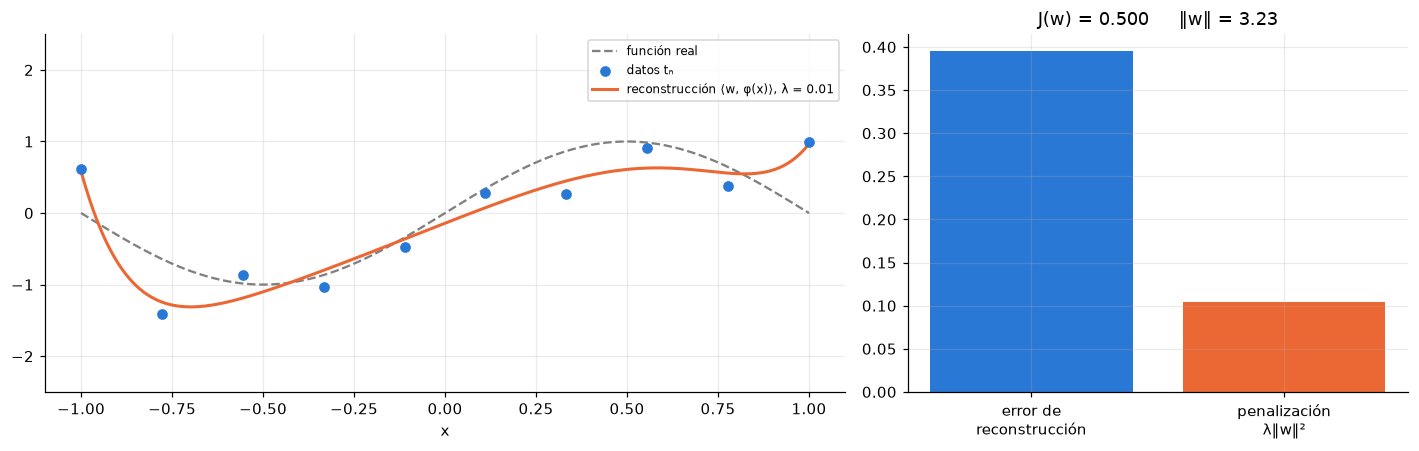

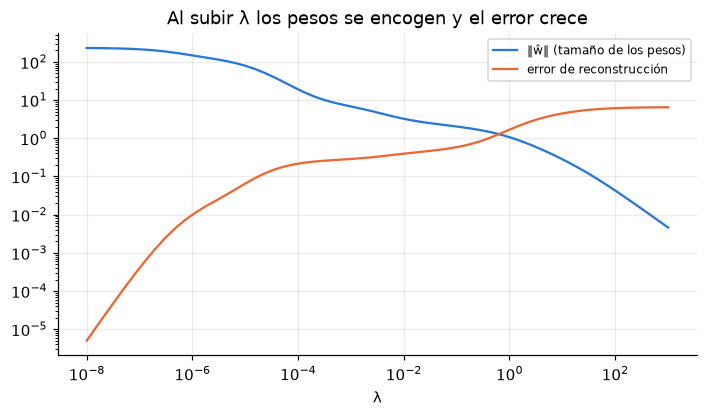

In [37]:
# Ejercicio 1.1: Mínimos cuadrados regularizados en el espacio de características
rng_e = np.random.default_rng(3)
N, grado = 10, 9
x = np.linspace(-1, 1, N)
f = lambda x: np.sin(np.pi * x)                                # función que genera los datos
t = f(x) + 0.3 * rng_e.normal(size=N)                          # tₙ = f(xₙ) + ηₙ
Phi = np.vander(x, grado + 1, increasing=True)                 # φ(x) = [1, x, …, x⁹]: matriz de diseño N×Q, Q = 10
z = np.linspace(-1, 1, 300); Pz = np.vander(z, grado + 1, increasing=True)

def ajustar(lam):                                              # ŵ = argmin ‖t − Φw‖² + λ‖w‖² = (ΦᵀΦ + λI)⁻¹ Φᵀt
    return np.linalg.solve(Phi.T @ Phi + lam * np.eye(grado + 1), Phi.T @ t)

def papel_de_lambda(log10_lambda=-2.0):
    lam = 10 ** log10_lambda
    w = ajustar(lam)
    error, penal = np.sum((t - Phi @ w)**2), lam * w @ w
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
    ax[0].plot(z, f(z), "--", color="0.5", label="función real")
    ax[0].scatter(x, t, color=SERIE[0], zorder=3, label="datos tₙ")
    ax[0].plot(z, Pz @ w, color=SERIE[1], lw=2, label=f"reconstrucción ⟨w, φ(x)⟩, λ = {lam:.2g}")
    ax[0].set_ylim(-2.5, 2.5); ax[0].legend(fontsize=8); ax[0].set_xlabel("x")
    ax[1].bar(["error de\nreconstrucción", "penalización\nλ‖w‖²"], [error, penal], color=[SERIE[0], SERIE[1]])
    ax[1].set_title(f"J(w) = {error + penal:.3f}     ‖w‖ = {np.linalg.norm(w):.2f}")
    plt.tight_layout(); plt.show()

interactivo(papel_de_lambda, log10_lambda=(-8.0, 3.0, 0.25, -2.0))

lams = np.logspace(-8, 3, 60)                                  # recorrido completo de λ
W = np.array([ajustar(l) for l in lams])
plt.figure(figsize=(7.5, 3.8))
plt.plot(lams, np.linalg.norm(W, axis=1), color=SERIE[0], label="‖ŵ‖ (tamaño de los pesos)")
plt.plot(lams, [np.sum((t - Phi @ w)**2) for w in W], color=SERIE[1], label="error de reconstrucción")
plt.xscale("log"); plt.yscale("log"); plt.xlabel("λ"); plt.legend(fontsize=8)
plt.title("Al subir λ los pesos se encogen y el error crece"); plt.show()

**Qué observar:** Con $\lambda$ casi 0 la curva pasa por todos los puntos y oscila: el error es pequeño, pero $\|w\|$ es enorme (sobreajuste). Al subir $\lambda$ la penalización gana, los pesos se encogen y la curva se aplana hasta subajustar.

**Prueba a cambiar:** Mueve `log10_lambda` de −8 a 3 y busca el valor en que la reconstrucción se parece más a la función real.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Interpretación.** ¿Cuál es la variable desconocida y cuáles son las constantes?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Solo los pesos $w$; todo lo demás es constante.
2. **Por qué.** Los valores reales $t_n$ y las observaciones $x_n$ son datos que no se pueden cambiar; $\varphi$ y $\lambda$ los fija el diseñador.
3. **Con los datos.** Se busca el $w$ cuya reconstrucción $w^T\varphi(x_n)$ más se parece a cada $t_n$.

</details>

**Dimensiones.** ¿De qué tamaño son $\varphi(x_n)$, $w$ y $\langle w,\varphi(x_n)\rangle$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $Q\times1$, $Q\times1$ y $1\times1$: un número.
2. **Por qué.** El producto interno de dos vectores del mismo espacio es un escalar.
3. **Con los datos.** Con el mapeo del ejercicio 1.3, $Q=3$; con el RBF, $Q\to\infty$.

</details>

**Justificación.** ¿Para qué se suma $\lambda\|w\|^2$ a la función de error?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Para castigar los pesos muy grandes.
2. **Por qué.** Los pesos grandes terminan ajustando el ruido (sobreajuste); la penalización mueve el mínimo hacia pesos más pequeños.
3. **Con los datos.** Con $\lambda$ grande la curva ajustada se vuelve más suave.

</details>

**Extremos.** ¿Qué pasa si $\lambda\to0$? ¿Y si $\lambda\to\infty$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Se vuelve mínimos cuadrados ordinarios, o los pesos tienden a 0.
2. **Por qué.** $\lambda$ pesa la penalización frente al error de reconstrucción.
3. **Con los datos.** Con $\lambda\to\infty$ la predicción es 0 para todos los datos.

</details>

**Justificación.** ¿Cómo se escoge $\lambda$? ¿Es un hiperparámetro?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Sí: en mínimos cuadrados regularizados lo elige el diseñador, por ejemplo con validación cruzada.
2. **Por qué.** Si se plantea como MAP con un prior gaussiano sobre los pesos, deja de ser arbitrario: $\lambda=\sigma_\eta^2/\sigma_w^2$.
3. **Con los datos.** Mucho ruido o un prior estrecho dan más regularización (demostración 20).

</details>

**Efecto de un cambio.** ¿Afecta usar un $\lambda$ negativo?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Sí: deja de regularizar.
2. **Por qué.** Con $\lambda\lt 0$ se premian los pesos grandes y $\Phi^T\Phi+\lambda I$ puede dejar de ser invertible.
3. **Con los datos.** Por eso siempre $\lambda\gt 0$.

</details>

### Ejercicio 1.2. Solución matricial del estimador regularizado

*Visto en la sesión del 7 de octubre.*

**Enunciado.** A partir del problema del ejercicio 1.1, obtenga su solución: escriba el problema en notación matricial, desarrolle las condiciones de optimalidad paso a paso y llegue a la expresión final del estimador.

**Resultado**

$$\hat w=(\Phi^T\Phi+\lambda I_Q)^{-1}\Phi^Tt$$

$$=\Phi^T(\mathbb{K}+\lambda I_N)^{-1}t,\quad\mathbb{K}=\Phi\Phi^T$$

**Idea de la solución:** Apilar las $N$ ecuaciones convierte la suma de errores en una norma, $\|t-\Phi w\|^2$. El costo es una parábola en $w$ (convexa), así que el mínimo está donde el gradiente vale cero. La segunda forma de la solución solo usa $\mathbb{K}=\Phi\Phi^T$, la matriz $N\times N$ de productos internos, y por eso abre la puerta a los kernels.

**Solución paso a paso**

**Paso 1.** Notación matricial: el vector de valores reales, la matriz de diseño (una fila por muestra transformada) y los pesos.

$$t=\begin{bmatrix}t_1\\\vdots\\t_N\end{bmatrix}\in\mathbb{R}^{N},\qquad\Phi=\begin{bmatrix}\varphi(x_1)^T\\\vdots\\\varphi(x_N)^T\end{bmatrix}\in\mathbb{R}^{N\times Q},\qquad w\in\mathbb{R}^{Q}$$

**Paso 2.** Todas las reconstrucciones a la vez son $\Phi w\in\mathbb{R}^N$, y la suma de errores es una norma al cuadrado:

$$\sum_{n=1}^{N}\big(t_n-w^T\varphi(x_n)\big)^2=\|t-\Phi w\|_2^2\;\Longrightarrow\;J(w)=\|t-\Phi w\|_2^2+\lambda\,w^Tw$$

**Paso 3.** Expandir la norma (demostración 5). Como $t^T\Phi w$ es un escalar, es igual a su transpuesto $w^T\Phi^Tt$:

$$J(w)=(t-\Phi w)^T(t-\Phi w)+\lambda w^Tw=t^Tt-2\,t^T\Phi w+w^T\Phi^T\Phi w+\lambda\,w^Tw$$

**Paso 4.** Condición de primer orden: el gradiente respecto a $w$ es un vector $Q\times1$ y debe valer cero.

$$\nabla_wJ=-2\Phi^Tt+2\Phi^T\Phi w+2\lambda w=0$$

**Paso 5.** Agrupar $w$ escribiendo $\lambda w=\lambda I_Qw$ y despejar. Tamaños: $(Q\times Q)^{-1}(Q\times N)(N\times1)=Q\times1$.

$$(\Phi^T\Phi+\lambda I_Q)\,w=\Phi^Tt\;\Longrightarrow\;\hat w=(\Phi^T\Phi+\lambda I_Q)^{-1}\Phi^Tt$$

**Paso 6.** Condición de segundo orden: la Hessiana es definida positiva para $\lambda\gt 0$, así que el punto es un mínimo y es único. Con $\lambda=0$ se recupera mínimos cuadrados ordinarios.

$$\nabla_w^2J=2(\Phi^T\Phi+\lambda I_Q)\succ0,\qquad\lambda=0:\ \hat w=(\Phi^T\Phi)^{-1}\Phi^Tt$$

**Paso 7.** Forma con kernels. Se cumple $\Phi^T(\Phi\Phi^T+\lambda I_N)=(\Phi^T\Phi+\lambda I_Q)\Phi^T$; al multiplicar por las dos inversas aparece otra expresión del mismo estimador:

$$\hat w=\Phi^T\underbrace{(\mathbb{K}+\lambda I_N)^{-1}t}_{\alpha\in\mathbb{R}^{N}}=\sum_{n=1}^{N}\alpha_n\varphi(x_n)$$

**Paso 8.** Predicción para un dato nuevo $x$: solo necesita kernels, nunca $\varphi$.

$$\hat t(x)=\hat w^T\varphi(x)=\sum_{n=1}^{N}\alpha_nK(x_n,x)=\mathbf{k}(x)^T(\mathbb{K}+\lambda I_N)^{-1}t,\qquad\mathbf{k}(x)=\begin{bmatrix}K(x_1,x)\\\vdots\\K(x_N,x)\end{bmatrix}$$

**Sobre la solución vista en clase.** En la solución de clase la matriz de diseño se llamó $F$ y el costo se escribió con $\frac1N$: $J(w)=\frac1N\|t-Fw\|^2+\lambda\|w\|^2$. Ese factor no cambia el estimador sin regularización, pero con regularización cambia la escala de $\lambda$: queda $\hat w=(F^TF+N\lambda I)^{-1}F^Tt$. Además, al derivar cada término debe quedar como vector $Q\times1$: la derivada de $w^TF^TFw$ es $2F^TFw$ y la de $\lambda w^Tw$ es $2\lambda w$.

**Qué muestra la gráfica:** Los pesos calculados con la forma primal y con la dual, el vector $\alpha$ con un peso por muestra y las predicciones con un polinomio y con un kernel RBF.

¿primal = dual? True    tamaños: ΦᵀΦ (4, 4)  K (15, 15)


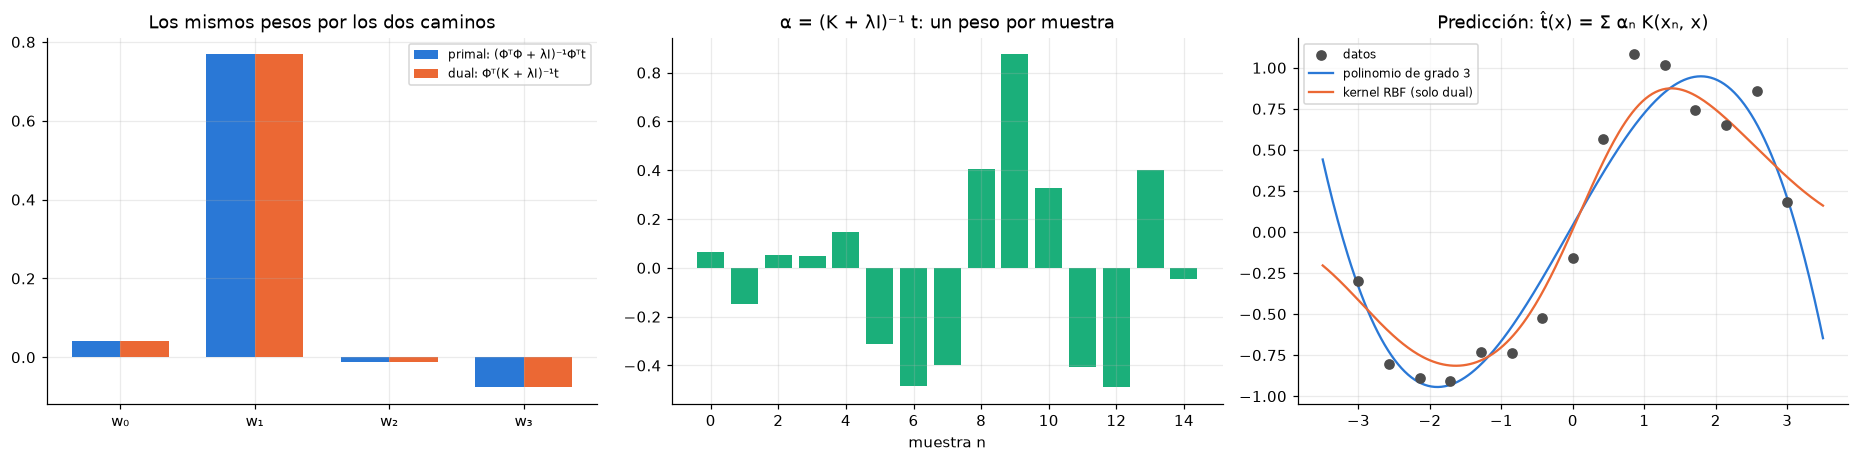

In [38]:
# Ejercicio 1.2: Solución matricial del estimador regularizado
rng_e = np.random.default_rng(5)
N, lam = 15, 0.5
x = np.linspace(-3, 3, N)
t = np.sin(x) + 0.2 * rng_e.normal(size=N)
Phi = np.vander(x, 4, increasing=True)                         # [1, x, x², x³]: N×Q con Q = 4

w_primal = np.linalg.solve(Phi.T @ Phi + lam * np.eye(4), Phi.T @ t)   # (ΦᵀΦ + λI_Q) w = Φᵀt: sistema Q×Q
K = Phi @ Phi.T                                                        # K = ΦΦᵀ: N×N
alpha = np.linalg.solve(K + lam * np.eye(N), t)                        # α = (K + λI_N)⁻¹ t: sistema N×N
w_dual = Phi.T @ alpha                                                 # w = Φᵀα
print("¿primal = dual?", np.allclose(w_primal, w_dual), "   tamaños: ΦᵀΦ", (4, 4), " K", K.shape)

rbf = lambda A, B, s2=1.0: np.exp(-(A[:, None] - B[None, :])**2 / (2 * s2))
a_rbf = np.linalg.solve(rbf(x, x) + lam * np.eye(N), t)               # con el RBF (Q → ∞) solo existe la dual
z = np.linspace(-3.5, 3.5, 300)

fig, ax = plt.subplots(1, 3, figsize=(17, 4.3))
k = np.arange(4)
ax[0].bar(k - 0.18, w_primal, 0.36, color=SERIE[0], label="primal: (ΦᵀΦ + λI)⁻¹Φᵀt")
ax[0].bar(k + 0.18, w_dual, 0.36, color=SERIE[1], label="dual: Φᵀ(K + λI)⁻¹t")
ax[0].set_xticks(k, ["w₀", "w₁", "w₂", "w₃"]); ax[0].legend(fontsize=8); ax[0].set_title("Los mismos pesos por los dos caminos")
ax[1].bar(np.arange(N), alpha, color=SERIE[2]); ax[1].set_xlabel("muestra n"); ax[1].set_title("α = (K + λI)⁻¹ t: un peso por muestra")
ax[2].scatter(x, t, color="0.3", zorder=3, label="datos")
ax[2].plot(z, np.vander(z, 4, increasing=True) @ w_primal, color=SERIE[0], label="polinomio de grado 3")
ax[2].plot(z, rbf(z, x) @ a_rbf, color=SERIE[1], label="kernel RBF (solo dual)")
ax[2].legend(fontsize=8); ax[2].set_title("Predicción: t̂(x) = Σ αₙ K(xₙ, x)")
plt.tight_layout(); plt.show()

**Qué observar:** Las barras primal y dual coinciden: son el mismo estimador calculado por dos caminos. Con el RBF no hay un $w$ finito que calcular, pero la forma dual predice igual usando solo $K$.

**Prueba a cambiar:** Cambia `lam` a 0.01 y a 10 y compara cómo se ajusta la curva del RBF.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Dimensiones.** ¿De qué tamaño son $t$, $\Phi$, $w$ y $\Phi^T\Phi+\lambda I$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $N\times1$, $N\times Q$, $Q\times1$ y $Q\times Q$.
2. **Por qué.** Cada fila de $\Phi$ es una muestra transformada, $\varphi(x_n)^T$.
3. **Con los datos.** Con el mapeo polinómico, $\Phi$ es $N\times3$ y la matriz a invertir es $3\times3$.

</details>

**Justificación.** ¿Por qué $t^T\Phi w=w^T\Phi^Tt$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque es un escalar.
2. **Por qué.** Un número es igual a su transpuesto.
3. **Con los datos.** Por eso en la expansión aparece $-2\,t^T\Phi w$.

</details>

**Justificación.** ¿Por qué el punto donde el gradiente vale cero es un mínimo y no un máximo?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque $J(w)$ es convexo.
2. **Por qué.** Su Hessiana, $2(\Phi^T\Phi+\lambda I)$, es definida positiva.
3. **Con los datos.** Es un tazón con un solo mínimo (demostración 17).

</details>

**Efecto de un cambio.** ¿Cambia la solución si el costo se escribe con $\frac1N$ delante del error?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Sin regularización no; con regularización cambia la escala de $\lambda$.
2. **Por qué.** $\frac1N\|t-\Phi w\|^2+\lambda\|w\|^2$ da $(\Phi^T\Phi+N\lambda I)^{-1}\Phi^Tt$.
3. **Con los datos.** Es la misma familia de soluciones con $\lambda'=N\lambda$.

</details>

**Espacio.** ¿Qué ventaja tiene escribir $\hat w=\Phi^T(\mathbb{K}+\lambda I)^{-1}t$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Solo invierte una matriz $N\times N$ y no necesita $\varphi$.
2. **Por qué.** $\mathbb{K}=\Phi\Phi^T$ se calcula con el kernel, y la predicción es $\sum_n\alpha_nK(x_n,x)$.
3. **Con los datos.** Funciona aunque $Q\to\infty$, como con el RBF.

</details>

**Extremos.** Si $Q\gt N$ y $\lambda=0$, ¿se puede invertir $\Phi^T\Phi$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** No.
2. **Por qué.** Su rango es como máximo $N\lt Q$, así que tiene valores propios en cero.
3. **Con los datos.** Con $\lambda\gt 0$ se vuelve invertible (demostración 18).

</details>

### Ejercicio 1.3. Mapeo polinómico: matriz de diseño y verificación en código

*Visto en la sesión del 7 de octubre.*

**Enunciado.** Con el mapeo polinómico $\varphi(x)=[1,\ x,\ x^2]^T$ y datos $\{(x_n,t_n)\}_{n=1}^{N}$, construya la matriz de diseño asociada e implemente en Python la solución del ejercicio 1.2. Use un ejemplo numérico sencillo para verificar el resultado e interprete la solución.

**Resultado**

$$\Phi=\begin{bmatrix}1&x_1&x_1^2\\\vdots&\vdots&\vdots\\1&x_N&x_N^2\end{bmatrix}\in\mathbb{R}^{N\times3}$$

$$\hat t(x)=\hat w_0+\hat w_1x+\hat w_2x^2$$

**Idea de la solución:** El mapeo lleva cada número $x_n$ a un vector de tres componentes. El modelo es lineal en los pesos pero cuadrático en $x$: un plano en el espacio de características se ve como una parábola en el espacio original. Para verificar se eligen unos pesos teóricos, se generan datos con ellos y se comprueba que la fórmula los recupera.

**Solución paso a paso**

**Paso 1.** Espacios: el original $x\in\mathbb{R}$ ($P=1$) y el de características $\varphi(x)\in\mathbb{R}^3$ ($Q=3$). El modelo en el espacio de características:

$$t_n=w^T\varphi(x_n)+\eta_n=w_0+w_1x_n+w_2x_n^2+\eta_n,\qquad w=\begin{bmatrix}w_0\\w_1\\w_2\end{bmatrix}\in\mathbb{R}^{3}$$

**Paso 2.** Matriz de diseño: la fila $n$ es $\varphi(x_n)^T$. Sus columnas son el término independiente, el lineal y el cuadrático.

$$\Phi=\begin{bmatrix}\varphi(x_1)^T\\\vdots\\\varphi(x_N)^T\end{bmatrix}=\begin{bmatrix}1&x_1&x_1^2\\\vdots&\vdots&\vdots\\1&x_N&x_N^2\end{bmatrix}\in\mathbb{R}^{N\times3}$$

**Paso 3.** Ejemplo a mano: pesos teóricos $w=[1,\ -2,\ 0.5]^T$ y cuatro datos sin ruido en $x=0,1,2,3$, así que $t_n=1-2x_n+0.5x_n^2$.

$$\Phi=\begin{bmatrix}1&0&0\\1&1&1\\1&2&4\\1&3&9\end{bmatrix},\qquad t=\begin{bmatrix}1\\-0.5\\-1\\-0.5\end{bmatrix}$$

**Paso 4.** Ecuaciones normales con $\lambda=0$. Sustituir $w=[1,-2,0.5]^T$ comprueba la solución: la primera fila da $4-12+7=-1$.

$$\Phi^T\Phi=\begin{bmatrix}4&6&14\\6&14&36\\14&36&98\end{bmatrix},\quad\Phi^Tt=\begin{bmatrix}-1\\-4\\-9\end{bmatrix}\;\Longrightarrow\;\hat w=(\Phi^T\Phi)^{-1}\Phi^Tt=\begin{bmatrix}1\\-2\\0.5\end{bmatrix}$$

**Paso 5.** Con ruido y más datos, $\hat w$ ya no es exacto, pero se acerca a los pesos teóricos al crecer $N$. Con $\lambda\gt 0$ los pesos se encogen.

$$\hat w\approx w,\qquad\|\hat w_{\lambda}\|\lt \|\hat w_{0}\|\ \ \text{si }\lambda\gt 0$$

**Paso 6.** Interpretación: $\hat w_0$ es el valor en $x=0$, $\hat w_1$ la pendiente en $x=0$ y $\hat w_2$ la curvatura (si es positiva, la parábola abre hacia arriba). El mínimo de la curva está en:

$$x^\ast=-\frac{\hat w_1}{2\hat w_2}=-\frac{-2}{2(0.5)}=2$$

**Paso 7.** Conexión con kernels: este mapeo equivale al kernel $K(x,x')=\varphi(x)^T\varphi(x')$, que da las mismas predicciones con la forma dual del ejercicio 1.2.

$$K(x,x')=1+xx'+x^2x'^2$$

**Qué muestra la gráfica:** La matriz de diseño del ejemplo a mano, la reconstrucción con los pesos estimados frente a la curva teórica y la comparación entre los pesos teóricos y los estimados.

ΦᵀΦ =
 [[ 4.  6. 14.]
 [ 6. 14. 36.]
 [14. 36. 98.]] 
Φᵀt = [-1. -4. -9.] 
ŵ = [ 1.  -2.   0.5]


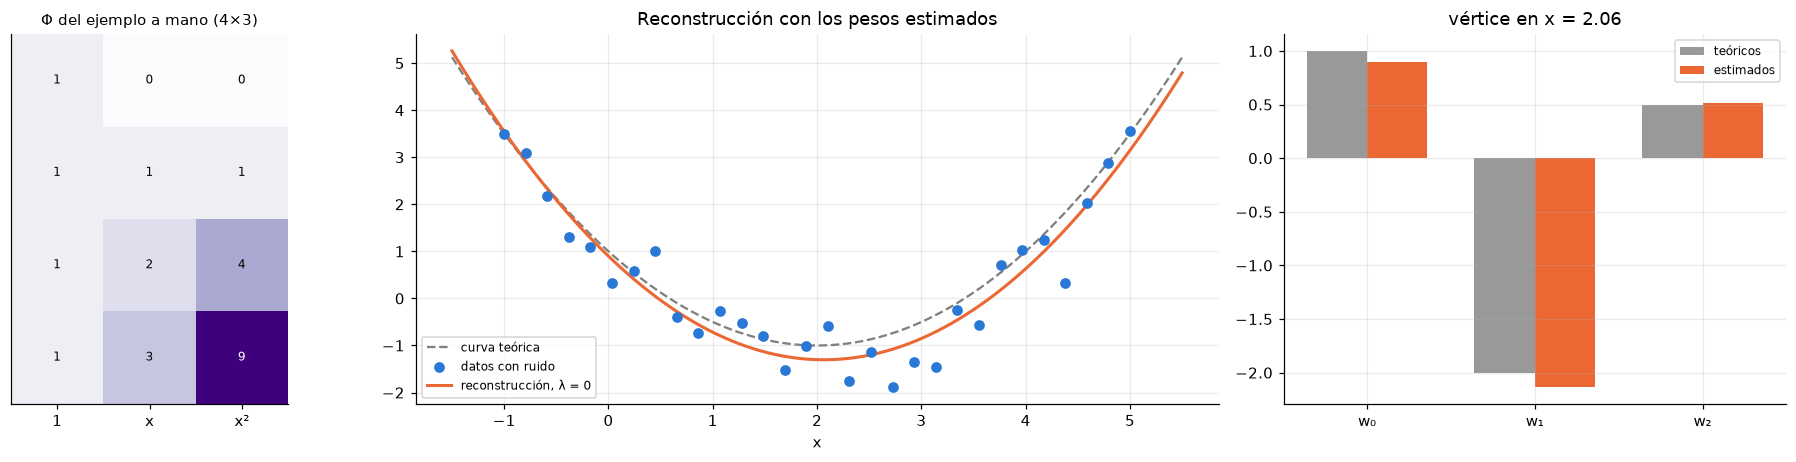

In [39]:
# Ejercicio 1.3: Mapeo polinómico: matriz de diseño y verificación en código
phi = lambda x: np.column_stack([np.ones_like(x), x, x**2])   # φ(x) = [1, x, x²]: matriz de diseño N×3
w_teo = np.array([1.0, -2.0, 0.5])                             # pesos teóricos

x4 = np.array([0., 1., 2., 3.]); F4 = phi(x4); t4 = F4 @ w_teo # ejemplo a mano, sin ruido
print("ΦᵀΦ =\n", F4.T @ F4, "\nΦᵀt =", F4.T @ t4, "\nŵ =", np.linalg.solve(F4.T @ F4, F4.T @ t4))

rng_e = np.random.default_rng(7)                               # con ruido: N = 30
x = np.linspace(-1, 5, 30); F = phi(x)
t = F @ w_teo + 0.6 * rng_e.normal(size=x.size)
estimar = lambda lam: np.linalg.solve(F.T @ F + lam * np.eye(3), F.T @ t)
z = np.linspace(-1.5, 5.5, 300)

def reconstruccion(lam=0.0):
    w = estimar(lam)
    fig, ax = plt.subplots(1, 3, figsize=(17, 4.3), gridspec_kw={"width_ratios": [0.8, 1.6, 1]})
    mapa_calor(ax[0], F4, "Φ del ejemplo a mano (4×3)", fmt="{:.0f}", cmap="Purples", centrado=False)
    ax[0].set_xticks(range(3), ["1", "x", "x²"])
    ax[1].plot(z, phi(z) @ w_teo, "--", color="0.5", label="curva teórica")
    ax[1].scatter(x, t, color=SERIE[0], zorder=3, label="datos con ruido")
    ax[1].plot(z, phi(z) @ w, color=SERIE[1], lw=2, label=f"reconstrucción, λ = {lam:g}")
    ax[1].legend(fontsize=8); ax[1].set_xlabel("x"); ax[1].set_title("Reconstrucción con los pesos estimados")
    k = np.arange(3)
    ax[2].bar(k - 0.18, w_teo, 0.36, color="0.6", label="teóricos")
    ax[2].bar(k + 0.18, w, 0.36, color=SERIE[1], label="estimados")
    ax[2].set_xticks(k, ["w₀", "w₁", "w₂"]); ax[2].legend(fontsize=8)
    ax[2].set_title(f"vértice en x = {-w[1] / (2 * w[2]):.2f}")
    plt.tight_layout(); plt.show()

interactivo(reconstruccion, lam=(0.0, 400.0, 5.0, 0.0))

**Qué observar:** Sin ruido la fórmula recupera exactamente $[1,-2,0.5]$ (se imprime arriba). Con ruido y $\lambda=0$ los pesos estimados quedan cerca de los teóricos y el vértice cerca de $x=2$; al subir $\lambda$ los pesos se encogen y la parábola se aplana.

**Prueba a cambiar:** Mueve `lam` y mira desde qué valor el vértice se aleja de $x=2$.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Dimensiones.** Con 30 datos, ¿de qué tamaño es la matriz de diseño? ¿Y $\Phi^T\Phi$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $30\times3$ y $3\times3$.
2. **Por qué.** Una fila por muestra y una columna por componente de $\varphi$: 1, $x$ y $x^2$.
3. **Con los datos.** $\Phi^T\Phi$ es $3\times3$ sin importar cuántos datos haya.

</details>

**Espacio.** La parábola ajustada, ¿es un modelo lineal o no lineal?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Las dos cosas: lineal en el espacio de características y no lineal en el original.
2. **Por qué.** $\hat t=w^T\varphi(x)$ es un plano en $\mathbb{R}^3$ que, visto contra $x$, es una parábola.
3. **Con los datos.** Es la idea de todo método kernel.

</details>

**Interpretación.** ¿Qué significa cada peso?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $w_0$ es el corte, $w_1$ la pendiente en 0 y $w_2$ la curvatura.
2. **Por qué.** Son los coeficientes del polinomio $w_0+w_1x+w_2x^2$.
3. **Con los datos.** Con $w=[1,-2,0.5]$ el vértice queda en $x=2$.

</details>

**Efecto de un cambio.** Sin ruido y con $\lambda=0$, ¿se recuperan exactamente los pesos teóricos?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Sí, si hay al menos 3 valores distintos de $x$.
2. **Por qué.** El sistema $\Phi^T\Phi w=\Phi^Tt$ tiene solución única y los datos cumplen el modelo sin error.
3. **Con los datos.** Con ruido, $\hat w$ se acerca a $w$ al aumentar $N$.

</details>

**Extremos.** ¿Qué le pasa a la curva si $\lambda$ es muy grande?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Se aplana hacia 0.
2. **Por qué.** Todos los pesos se encogen, incluido el término independiente.
3. **Con los datos.** Por eso a veces no se regulariza $w_0$.

</details>

### Ejercicio 1.4. Truco del kernel a partir de la SVD

*Visto en la sesión del 7 de octubre.*

**Enunciado.** Explique el truco del kernel a partir de una descomposición en valores singulares (SVD) de la matriz de diseño en el espacio de características. Muestre cómo la relación entre $\Phi^T\Phi$ y $\Phi\Phi^T$ permite expresar los productos internos entre las muestras transformadas mediante la matriz de Gram, sin construir explícitamente el mapeo $\varphi$.

**Resultado**

$$\Phi=USV^T$$

$$\Phi^T\Phi=V(S^TS)V^T\in\mathbb{R}^{Q\times Q}$$

$$\Phi\Phi^T=U(SS^T)U^T=\mathbb{K}\in\mathbb{R}^{N\times N}$$

**Idea de la solución:** Las dos matrices se construyen con los mismos valores singulares, así que ninguna tiene más información que la otra: comparten los valores propios distintos de cero. La de $Q\times Q$ puede ser infinita; la de $N\times N$ siempre se puede calcular, y cada una de sus entradas es un producto interno entre dos muestras transformadas, $\langle\varphi(x_i),\varphi(x_j)\rangle=K(x_i,x_j)$. Por eso se trabaja con ella y se elige un kernel en lugar de un mapeo.

**Solución paso a paso**

**Paso 1.** El problema: con $Q\to\infty$ no se puede construir $\Phi$ ni calcular $\Phi^T\Phi$.

$$\Phi=\begin{bmatrix}\varphi(x_1)^T\\\vdots\\\varphi(x_N)^T\end{bmatrix}\in\mathbb{R}^{N\times Q},\qquad\Phi^T\Phi\in\mathbb{R}^{Q\times Q},\quad Q\to\infty$$

**Paso 2.** SVD de la matriz de diseño. $U$ y $V$ tienen columnas ortonormales; $S$ tiene los valores singulares $s_1\ge\dots\ge s_r\gt 0$ en la diagonal, con $r\le\min(N,Q)$.

$$\Phi=\underbrace{U}_{N\times N}\underbrace{S}_{N\times Q}\underbrace{V^T}_{Q\times Q},\qquad U^TU=I_N,\quad V^TV=I_Q$$

**Paso 3.** Matriz $Q\times Q$: el producto $U^TU$ se cancela. A partir de la posición $N$ la diagonal solo tiene ceros.

$$\Phi^T\Phi=VS^T\underbrace{U^TU}_{I_N}SV^T=V\Lambda V^T,\qquad\Lambda=S^TS=\operatorname{diag}(s_1^2,\dots,s_N^2,0,\dots,0)$$

**Paso 4.** Matriz $N\times N$: el producto $V^TV$ se cancela.

$$\Phi\Phi^T=US\underbrace{V^TV}_{I_Q}S^TU^T=U\Delta U^T,\qquad\Delta=SS^T=\operatorname{diag}(s_1^2,\dots,s_N^2)$$

**Paso 5.** Las dos comparten los valores propios no nulos $s_i^2$, y sus vectores propios se relacionan. Lo que sobra en la $Q\times Q$ son ceros, que no aportan información.

$$\Phi^T\Phi\,v_i=s_i^2v_i,\qquad\Phi\Phi^T u_i=s_i^2u_i,\qquad v_i=\frac{1}{s_i}\Phi^Tu_i$$

**Paso 6.** Matriz de Gram: cada entrada de $\Phi\Phi^T$ es el producto interno entre dos muestras transformadas. Basta una función $K$ que lo calcule directamente.

$$\big(\Phi\Phi^T\big)_{ij}=\varphi(x_i)^T\varphi(x_j)=\langle\varphi(x_i),\varphi(x_j)\rangle=K(x_i,x_j)\;\Longrightarrow\;\mathbb{K}=\Phi\Phi^T\in\mathbb{R}^{N\times N}$$

**Paso 7.** Ejemplos: con el mapeo del ejercicio 1.3 basta multiplicar números; con el RBF, $Q\to\infty$ y la matriz sigue siendo $N\times N$. La regresión del ejercicio 1.2 solo necesita $\mathbb{K}$.

$$K(x,x')=1+xx'+x^2x'^2,\qquad K_{\text{RBF}}(x,x')=\exp\Big\{-\frac{\|x-x'\|^2}{2\sigma^2}\Big\},\qquad\hat w=\Phi^T(\mathbb{K}+\lambda I)^{-1}t$$

**Ojo con el orden.** Con $\Phi$ de filas $\varphi(x_n)^T$, la matriz de productos internos entre muestras es $\Phi\Phi^T$ ($N\times N$). $\Phi^T\Phi$ ($Q\times Q$) no contiene productos internos entre muestras, sino relaciones entre características. Por eso no basta con invertir el orden de los factores: la SVD justifica el cambio, porque muestra que las dos tienen los mismos valores propios no nulos.

**Qué muestra la gráfica:** Los valores propios de $\Phi^T\Phi$ ($3\times3$) y de $\Phi\Phi^T$ ($6\times6$) junto a los $s_i^2$ de la SVD, y la matriz de Gram calculada con $\varphi$ y con el kernel.

s² de la SVD: [37.4104 10.2723  2.6299]    ¿ΦΦᵀ = K? True    ¿ΦᵀΦ v = s² v? True


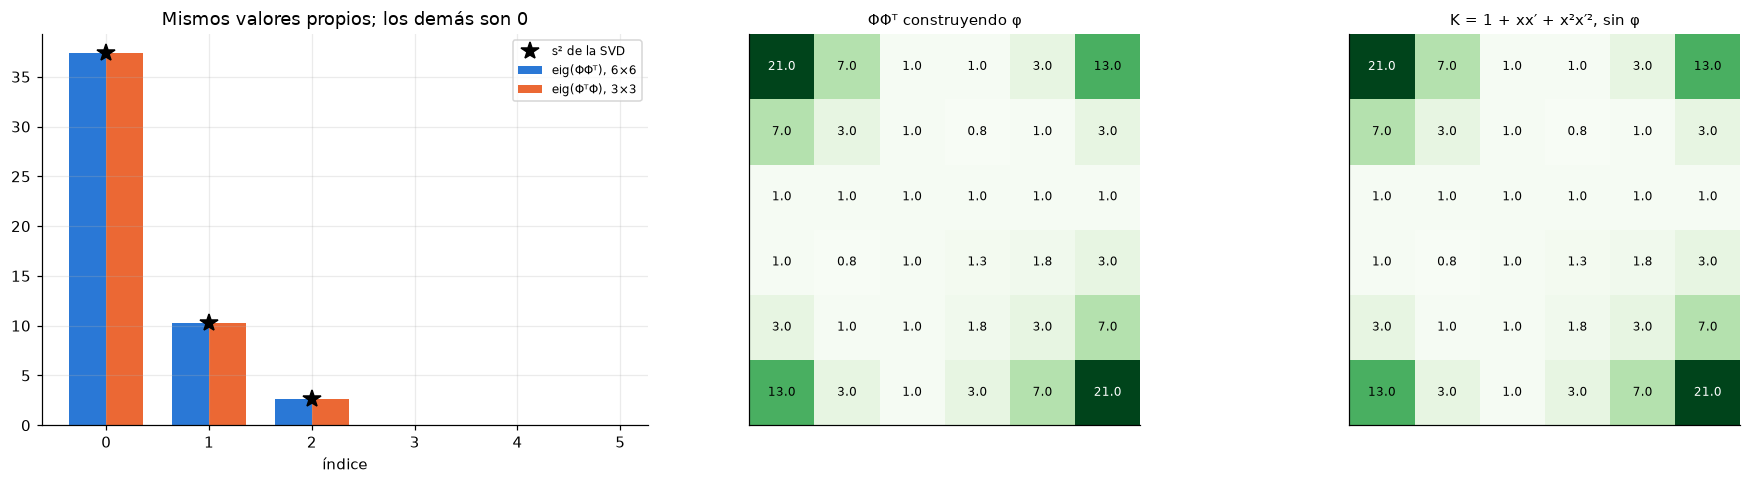

In [40]:
# Ejercicio 1.4: Truco del kernel a partir de la SVD
x = np.array([-2, -1, 0, 0.5, 1, 2])
Phi = np.column_stack([np.ones_like(x), x, x**2])              # Φ: N×Q = 6×3 (mapeo del ejercicio 1.3)
U, S, Vt = np.linalg.svd(Phi)                                  # U: 6×6, S: 3 valores singulares, Vᵀ: 3×3
ev_Q = np.sort(np.linalg.eigvalsh(Phi.T @ Phi))[::-1]          # ΦᵀΦ: 3×3
ev_N = np.sort(np.linalg.eigvalsh(Phi @ Phi.T))[::-1]          # ΦΦᵀ: 6×6
K = 1 + np.outer(x, x) + np.outer(x**2, x**2)                  # K(x, x′) = 1 + xx′ + x²x′², sin construir φ
v1 = Phi.T @ U[:, 0] / S[0]                                    # vector propio de ΦᵀΦ a partir del de ΦΦᵀ
print("s² de la SVD:", np.round(S**2, 4), "   ¿ΦΦᵀ = K?", np.allclose(Phi @ Phi.T, K),
      "   ¿ΦᵀΦ v = s² v?", np.allclose(Phi.T @ Phi @ v1, S[0]**2 * v1))

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ax[0].bar(np.arange(6) - 0.18, np.clip(ev_N, 0, None), 0.36, color=SERIE[0], label="eig(ΦΦᵀ), 6×6")
ax[0].bar(np.arange(3) + 0.18, ev_Q, 0.36, color=SERIE[1], label="eig(ΦᵀΦ), 3×3")
ax[0].plot(range(3), S**2, "k*", ms=12, label="s² de la SVD")
ax[0].set_xlabel("índice"); ax[0].legend(fontsize=8); ax[0].set_title("Mismos valores propios; los demás son 0")
mapa_calor(ax[1], Phi @ Phi.T, "ΦΦᵀ construyendo φ", fmt="{:.1f}", cmap="Greens", centrado=False)
mapa_calor(ax[2], K, "K = 1 + xx′ + x²x′², sin φ", fmt="{:.1f}", cmap="Greens", centrado=False)
plt.tight_layout(); plt.show()

**Qué observar:** Los tres valores no nulos coinciden en las dos matrices y en la SVD; los otros tres de la matriz grande son 0, no aportan información. Los dos mapas de calor son idénticos: el kernel da los productos internos sin construir $\varphi$.

**Prueba a cambiar:** Agrega puntos a `x` y cuenta cuántos valores propios quedan en 0: siempre $N-3$.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Dimensiones.** ¿De qué tamaño son $U$, $S$, $V$, $\Phi^T\Phi$ y $\Phi\Phi^T$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $N\times N$, $N\times Q$, $Q\times Q$, $Q\times Q$ y $N\times N$.
2. **Por qué.** Salen de $\Phi\in\mathbb{R}^{N\times Q}$.
3. **Con los datos.** Con $Q\to\infty$ solo la $N\times N$ se puede calcular.

</details>

**Justificación.** ¿Por qué $\Phi^T\Phi$ y $\Phi\Phi^T$ tienen la misma información?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque comparten los valores propios distintos de cero, $s_i^2$.
2. **Por qué.** Las dos se arman con la misma $S$: $S^TS$ y $SS^T$.
3. **Con los datos.** Lo que le sobra a la $Q\times Q$ son ceros, que no aportan nada.

</details>

**Interpretación.** ¿Qué es la matriz de Gram?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** La matriz de todos los productos internos entre las muestras transformadas.
2. **Por qué.** $\mathbb{K}_{ij}=\langle\varphi(x_i),\varphi(x_j)\rangle=K(x_i,x_j)$.
3. **Con los datos.** Mide cuánto se parecen dos muestras en el espacio de características.

</details>

**Espacio.** ¿Para qué llevar los datos a un espacio de dimensión infinita?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Para tener una representación más rica.
2. **Por qué.** Relaciones complejas (imágenes, lenguaje, señales) se vuelven lineales en ese espacio, y el truco del kernel evita pagar el costo de la dimensión.
3. **Con los datos.** Dos círculos que una recta no separa se separan con un plano en el espacio de características (demostración 22).

</details>

**Justificación.** ¿Se puede cambiar $\Phi^T\Phi$ por $\Phi\Phi^T$ solo invirtiendo el orden?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** No sin justificarlo: son matrices distintas.
2. **Por qué.** La SVD muestra que comparten los valores propios no nulos y que sus vectores propios se relacionan con $v_i=\Phi^Tu_i/s_i$.
3. **Con los datos.** Por eso es válido trabajar con la $N\times N$.

</details>

## 2. Espacios RKHS, embeddings de media y discrepancia entre distribuciones

### Ejercicio 2.1. Embedding de media empírico con kernel lineal y RBF

*Visto en la sesión del 7 de octubre.*

**Enunciado.** Sea $k:\chi\times\chi\to\mathbb{R}$ un kernel simétrico definido positivo y $\mathcal H_k$ su RKHS. A partir de una muestra $\{x_n\}_{n=1}^{N}$, obtenga la forma empírica del embedding de media y muestre cómo se evalúa con i) el kernel lineal $k(x_i,x_j)=x_i^Tx_j$ y ii) un kernel gaussiano RBF. Indique las dimensiones de los objetos y compare la interpretación de ambos kernels.

**Resultado**

$$\mu_P=\mathbb{E}\{k(X,\cdot)\}\;\approx\;\hat\mu_P=\frac1N\sum_{n=1}^{N}k(x_n,\cdot)$$

$$\hat\mu_P(z)=\frac1N\sum_{n=1}^{N}k(x_n,z)$$

**Idea de la solución:** En el RKHS cada dato se representa como una función, $\varphi(x)=k(x,\cdot)$: su parecido con cualquier punto del espacio. El embedding de media es el promedio de esas funciones. Evaluarlo en un punto $z$ da el parecido promedio de $z$ con los datos, y por la propiedad reproductora eso es solo un promedio de kernels.

**Solución paso a paso**

**Paso 1.** Mapeo del RKHS: el punto $(\cdot)$ representa cualquier punto del espacio. La propiedad reproductora convierte los productos internos en evaluaciones del kernel.

$$\varphi(x)=k(x,\cdot)\in\mathcal H_k,\qquad\langle k(x,\cdot),k(y,\cdot)\rangle_{\mathcal H}=k(x,y),\qquad\langle f,k(z,\cdot)\rangle_{\mathcal H}=f(z)$$

**Paso 2.** Embedding de media y su versión empírica con datos i.i.d. (el Caso 1 de la media, demostración 25):

$$\mu_P=\mathbb{E}_{X\sim P}\{k(X,\cdot)\}\;\approx\;\hat\mu_P=\frac1N\sum_{n=1}^{N}k(x_n,\cdot)$$

**Paso 3.** Evaluación en un punto, y en $M$ puntos a la vez $Z\in\mathbb{R}^{M\times P}$ con la matriz kernel cruzada:

$$\hat\mu_P(z)=\langle\hat\mu_P,k(z,\cdot)\rangle=\frac1N\sum_{n=1}^{N}k(x_n,z),\qquad\hat\mu_P(Z)=\frac1N\underbrace{\mathbb{K}_{ZX}}_{M\times N}\mathbf{1}_N\in\mathbb{R}^{M\times1}$$

**Paso 4.** i) Kernel lineal: el mapeo es la identidad, $\varphi(x)=x$ ($Q=P$), y el embedding es el vector de medias del espacio original.

$$\hat\mu_P(z)=\frac1N\sum_{n=1}^{N}x_n^Tz=\Big(\frac1N\sum_{n=1}^{N}x_n\Big)^Tz=\bar x^Tz,\qquad\bar x=\frac1N\mathbb{X}^T\mathbf{1}_N\in\mathbb{R}^{P\times1}$$

**Paso 5.** ii) Kernel RBF: el embedding es una función ($Q\to\infty$) que nunca se construye, solo se evalúa. Es un histograma suavizado de los datos; con la constante $(2\pi\sigma^2)^{-P/2}$ es exactamente el estimador de densidad de Parzen.

$$\hat\mu_P(z)=\frac1N\sum_{n=1}^{N}\exp\Big\{-\frac{\|x_n-z\|_2^2}{2\sigma^2}\Big\},\qquad0\lt \hat\mu_P(z)\le1$$

**Paso 6.** El ancho de banda $\sigma$ es la sensibilidad del kernel. Si es muy grande todo se parece; si es muy pequeño nada se parece, salvo cada dato consigo mismo.

$$\sigma\to\infty:\ \hat\mu_P(z)\to1\qquad\sigma\to0:\ \hat\mu_P(z)\to\frac{\#\{n:\,x_n=z\}}{N}\ \ (0\text{ fuera de los datos})$$

**Paso 7.** Comparación: el lineal solo ve la media, así que dos distribuciones con la misma media tienen el mismo embedding. El RBF ve la distribución completa, porque su mapeo contiene todas las potencias de $x$ (ejercicio 2.2).

$$\text{lineal: }\hat\mu_P\leftrightarrow\bar x\qquad\text{RBF: }\hat\mu_P\leftrightarrow\text{toda la distribución }P$$

**Ojo con tus apuntes.** En los apuntes aparece $\frac{1}{\sqrt{2\pi\sigma}}\exp\big(\frac{\|x_n-z\|^2}{2\sigma^2}\big)$: faltan el signo menos del exponente y el cuadrado de la constante, que en una dimensión es $\frac{1}{\sqrt{2\pi\sigma^2}}$. Con esa constante, el análisis de los extremos cambia: si $\sigma\to\infty$ la exponencial tiende a 1, pero la constante tiende a 0. La conclusión «todo se parece» se refiere a la exponencial, que es el kernel con $k(x,x)=1$.

**Qué muestra la gráfica:** El embedding de media de dos muestras con la misma media: con el kernel lineal son dos rectas y con el kernel RBF dos curvas. Las marcas de abajo son las muestras.

tamaños: K(Z, X) es (400, 100)  → μ̂(Z) es (400, 1)


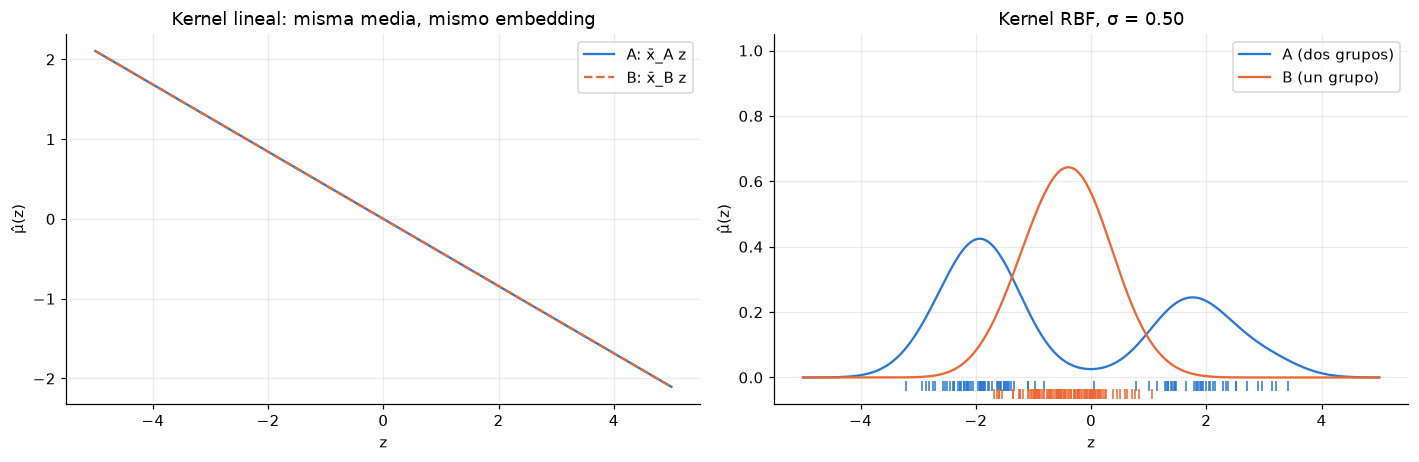

In [41]:
# Ejercicio 2.1: Embedding de media empírico con kernel lineal y RBF
rng_e = np.random.default_rng(2)
A = np.concatenate([rng_e.normal(-2, 0.5, 60), rng_e.normal(2, 0.8, 40)])   # muestra A: dos grupos
B = rng_e.normal(0, 0.6, 100); B = B - B.mean() + A.mean()                  # muestra B: un grupo, la misma media
z = np.linspace(-5, 5, 400)

def embedding(X, Z, s):                       # μ̂(Z) = (1/N) K(Z, X) 1_N, con K(Z, X) de tamaño M×N
    return np.exp(-(Z[:, None] - X[None, :])**2 / (2 * s**2)).mean(axis=1)

def comparar(sigma=0.5):
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
    ax[0].plot(z, A.mean() * z, color=SERIE[0], label="A: x̄_A z")
    ax[0].plot(z, B.mean() * z, "--", color=SERIE[1], label="B: x̄_B z")
    ax[0].legend(); ax[0].set_title("Kernel lineal: misma media, mismo embedding")
    ax[1].plot(z, embedding(A, z, sigma), color=SERIE[0], label="A (dos grupos)")
    ax[1].plot(z, embedding(B, z, sigma), color=SERIE[1], label="B (un grupo)")
    ax[1].plot(A, np.full_like(A, -0.025), "|", color=SERIE[0]); ax[1].plot(B, np.full_like(B, -0.05), "|", color=SERIE[1])
    ax[1].set_ylim(-0.08, 1.05); ax[1].legend(); ax[1].set_title(f"Kernel RBF, σ = {sigma:.2f}")
    for a in ax:
        a.set_xlabel("z"); a.set_ylabel("μ̂(z)")
    plt.tight_layout(); plt.show()

print("tamaños: K(Z, X) es", (z.size, A.size), " → μ̂(Z) es", (z.size, 1))
interactivo(comparar, sigma=(0.02, 30.0, 0.02, 0.5))

**Qué observar:** Con el kernel lineal las dos rectas coinciden: solo ven la media. Con el RBF, A muestra dos montañas y B una sola. En los extremos de $\sigma$ los dos embeddings vuelven a parecerse: todo vale 1 o casi todo vale 0.

**Prueba a cambiar:** Mueve `sigma` de 0.02 a 30 y busca el rango en que las dos curvas se distinguen mejor.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Dimensiones.** Con el kernel lineal, ¿de qué tamaño es el embedding de media?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $P\times1$: es el vector de medias $\bar x$.
2. **Por qué.** $\varphi(x)=x$, así que $Q=P$ y $\frac1N\sum_n x_n$ vive en el espacio original.
3. **Con los datos.** Con MNIST sería la imagen promedio de 784 píxeles.

</details>

**Dimensiones.** Con el RBF, ¿de qué tamaño es el embedding? ¿Y su evaluación en $M$ puntos?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Es una función, de dimensión infinita; su evaluación es un vector $M\times1$.
2. **Por qué.** $\hat\mu_P(Z)=\frac1N\mathbb{K}_{ZX}\mathbf{1}_N$ con $\mathbb{K}_{ZX}\in\mathbb{R}^{M\times N}$.
3. **Con los datos.** Nunca se construye $\mu_P$: solo se evalúa.

</details>

**Extremos.** ¿Qué pasa con $\hat\mu_P(z)$ si $\sigma$ es muy grande? ¿Y si es muy pequeño?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Tiende a 1 en todas partes, o a 0 salvo sobre los datos.
2. **Por qué.** Con $\sigma$ grande las distancias se vuelven despreciables y todo se parece; con $\sigma$ pequeño solo $z=x_n$ da 1 y nada se parece.
3. **Con los datos.** $\sigma$ es el ancho de banda: la sensibilidad del kernel.

</details>

**Interpretación.** ¿Qué significa que $\hat\mu_P(z)$ sea alto?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Que $z$ se parece, en promedio, a los datos.
2. **Por qué.** Es el promedio de las similitudes $k(x_n,z)$.
3. **Con los datos.** Con el RBF es alto donde hay muchos datos, como un histograma suavizado.

</details>

**Justificación.** ¿Por qué el kernel lineal no distingue dos distribuciones con la misma media?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque su embedding es solo la media.
2. **Por qué.** $\hat\mu_P(z)=\bar x^Tz$ depende únicamente de $\bar x$.
3. **Con los datos.** Una distribución con dos grupos y una campana centrada en su media tienen el mismo embedding lineal.

</details>

**Espacio.** ¿Qué es $k(x,\cdot)$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** La representación de $x$ en el RKHS: una función.
2. **Por qué.** Dice cuánto se parece $x$ a cada punto del espacio; por la propiedad reproductora $\langle k(x,\cdot),k(y,\cdot)\rangle=k(x,y)$.
3. **Con los datos.** El punto $(\cdot)$ es cualquier punto del espacio.

</details>

### Ejercicio 2.2. Momentos brutos, centrados y estandarizados

*No se alcanzó a ver en la sesión; la solución se arma con demostraciones del mapa.*

**Enunciado.** Explique la diferencia entre momento bruto, momento centrado y momento estandarizado, tanto en el espacio original como en el espacio inducido por el kernel.

**Resultado**

$$\underbrace{\mathbb{E}\{x^k\}}_{\text{bruto}}$$

$$\underbrace{\mathbb{E}\{(x-\mu)^k\}}_{\text{centrado}}$$

$$\underbrace{\mathbb{E}\Big\{\Big(\frac{x-\mu}{\sigma}\Big)^k\Big\}}_{\text{estandarizado}}$$

**Idea de la solución:** Los tres miden la misma potencia desde referencias distintas. El bruto se mide desde el origen; el centrado, desde la media, y así quita la posición; el estandarizado además divide entre la desviación, y así quita la escala. En el espacio del kernel pasa lo mismo con matrices: $\frac1N\mathbb{K}$ es el momento bruto de segundo orden, $\frac1NH\mathbb{K}H$ el centrado y la correlación en el RKHS el estandarizado.

**Solución paso a paso**

**Paso 1.** Espacio original, variable escalar. Definiciones de orden $k$, con $\mu=\mathbb{E}\{x\}$ y $\sigma^2=\operatorname{Var}(x)$:

$$m_k=\mathbb{E}\{x^k\},\qquad\mu_k=\mathbb{E}\{(x-\mu)^k\},\qquad\tilde\mu_k=\frac{\mu_k}{\sigma^k}=\mathbb{E}\Big\{\Big(\frac{x-\mu}{\sigma}\Big)^k\Big\}$$

**Paso 2.** Primeros órdenes. El primer momento centrado siempre vale 0 y el segundo estandarizado siempre vale 1, así que la forma se describe con los órdenes 3 (asimetría) y 4 (curtosis).

$$\begin{array}{c|ccc}k&\text{bruto}&\text{centrado}&\text{estandarizado}\\\hline1&\mu&0&0\\2&\mathbb{E}\{x^2\}&\sigma^2&1\\3&\mathbb{E}\{x^3\}&\mu_3&\text{asimetría}\\4&\mathbb{E}\{x^4\}&\mu_4&\text{curtosis}\end{array}$$

**Paso 3.** Los centrados se obtienen de los brutos (demostración 8):

$$\mu_2=m_2-m_1^2=\mathbb{E}\{x^2\}-\mu^2$$

**Paso 4.** Con vectores ($\mathbb{X}\in\mathbb{R}^{N\times P}$, filas = muestras) el segundo orden se vuelve matriz: bruto, covarianza (centrado, demostración 26) y correlación (estandarizado, demostraciones 10 y 31).

$$\underbrace{\tfrac1N\mathbb{X}^T\mathbb{X}}_{\text{bruto}}\qquad\underbrace{\tfrac1N\mathbb{X}_c^T\mathbb{X}_c=\tfrac1N\mathbb{X}^T\mathbb{X}-\mu^T\mu}_{\text{centrado: }\Sigma}\qquad\underbrace{\rho_{ij}=\frac{\Sigma_{ij}}{\sigma_i\sigma_j}}_{\text{estandarizado}}$$

**Paso 5.** Espacio del kernel, primer orden: el momento bruto es el embedding de media (ejercicio 2.1). Segundo orden bruto: productos internos sin quitar la media.

$$\mu_{\mathcal H}=\mathbb{E}\{\varphi(x)\},\qquad\Big(\tfrac1N\mathbb{K}\Big)_{ij}=\tfrac1N\langle\varphi(x_i),\varphi(x_j)\rangle$$

**Paso 6.** Centrado: se resta $\mu_{\mathcal H}$ a cada muestra, que en forma matricial es multiplicar por $H$ a los dos lados (demostración 29). Su traza entre $N$ es la varianza total (demostración 24).

$$\big(H\mathbb{K}H\big)_{ij}=\langle\varphi(x_i)-\mu_{\mathcal H},\,\varphi(x_j)-\mu_{\mathcal H}\rangle,\qquad H=I-\tfrac1N\mathbf{1}\mathbf{1}^T$$

**Paso 7.** Estandarizado: dividir entre la raíz de la diagonal, que es la dispersión de cada muestra en el RKHS. Queda entre −1 y 1, con diagonal 1 (demostración 33).

$$\rho_{\mathcal H}(i,j)=\frac{(H\mathbb{K}H)_{ij}}{\sqrt{(H\mathbb{K}H)_{ii}\,(H\mathbb{K}H)_{jj}}}\in[-1,1]$$

**Paso 8.** Conexión entre los dos espacios: con el mapeo del ejercicio 1.3, el embedding de media es exactamente el vector de momentos brutos de orden 0, 1 y 2. El RBF contiene todas las potencias de $x$ (serie de Taylor), así que su embedding guarda información de momentos de todos los órdenes.

$$\hat\mu_{\mathcal H}=\frac1N\sum_{n=1}^{N}\begin{bmatrix}1\\x_n\\x_n^2\end{bmatrix}=\begin{bmatrix}1\\m_1\\m_2\end{bmatrix},\qquad e^{xz/\sigma^2}=\sum_{k=0}^{\infty}\frac{(xz)^k}{\sigma^{2k}\,k!}$$

**Qué muestra la gráfica:** La distribución asimétrica, cuánto cambia cada tipo de momento al pasar a $y=10x+3$ y la tabla de momentos. Abajo, en el espacio del kernel, las tres matrices: bruta, centrada y estandarizada.

embedding con φ = [1, x, x²]: [1.     1.1367 1.6367] = [1, m₁, m₂]


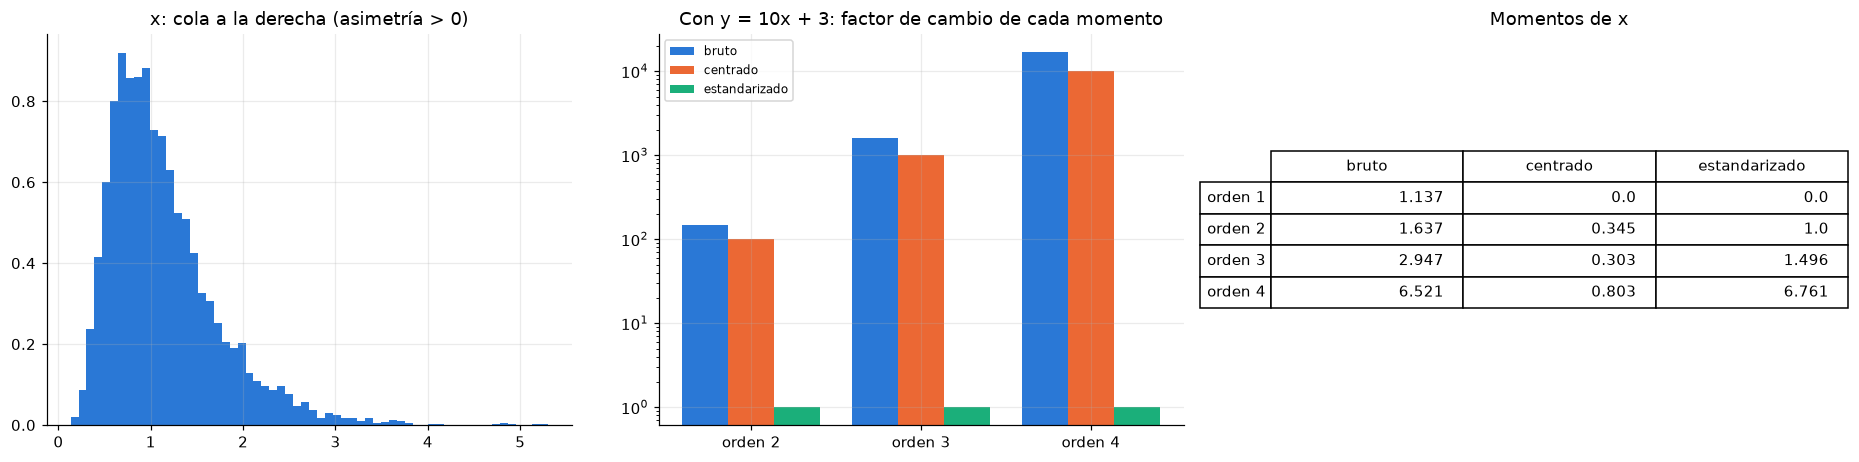

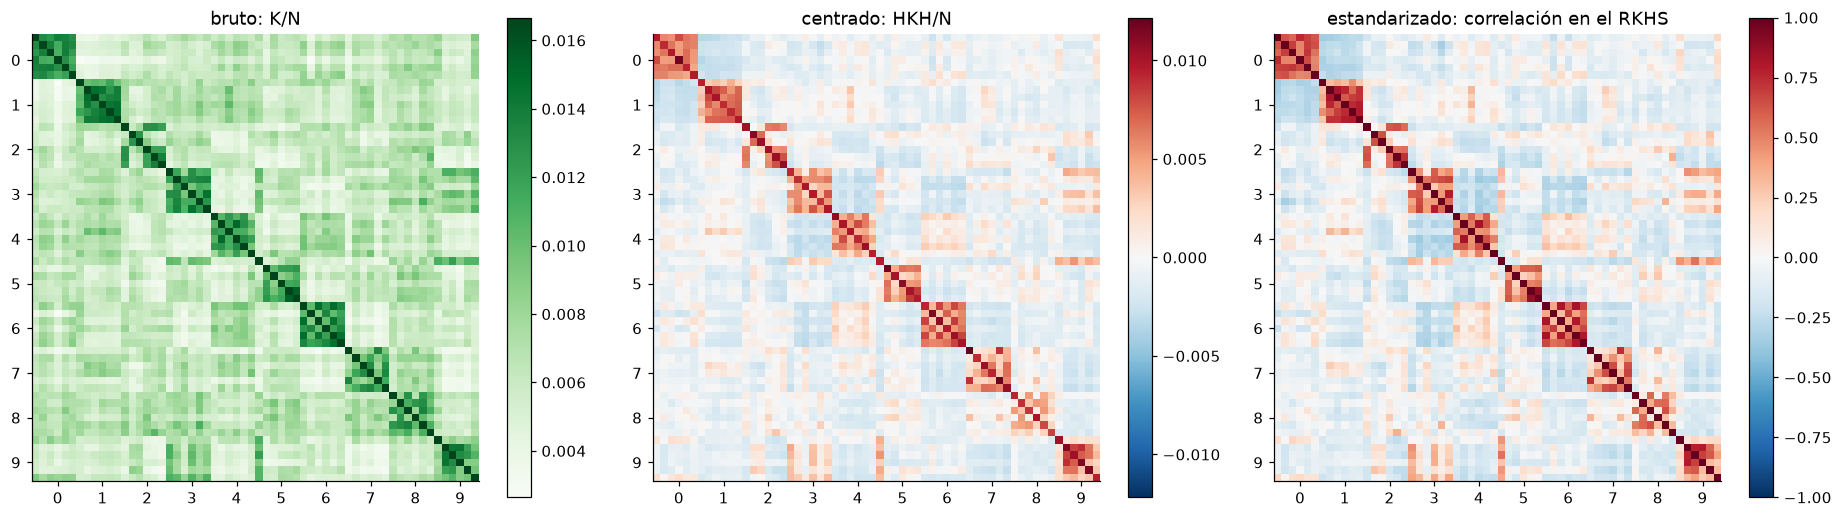

In [42]:
# Ejercicio 2.2: Momentos brutos, centrados y estandarizados
rng_e = np.random.default_rng(4)
x = np.exp(0.5 * rng_e.normal(size=5000))                      # datos con asimetría a la derecha

def momentos(v):                                               # filas: orden 1 a 4; columnas: bruto, centrado, estandarizado
    m, s = v.mean(), v.std()
    return np.array([[np.mean(v**k), np.mean((v - m)**k), np.mean(((v - m) / s)**k)] for k in (1, 2, 3, 4)])

M1, M2 = momentos(x), momentos(10 * x + 3)                     # mismos datos con otra posición y otra escala
print("embedding con φ = [1, x, x²]:", np.round([1, x.mean(), np.mean(x**2)], 4), "= [1, m₁, m₂]")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.3), gridspec_kw={"width_ratios": [1, 1, 1.1]})
ax[0].hist(x, bins=60, density=True, color=SERIE[0]); ax[0].set_title("x: cola a la derecha (asimetría > 0)")
k = np.arange(2, 5)
for j, nombre in enumerate(["bruto", "centrado", "estandarizado"]):
    ax[1].bar(k + (j - 1) * 0.27, np.abs(M2[1:, j] / M1[1:, j]), 0.27, color=SERIE[j], label=nombre)
ax[1].set_yscale("log"); ax[1].set_xticks(k, [f"orden {i}" for i in k]); ax[1].legend(fontsize=8)
ax[1].set_title("Con y = 10x + 3: factor de cambio de cada momento")
ax[2].axis("off")
tabla = ax[2].table(cellText=np.round(M1, 3), rowLabels=[f"orden {i}" for i in (1, 2, 3, 4)],
                    colLabels=["bruto", "centrado", "estandarizado"], loc="center")
tabla.scale(1, 1.6); ax[2].set_title("Momentos de x")
plt.tight_layout(); plt.show()

d = load_digits()                                              # espacio del kernel: 6 imágenes por clase
Xd = np.vstack([d.data[d.target == c][:6] for c in range(10)]) / 16
n = len(Xd); Dd = ((Xd[:, None] - Xd[None])**2).sum(-1)
K = np.exp(-Dd / np.median(Dd[Dd > 0]))                        # 2σ² = mediana
H = np.eye(n) - np.ones((n, n)) / n
Kc = H @ K @ H
R = Kc / np.sqrt(np.outer(np.diag(Kc), np.diag(Kc)))
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
lim = np.abs(Kc / n).max()
for a, M, t, cm, lo, hi in [(ax[0], K / n, "bruto: K/N", "Greens", None, None),
                            (ax[1], Kc / n, "centrado: HKH/N", "RdBu_r", -lim, lim),
                            (ax[2], R, "estandarizado: correlación en el RKHS", "RdBu_r", -1, 1)]:
    im = a.imshow(M, cmap=cm, vmin=lo, vmax=hi); a.set_title(t); fig.colorbar(im, ax=a); a.grid(False)
    a.set_xticks(range(3, 60, 6), range(10)); a.set_yticks(range(3, 60, 6), range(10))
plt.tight_layout(); plt.show()

**Qué observar:** El momento estandarizado no cambia (factor 1), el centrado se multiplica por $10^k$ y el bruto cambia de forma irregular porque también lo afecta el $+3$. En las matrices, solo la correlación en el RKHS vuelve a tener diagonal 1.

**Prueba a cambiar:** Cambia los datos por una gaussiana, `x = rng_e.normal(size=5000)`: la asimetría pasa a ser casi 0 y la curtosis casi 3.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Interpretación.** ¿Qué diferencia hay entre momento bruto, centrado y estandarizado?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** La referencia: el origen; la media; o la media y la escala.
2. **Por qué.** Centrar quita la posición; estandarizar además quita la escala y deja un número sin unidades.
3. **Con los datos.** Sumar 10 a todos los datos cambia el bruto, pero no el centrado ni el estandarizado.

</details>

**Extremos.** ¿Cuánto valen siempre el primer momento centrado y el segundo estandarizado?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** 0 y 1.
2. **Por qué.** $\mathbb{E}\{x-\mu\}=0$ y $\mathbb{E}\{(x-\mu)^2\}/\sigma^2=1$.
3. **Con los datos.** Por eso la forma se describe con los órdenes 3 (asimetría) y 4 (curtosis).

</details>

**Espacio.** En el espacio del kernel, ¿qué matriz es el momento bruto, cuál el centrado y cuál el estandarizado?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $\frac1N\mathbb{K}$, $\frac1NH\mathbb{K}H$ y la correlación en el RKHS.
2. **Por qué.** Centrar es multiplicar por $H$ a ambos lados; estandarizar es dividir entre la raíz de la diagonal.
3. **Con los datos.** Con el RBF, la diagonal de $\mathbb{K}$ vale 1 (la de $\frac1N\mathbb{K}$, $\frac1N$); la de $H\mathbb{K}H$ es la dispersión de cada muestra, $\|\varphi(x_i)-\mu_{\mathcal H}\|^2$; y la de la correlación vuelve a valer 1.

</details>

**Justificación.** ¿Por qué el embedding con el RBF guarda información de todos los momentos?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque su mapeo contiene todas las potencias de $x$.
2. **Por qué.** La serie de Taylor de la exponencial suma potencias de todos los órdenes, y al promediarlas aparecen momentos de todos los órdenes.
3. **Con los datos.** Con $\varphi(x)=[1,x,x^2]$ el embedding es $[1,m_1,m_2]$: solo hasta orden 2.

</details>

**Efecto de un cambio.** Si se multiplican los datos por 10, ¿cuáles momentos cambian?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** El bruto y el centrado sí; el estandarizado no.
2. **Por qué.** El de orden $k$ se multiplica por $10^k$, y al dividir entre $\sigma^k$ se cancela.
3. **Con los datos.** Por eso la correlación no depende de las unidades.

</details>

### Ejercicio 2.3. Discrepancia entre clases de MNIST con el MMD

*Visto en la sesión del 7 de octubre.*

**Enunciado.** Sean $X\sim P$ y $Y\sim Q$ con embeddings $\mu_P=\mathbb{E}\{k(X,\cdot)\}$ y $\mu_Q=\mathbb{E}\{k(Y,\cdot)\}$. Formule la discrepancia $\|\mu_P-\mu_Q\|^2_{\mathcal H_k}$, deduzca su forma matricial empírica e impleméntela con $X$ de una clase de MNIST y $Y$ de otra. Indique qué pares de clases tienen menor y mayor discrepancia y explique qué significa.

**Resultado**

$$\widehat{\operatorname{MMD}}^2=\frac{1}{N^2}\mathbf{1}_N^T\mathbb{K}_{XX}\mathbf{1}_N-\frac{2}{NM}\mathbf{1}_N^T\mathbb{K}_{XY}\mathbf{1}_M+\frac{1}{M^2}\mathbf{1}_M^T\mathbb{K}_{YY}\mathbf{1}_M$$

**Idea de la solución:** Es la distancia entre las medias de las dos clases, pero medida en el RKHS. Cada clase queda resumida en un punto $\mu$ de ese espacio y el MMD dice qué tan lejos están. Es diferente de comparar imagen con imagen (la matriz $100\times100$ de la demostración 33): aquí se compara clase con clase, con una entrada por pareja de clases.

**Solución paso a paso**

**Paso 1.** Expandir la norma al cuadrado (demostración 5):

$$\|\mu_P-\mu_Q\|_{\mathcal H}^2=\langle\mu_P,\mu_P\rangle-2\langle\mu_P,\mu_Q\rangle+\langle\mu_Q,\mu_Q\rangle$$

**Paso 2.** Propiedad reproductora con valores esperados: cada producto interno entre embeddings es un kernel promedio.

$$\langle\mu_P,\mu_Q\rangle_{\mathcal H}=\mathbb{E}_{X,Y}\{k(X,Y)\}\;\Longrightarrow\;\operatorname{MMD}^2=\mathbb{E}\{k(X,X')\}-2\,\mathbb{E}\{k(X,Y)\}+\mathbb{E}\{k(Y,Y')\}$$

**Paso 3.** Versión empírica con $\{x_n\}_{n=1}^{N}$ y $\{y_m\}_{m=1}^{M}$: cada valor esperado se cambia por un promedio (demostración 30).

$$\widehat{\operatorname{MMD}}^2=\frac{1}{N^2}\sum_{n,n'}k(x_n,x_{n'})-\frac{2}{NM}\sum_{n,m}k(x_n,y_m)+\frac{1}{M^2}\sum_{m,m'}k(y_m,y_{m'})$$

**Paso 4.** Forma matricial: la suma de todas las entradas de una matriz es $\mathbf{1}^T\mathbb{K}\mathbf{1}$. Las matrices se calculan sin bucles con las distancias del ejercicio 3.1.

$$\mathbb{K}_{XX}\in\mathbb{R}^{N\times N},\quad\mathbb{K}_{XY}\in\mathbb{R}^{N\times M},\quad\mathbb{K}_{YY}\in\mathbb{R}^{M\times M},\qquad\sum_{n,m}k(x_n,y_m)=\mathbf{1}_N^T\mathbb{K}_{XY}\mathbf{1}_M$$

**Paso 5.** Con las 10 clases se arma una matriz $10\times10$ de discrepancias. Es simétrica y su diagonal es 0, porque compara cada clase consigo misma.

$$\mathbf{M}_{ab}=\widehat{\operatorname{MMD}}^2(\text{clase }a,\ \text{clase }b),\qquad\mathbf{M}_{ab}=\mathbf{M}_{ba},\qquad\mathbf{M}_{aa}=0$$

**Paso 6.** Lectura: un valor pequeño significa que las dos clases se parecen en promedio, porque su similitud cruzada es casi igual a la interna; un valor grande, que se distinguen con facilidad. Con MNIST y 100 imágenes por clase (como corre en Colab), las parejas más parecidas son 3 y 5, 4 y 9, y 7 y 9; las más distintas, 0 y 1, 1 y 6, y 1 y 4. Con los 40 dígitos de $8\times8$ por clase del mapa HTML salen 2 y 8, 3 y 9, y 8 y 9, y 3 y 6, 0 y 1, y 3 y 4: el orden depende de los datos.

$$\mathbf{M}_{ab}\approx0\iff\bar K_{ab}\approx\tfrac12\big(\bar K_{aa}+\bar K_{bb}\big)$$

**Lo que se vio en clase.** En clase se mostró la matriz de clases contra clases: la diagonal compara cada número consigo mismo (distancia 0) y el 7 con el 9 salió con una discrepancia baja, porque se parecen a simple vista. El orden exacto de las parejas depende de $\sigma$, de la resolución de las imágenes y de cuáles se toman: conviene usar la heurística de la mediana y muchas imágenes por clase. Con dos muestras distintas de la misma clase la diagonal daría casi 0, no exactamente 0.

**Qué muestra la gráfica:** La matriz $10\times10$ de discrepancias MMD² entre clases con kernel RBF, la misma con kernel lineal y la imagen promedio de cada clase.

menor discrepancia: 3 y 5, 4 y 9, 7 y 9    mayor: 0 y 1, 1 y 6, 1 y 4


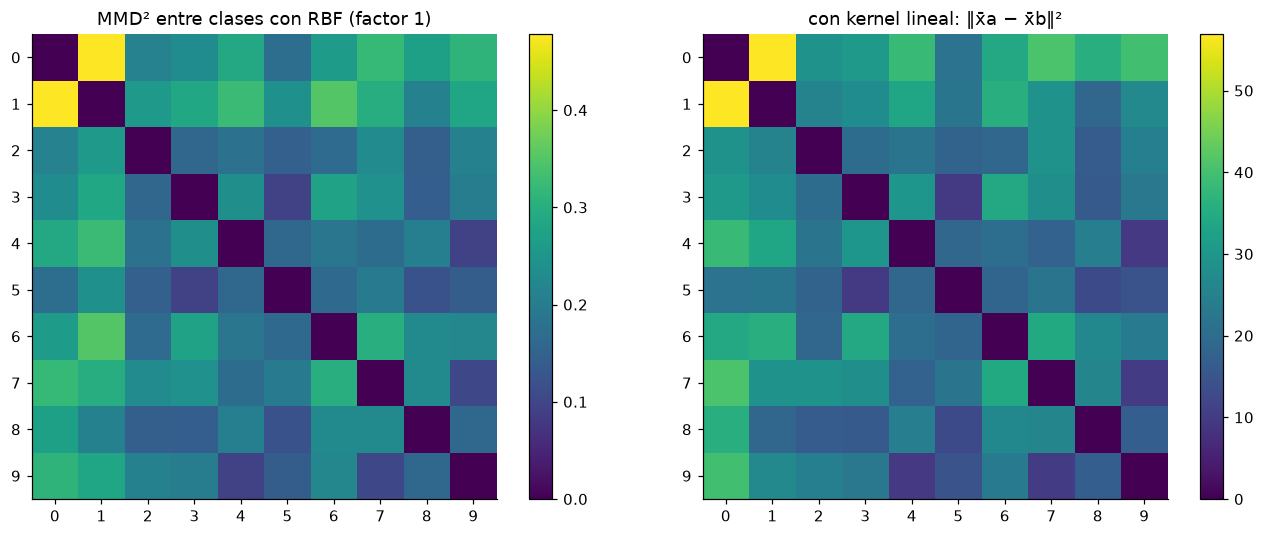

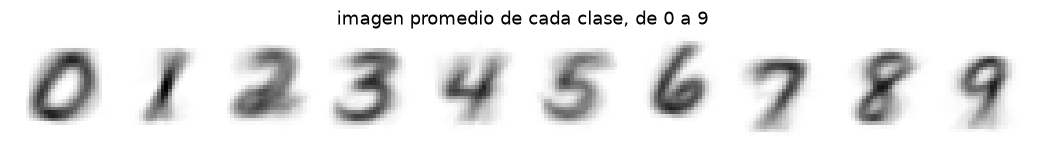

In [43]:
# Ejercicio 2.3: Discrepancia entre clases de MNIST con el MMD
X, y = cargar_mnist(20000)
X = X / X.max()
n = 100                                                        # imágenes por clase
Xo = np.vstack([X[y == c][:n] for c in range(10)])             # 10 clases × n imágenes, en orden
z = (Xo**2).sum(1)
D = np.maximum(z[:, None] + z[None, :] - 2 * Xo @ Xo.T, 0)     # ejercicio 3.1
mediana = np.median(D[D > 0])
medias = Xo.reshape(10, n, -1).mean(axis=1)                    # imagen promedio de cada clase

def mmd_entre_clases(factor=1.0):
    K = np.exp(-D / (factor * mediana))                        # 2σ² = factor · mediana
    B = K.reshape(10, n, 10, n).mean(axis=(1, 3))              # (1/NM) 1ᵀ K_ab 1 para cada pareja
    M = np.diag(B)[:, None] + np.diag(B)[None, :] - 2 * B      # MMD² = K̄aa + K̄bb − 2K̄ab
    pares = sorted((M[a, b], a, b) for a in range(10) for b in range(a + 1, 10))
    print("menor discrepancia:", ", ".join(f"{a} y {b}" for _, a, b in pares[:3]),
          "   mayor:", ", ".join(f"{a} y {b}" for _, a, b in pares[-3:][::-1]))
    L = ((medias[:, None] - medias[None])**2).sum(-1)          # kernel lineal: ‖x̄a − x̄b‖²
    fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.8))
    for a, Mx, t in [(ax[0], M, f"MMD² entre clases con RBF (factor {factor:g})"), (ax[1], L, "con kernel lineal: ‖x̄a − x̄b‖²")]:
        im = a.imshow(Mx, cmap="viridis"); fig.colorbar(im, ax=a); a.set_title(t)
        a.set_xticks(range(10)); a.set_yticks(range(10)); a.grid(False)
    plt.tight_layout(); plt.show()

interactivo(mmd_entre_clases, factor=(0.05, 20.0, 0.05, 1.0))
lado = int(np.sqrt(Xo.shape[1]))
plt.figure(figsize=(12, 1.7))
plt.imshow(np.hstack([m.reshape(lado, lado) for m in medias]), cmap="gray_r")
plt.axis("off"); plt.title("imagen promedio de cada clase, de 0 a 9"); plt.show()

**Qué observar:** La diagonal es 0. Los valores más bajos son las parejas que más se parecen y los más altos las más distintas; la celda las imprime. El kernel lineal solo compara imágenes promedio, por eso puede ordenarlas distinto.

**Prueba a cambiar:** Mueve `factor`: con valores muy grandes toda la matriz tiende a 0, y con valores muy pequeños las discrepancias se igualan.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Interpretación.** ¿Qué significa un valor pequeño en la matriz de MMD entre clases?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Que esas dos clases se parecen en promedio.
2. **Por qué.** Sus embeddings de media están cerca en el RKHS: la similitud cruzada es casi igual a la interna.
3. **Con los datos.** Con MNIST, 3 y 5 o 4 y 9; la celda imprime las de tu muestra.

</details>

**Leer la matriz o gráfica.** ¿Por qué la diagonal de la matriz de MMD entre clases es 0?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque compara cada clase consigo misma.
2. **Por qué.** Con la misma muestra, los tres promedios son el mismo: $\bar K_{aa}+\bar K_{aa}-2\bar K_{aa}=0$.
3. **Con los datos.** Con dos muestras distintas de la misma clase daría casi 0, no exactamente 0.

</details>

**Dimensiones.** Con 10 clases, ¿de qué tamaño es la matriz de discrepancias? ¿Y cada $\mathbb{K}_{XY}$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $10\times10$; cada $\mathbb{K}_{XY}$ es $N\times M$.
2. **Por qué.** Una entrada por pareja de clases; cada entrada resume una matriz kernel completa en un número.
3. **Con los datos.** Con 100 imágenes por clase, como en el código, cada $\mathbb{K}_{XY}$ es $100\times100$.

</details>

**Espacio.** ¿El MMD compara las imágenes promedio de cada clase?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Solo con el kernel lineal.
2. **Por qué.** Con el kernel lineal el MMD es la distancia entre imágenes promedio; con el RBF compara las distribuciones completas.
3. **Con los datos.** Dos clases con la misma imagen promedio pueden tener un MMD mayor que 0.

</details>

**Extremos.** ¿Qué pasa con la matriz de MMD si $\sigma$ es muy grande?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Todas las entradas tienden a 0.
2. **Por qué.** Todos los kernels tienden a 1 y los tres promedios coinciden.
3. **Con los datos.** Por eso $\sigma$ se elige con la heurística de la mediana.

</details>

**Justificación.** ¿Por qué la matriz de MMD entre clases es simétrica?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque la distancia de $a$ a $b$ es la misma que de $b$ a $a$.
2. **Por qué.** $\|\mu_a-\mu_b\|^2=\|\mu_b-\mu_a\|^2$.
3. **Con los datos.** Basta calcular la mitad de la matriz.

</details>

## 3. Forma matricial de kernels y geometría inducida

### Ejercicio 3.1. Matriz de distancias cuadradas en forma matricial

*No se alcanzó a ver en la sesión; es la demostración 28 escrita con vectores columna.*

**Enunciado.** Sea $\mathbb{X}\in\mathbb{R}^{N\times P}$ con filas $x_1,\dots,x_N\in\mathbb{R}^P$. Demuestre que $\|x_i-x_j\|_2^2=x_i^Tx_i+x_j^Tx_j-2x_i^Tx_j$ y derive la forma matricial completa de la matriz de distancias cuadradas, indicando cómo intervienen la matriz de datos, el vector de normas cuadradas y el vector de unos.

**Resultado**

$$\mathbf{D}=\mathbf{z}\mathbf{1}_N^T+\mathbf{1}_N\mathbf{z}^T-2\,\mathbb{X}\mathbb{X}^T\in\mathbb{R}^{N\times N},$$

$$\mathbf{z}=\operatorname{diag}(\mathbb{X}\mathbb{X}^T)=(\mathbb{X}\odot\mathbb{X})\mathbf{1}_P$$

**Idea de la solución:** La distancia al cuadrado se parte en tres piezas: la norma de $x_i$, la norma de $x_j$ y su producto interno. Las tres están dentro de la matriz de Gram $\mathbb{X}\mathbb{X}^T$; el vector de unos solo sirve para copiar las normas en filas y en columnas y así sumarlas sin bucles.

**Solución paso a paso**

**Paso 1.** Expandir el producto interno de la diferencia (demostración 5). Los dos términos cruzados son el mismo escalar, $x_j^Tx_i=x_i^Tx_j$.

$$\|x_i-x_j\|_2^2=(x_i-x_j)^T(x_i-x_j)=x_i^Tx_i-x_i^Tx_j-x_j^Tx_i+x_j^Tx_j=x_i^Tx_i+x_j^Tx_j-2x_i^Tx_j$$

**Paso 2.** Matriz de datos y matriz de Gram: la entrada $(i,j)$ de $\mathbb{X}\mathbb{X}^T$ es el producto interno entre las muestras $i$ y $j$.

$$\mathbb{X}=\begin{bmatrix}x_1^T\\\vdots\\x_N^T\end{bmatrix}\in\mathbb{R}^{N\times P},\qquad(\mathbb{X}\mathbb{X}^T)_{ij}=x_i^Tx_j,\qquad\mathbb{X}\mathbb{X}^T\in\mathbb{R}^{N\times N}$$

**Paso 3.** Vector de normas cuadradas: la diagonal de la matriz de Gram, o la suma de los cuadrados de cada fila.

$$\mathbf{z}=\begin{bmatrix}x_1^Tx_1\\\vdots\\x_N^Tx_N\end{bmatrix}=\operatorname{diag}(\mathbb{X}\mathbb{X}^T)=(\mathbb{X}\odot\mathbb{X})\,\mathbf{1}_P\in\mathbb{R}^{N\times1}$$

**Paso 4.** El vector de unos copia las normas: $\mathbf{z}\mathbf{1}^T$ repite $z_i$ en toda la fila $i$, y $\mathbf{1}\mathbf{z}^T$ repite $z_j$ en toda la columna $j$.

$$(\mathbf{z}\mathbf{1}_N^T)_{ij}=z_i=x_i^Tx_i,\qquad(\mathbf{1}_N\mathbf{z}^T)_{ij}=z_j=x_j^Tx_j$$

**Paso 5.** Sumar las tres piezas entrada a entrada da la forma matricial completa.

$$D_{ij}=z_i+z_j-2(\mathbb{X}\mathbb{X}^T)_{ij}\;\Longrightarrow\;\mathbf{D}=\mathbf{z}\mathbf{1}_N^T+\mathbf{1}_N\mathbf{z}^T-2\,\mathbb{X}\mathbb{X}^T$$

**Paso 6.** Propiedades: diagonal 0, simétrica y no negativa (en la práctica se aplica $\max(D,0)$ por el redondeo). Entre dos conjuntos distintos, la misma fórmula da una matriz rectangular, la que necesita el MMD.

$$D_{ii}=0,\quad\mathbf{D}=\mathbf{D}^T,\quad D_{ij}\ge0,\qquad\mathbf{D}_{XY}=\mathbf{z}_X\mathbf{1}_M^T+\mathbf{1}_N\mathbf{z}_Y^T-2\,\mathbb{X}\mathbb{Y}^T\in\mathbb{R}^{N\times M}$$

**Qué muestra la gráfica:** Las tres piezas de la fórmula y su suma: $\mathbf{z}\mathbf{1}^T$ (constante en cada fila), $\mathbf{1}\mathbf{z}^T$ (constante en cada columna), $-2\mathbb{X}\mathbb{X}^T$ y la matriz $\mathbf{D}$.

¿igual al doble bucle? True    diagonal 0: True    simétrica: True


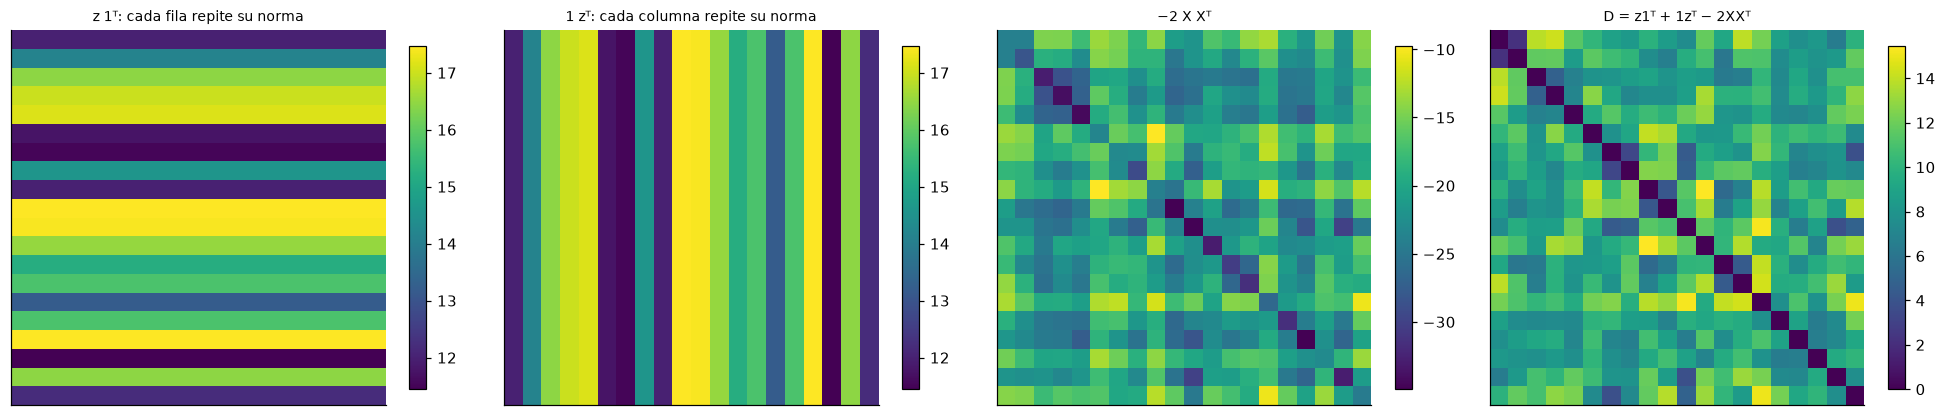

In [44]:
# Ejercicio 3.1: Matriz de distancias cuadradas en forma matricial
d = load_digits()
X = np.vstack([d.data[d.target == c][:2] for c in range(10)]) / 16    # N×P = 20×64
N = len(X)
G = X @ X.T                                                    # matriz de Gram: N×N
z = (X * X).sum(axis=1, keepdims=True)                         # (X ⊙ X) 1_P: normas cuadradas, N×1
uno = np.ones((N, 1))
piezas = [z @ uno.T, uno @ z.T, -2 * G]                        # z1ᵀ, 1zᵀ y −2XXᵀ
D = np.maximum(sum(piezas), 0)
print("¿igual al doble bucle?", np.allclose(D, [[np.sum((a - b)**2) for b in X] for a in X]),
      "   diagonal 0:", np.allclose(np.diag(D), 0), "   simétrica:", np.allclose(D, D.T))

fig, ax = plt.subplots(1, 4, figsize=(18, 4.2))
titulos = ["z 1ᵀ: cada fila repite su norma", "1 zᵀ: cada columna repite su norma", "−2 X Xᵀ", "D = z1ᵀ + 1zᵀ − 2XXᵀ"]
for a, M, t in zip(ax, piezas + [D], titulos):
    im = a.imshow(M, cmap="viridis"); a.set_title(t, fontsize=9); fig.colorbar(im, ax=a, shrink=0.8)
    a.grid(False); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

**Qué observar:** $\mathbf{z}\mathbf{1}^T$ y $\mathbf{1}\mathbf{z}^T$ son transpuestas una de la otra. La suma tiene diagonal 0, es simétrica y coincide con el doble bucle.

**Prueba a cambiar:** Centra los datos (`X = X - X.mean(0)`) antes de calcular: las tres piezas cambian, pero $\mathbf{D}$ no.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Dimensiones.** ¿Cómo intervienen el vector de normas y el vector de unos?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** $\mathbf{z}\mathbf{1}^T$ copia la norma de cada fila en todas las columnas, y $\mathbf{1}\mathbf{z}^T$ al revés.
2. **Por qué.** Así $z_i$ y $z_j$ quedan en la posición $(i,j)$ para sumarse.
3. **Con los datos.** Las dos son $N\times N$, igual que $\mathbb{X}\mathbb{X}^T$.

</details>

**Justificación.** ¿Por qué $x_j^Tx_i=x_i^Tx_j$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque es un escalar.
2. **Por qué.** Un número es igual a su transpuesto.
3. **Con los datos.** Por eso los dos términos cruzados se juntan en $-2x_i^Tx_j$.

</details>

**Leer la matriz o gráfica.** ¿Por qué la diagonal de $\mathbf{D}$ es 0?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque cada muestra está a distancia 0 de sí misma.
2. **Por qué.** $z_i+z_i-2z_i=0$.
3. **Con los datos.** Numéricamente puede salir $-10^{-15}$; se corrige con `np.maximum(D, 0)`.

</details>

**Efecto de un cambio.** ¿Afecta a $\mathbf{D}$ centrar los datos?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** No.
2. **Por qué.** Restar la misma media a todas las muestras no cambia las diferencias $x_i-x_j$.
3. **Con los datos.** Sí cambian $\mathbb{X}\mathbb{X}^T$ y $\mathbf{z}$, pero se compensan.

</details>

### Ejercicio 3.2. Matriz kernel RBF: diagonal, simetría y semidefinición positiva

*No se alcanzó a ver en la sesión; la solución se arma con las demostraciones 21, 22 y 23.*

**Enunciado.** Considere una matriz kernel gaussiana o RBF construida con las distancias cuadradas entre las muestras. Explique por qué sus elementos diagonales son constantes e interprételo geométricamente. Discuta su simetría y su semidefinición positiva, y por qué permiten interpretarla como una matriz de Gram asociada a un espacio de características.

**Resultado**

$$\mathbb{K}_{ij}=\exp\Big\{-\frac{D_{ij}}{2\sigma^2}\Big\}$$

$$\mathbb{K}_{ii}=e^{0}=1$$

$$\mathbb{K}=\mathbb{K}^T$$

$$v^T\mathbb{K}v\ge0\ \ \forall v$$

**Idea de la solución:** La diagonal compara cada muestra consigo misma: distancia 0 y kernel 1. Como $k(x,x)=\|\varphi(x)\|^2$, todas las muestras quedan sobre una esfera de radio 1 en el espacio de características, y el kernel entre dos de ellas es el coseno del ángulo que forman. Simetría y semidefinición positiva son justo las propiedades de una matriz de productos internos.

**Solución paso a paso**

**Paso 1.** Diagonal: la distancia de una muestra a sí misma es 0, para cualquier $\sigma$ y cualquier dato.

$$\mathbb{K}_{ii}=\exp\Big\{-\frac{\|x_i-x_i\|^2}{2\sigma^2}\Big\}=e^{0}=1$$

**Paso 2.** Geometría: el kernel es un producto interno, así que la diagonal es la norma al cuadrado de cada muestra transformada. Todas tienen norma 1: viven sobre la esfera unitaria del RKHS.

$$\|\varphi(x_i)\|^2=\langle\varphi(x_i),\varphi(x_i)\rangle=k(x_i,x_i)=1$$

**Paso 3.** Con norma 1, el kernel es el coseno del ángulo entre las muestras (demostración 22), y la distancia en el RKHS depende solo de él.

$$k(x_i,x_j)=\frac{\langle\varphi(x_i),\varphi(x_j)\rangle}{\|\varphi(x_i)\|\,\|\varphi(x_j)\|}=\cos\theta_{ij},\qquad\|\varphi(x_i)-\varphi(x_j)\|^2=2-2k(x_i,x_j)$$

**Paso 4.** Simetría: la distancia euclidiana es simétrica, así que el kernel también.

$$\|x_i-x_j\|=\|x_j-x_i\|\;\Longrightarrow\;\mathbb{K}_{ij}=\mathbb{K}_{ji}\;\Longrightarrow\;\mathbb{K}=\mathbb{K}^T$$

**Paso 5.** Semidefinición positiva: si $\mathbb{K}=\Phi\Phi^T$, cualquier forma cuadrática es una norma al cuadrado. Equivale a que todos sus valores propios sean mayores o iguales a 0. Para el RBF se cumple con cualquier conjunto de datos (teorema de Bochner).

$$v^T\mathbb{K}v=v^T\Phi\Phi^Tv=\|\Phi^Tv\|^2\ge0\qquad\forall v\in\mathbb{R}^N$$

**Paso 6.** El recíproco es lo que permite llamarla matriz de Gram: toda matriz simétrica y semidefinida positiva se escribe como $\Phi\Phi^T$ con su descomposición en valores propios; la raíz existe porque $\Delta\ge0$. En general, es el teorema de Mercer.

$$\mathbb{K}=U\Delta U^T=\big(U\Delta^{1/2}\big)\big(U\Delta^{1/2}\big)^T=\Phi\Phi^T,\qquad\Phi=U\Delta^{1/2}\in\mathbb{R}^{N\times N}$$

**Paso 7.** Simetría sola no basta. La distancia misma, $k(x,y)=\|x-y\|$, es simétrica, pero tiene diagonal 0 y valores propios negativos: no es un kernel válido.

$$\text{dos puntos a distancia 1:}\quad\begin{bmatrix}0&1\\1&0\end{bmatrix}\;\Longrightarrow\;\lambda=\pm1$$

**Qué muestra la gráfica:** La matriz kernel RBF, sus valores propios frente a los de usar la distancia como kernel, y el valor del kernel contra la distancia al cuadrado.

diagonal: [1. 1. 1. 1.]    simétrica: True    menor valor propio: 0.0815
¿ΦΦᵀ = K? True    normas de las filas de Φ: [1. 1. 1. 1.]


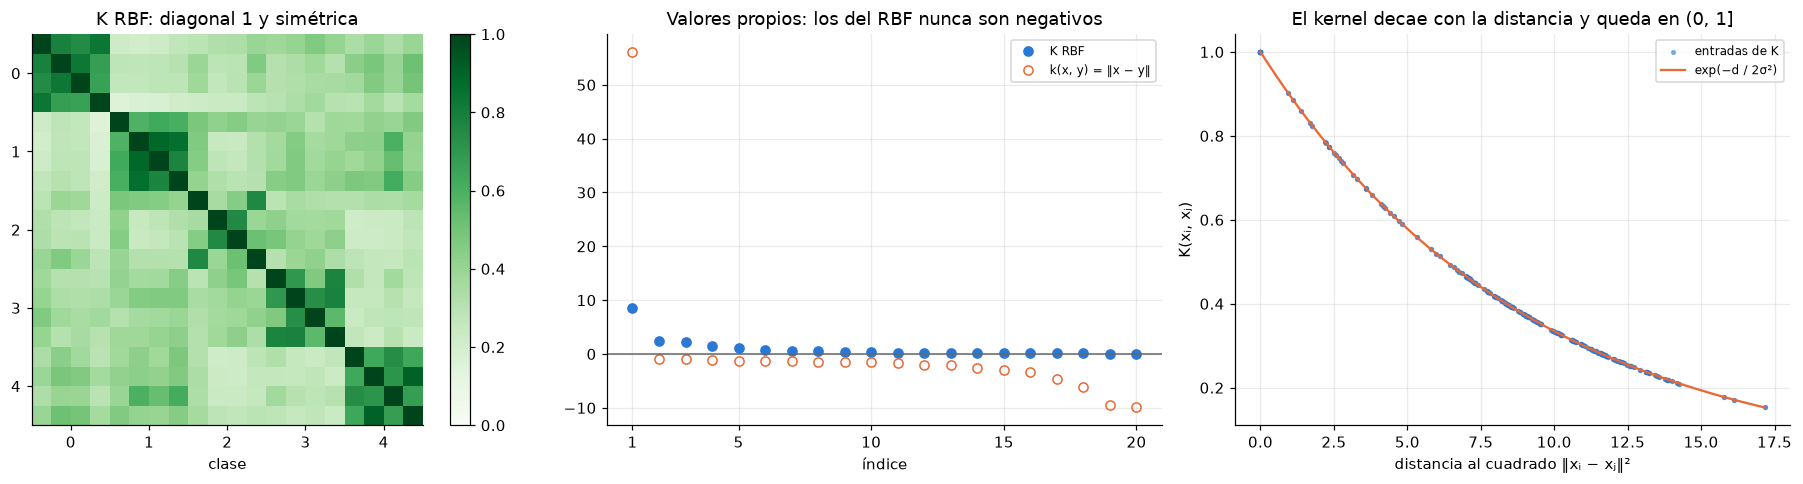

In [45]:
# Ejercicio 3.2: Matriz kernel RBF: diagonal, simetría y semidefinición positiva
d = load_digits()
X = np.vstack([d.data[d.target == c][:4] for c in range(5)]) / 16    # 20×64: clases 0 a 4
D = ((X[:, None] - X[None])**2).sum(-1)
K = np.exp(-D / np.median(D[D > 0]))                           # RBF con 2σ² = mediana
lam, U = np.linalg.eigh(K)
Phi = U * np.sqrt(np.clip(lam, 0, None))                       # K = ΦΦᵀ con Φ = U Δ^(1/2)
lam_dist = np.linalg.eigvalsh(np.sqrt(D))                      # la distancia misma usada como "kernel"
print("diagonal:", np.diag(K)[:4], "   simétrica:", np.allclose(K, K.T), "   menor valor propio:", round(lam.min(), 4))
print("¿ΦΦᵀ = K?", np.allclose(Phi @ Phi.T, K), "   normas de las filas de Φ:", np.round(np.linalg.norm(Phi, axis=1)[:4], 6))

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
im = ax[0].imshow(K, cmap="Greens", vmin=0, vmax=1); fig.colorbar(im, ax=ax[0]); ax[0].grid(False)
ax[0].set_title("K RBF: diagonal 1 y simétrica")
ax[0].set_xticks(np.arange(5) * 4 + 1.5, range(5)); ax[0].set_yticks(np.arange(5) * 4 + 1.5, range(5)); ax[0].set_xlabel("clase")
idx = np.arange(1, len(K) + 1)
ax[1].set_xticks([1, 5, 10, 15, 20])
ax[1].plot(idx, np.sort(lam)[::-1], "o", color=SERIE[0], label="K RBF")
ax[1].plot(idx, np.sort(lam_dist)[::-1], "o", mfc="none", color=SERIE[1], label="k(x, y) = ‖x − y‖")
ax[1].axhline(0, color="0.4", lw=1); ax[1].legend(fontsize=8); ax[1].set_xlabel("índice")
ax[1].set_title("Valores propios: los del RBF nunca son negativos")
dd = np.linspace(0, D.max(), 200)
ax[2].scatter(D.ravel(), K.ravel(), s=6, color=SERIE[0], alpha=0.5, label="entradas de K")
ax[2].plot(dd, np.exp(-dd / np.median(D[D > 0])), color=SERIE[1], label="exp(−d / 2σ²)")
ax[2].set_xlabel("distancia al cuadrado ‖xᵢ − xⱼ‖²"); ax[2].set_ylabel("K(xᵢ, xⱼ)"); ax[2].legend(fontsize=8)
ax[2].set_title("El kernel decae con la distancia y queda en (0, 1]")
plt.tight_layout(); plt.show()

**Qué observar:** Todos los valores propios del RBF son positivos; los de la distancia incluyen valores negativos, así que no es un kernel válido aunque sea simétrica. El kernel decae con la distancia y siempre queda entre 0 y 1, con 1 en la diagonal.

**Prueba a cambiar:** Divide `D` entre un valor mucho más pequeño que la mediana: $\mathbb{K}$ se acerca a la identidad y todos sus valores propios a 1.

**Preguntas de práctica.** Intenta responder cada una antes de abrir la respuesta.

**Justificación.** ¿Por qué la diagonal del RBF siempre da 1?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque cada muestra se compara consigo misma.
2. **Por qué.** La distancia es 0 y $e^0=1$, sin importar $\sigma$ ni los datos.
3. **Con los datos.** En el espacio de características todas las muestras tienen norma 1.

</details>

**Interpretación.** ¿Qué significa geométricamente que $k(x,x)=1$?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Que todas las muestras quedan sobre una esfera de radio 1 en el RKHS.
2. **Por qué.** $\|\varphi(x)\|^2=k(x,x)=1$, así que $k(x_i,x_j)$ es el coseno del ángulo entre ellas.
3. **Con los datos.** Dos muestras iguales apuntan en la misma dirección; dos muy lejanas, en direcciones casi perpendiculares.

</details>

**Justificación.** ¿Por qué una matriz de Gram es semidefinida positiva?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque $v^T\Phi\Phi^Tv=\|\Phi^Tv\|^2\ge0$.
2. **Por qué.** Es la norma al cuadrado de un vector, que nunca es negativa.
3. **Con los datos.** Equivale a que todos sus valores propios sean mayores o iguales a 0.

</details>

**Espacio.** ¿Por qué simetría y semidefinición positiva bastan para hablar de un espacio de características?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Porque toda matriz así se puede escribir como $\Phi\Phi^T$.
2. **Por qué.** $\mathbb{K}=U\Delta U^T=(U\Delta^{1/2})(U\Delta^{1/2})^T$, y la raíz existe porque $\Delta\ge0$.
3. **Con los datos.** Es el teorema de Mercer: el kernel es un producto interno en algún espacio.

</details>

**Extremos.** ¿Qué valores puede tomar $\mathbb{K}_{ij}$ fuera de la diagonal?

<details><summary>Ver respuesta</summary>

1. **Respuesta.** Entre 0 y 1.
2. **Por qué.** La exponencial de un número negativo está en $(0,1]$.
3. **Con los datos.** Con $\sigma$ grande tienden a 1; con $\sigma$ pequeño, a 0.

</details>

# Cómo responder las preguntas

Las preguntas de clase suelen mostrar un resultado (una matriz, una gráfica, un valor) y pedir que se interprete, se justifique o se lleve a un extremo. Funcionan mejor las respuestas cortas y seguras, seguidas del porqué. Responde en tres pasos:

1. **Respuesta directa:** sí o no, el valor o el tamaño.
2. **Por qué, con las palabras del curso:** «se parece a», «la diagonal», «la similitud», «en el RKHS», «está en escala».
3. **Conexión con los datos:** los bordes de las imágenes, el bloque de la clase 0, el 4 que se parece al 9.

Las preguntas de práctica de cada demostración y de cada ejercicio tienen una etiqueta con su tipo:

| Tipo | Cómo suena | Preguntas en el cuaderno |
|---|---|---|
| Interpretación | «¿Qué significa…? ¿Qué creen que significa esto?» | 28 |
| Justificación | «¿Por qué la diagonal da 1? ¿Por qué se encendió así?» | 41 |
| Extremos | «Recuerden los extremos: ¿y si σ es muy grande o muy pequeño?» | 22 |
| Efecto de un cambio | «¿Afecta o no afecta? ¿Nos cambió en algo?» | 18 |
| Dimensiones | «¿De qué tamaño nos va a dar?» | 20 |
| Leer la matriz o gráfica | «¿Quién está acá? ¿Se parece a quién? ¿Tendrá sentido eso?» | 11 |
| Espacio | «¿Estamos en el espacio original o en el RKHS? ¿Está en escala?» | 13 |

Debajo están las preguntas agrupadas por tema, con la forma en que suelen aparecer y cómo armar la respuesta.

## 1. ¿De qué tamaño es…?

*Así suena:* «¿De qué tamaño es μ?» «¿Qué tamaño debe tener lo que va abajo?» «Si σ es de 1×784, ¿de qué tamaño queda σᵀσ?»

**Cómo responder.** Escribe el tamaño debajo de cada factor. En un producto, las dimensiones de adentro deben coincidir y el resultado se queda con las de afuera: $(a\times b)(b\times c)=a\times c$. Las operaciones elemento a elemento (suma, división, exponencial) no cambian el tamaño. En NumPy un vector 1D tiene forma `(P,)`: no es fila ni columna hasta que le agregas la dimensión con `reshape(1, -1)` o `reshape(-1, 1)`.

**1.** Con $\mathbb{X}\in\mathbb{R}^{N\times784}$ (filas = imágenes), ¿de qué tamaño son la media por píxel y la media por imagen?

<details><summary>Ver respuesta</summary>

Por píxel (Caso 1): $\mu=\frac1N\mathbf{1}_N^T\mathbb{X}\in\mathbb{R}^{1\times784}$, que se puede ver como una imagen de $28\times28$. Por imagen (Caso 2): $\hat\mu=\frac{1}{784}\mathbb{X}\mathbf{1}_{784}\in\mathbb{R}^{N\times1}$, un número por imagen.

*Para repasar: demostraciones 25 y 32.*

</details>

**2.** ¿De qué tamaño es la matriz de covarianza de los píxeles? ¿Y la matriz kernel?

<details><summary>Ver respuesta</summary>

La covarianza de píxeles es $\frac1N\mathbb{X}_c^T\mathbb{X}_c\in\mathbb{R}^{784\times784}$: relaciona píxeles. La matriz kernel es $\mathbb{K}\in\mathbb{R}^{N\times N}$: relaciona imágenes. Con 100 imágenes es $100\times100$.

*Para repasar: demostraciones 26 y 28.*

</details>

**3.** Para la correlación hay que dividir cada $\Sigma_{ij}$ entre $\sigma_i\sigma_j$. ¿De qué tamaño debe ser el denominador y cómo se construye sin bucles?

<details><summary>Ver respuesta</summary>

Del mismo tamaño que $\Sigma$, $784\times784$, porque la división es elemento a elemento. Se arma con un producto exterior: $\boldsymbol\sigma^T\boldsymbol\sigma$ con $\boldsymbol\sigma\in\mathbb{R}^{1\times784}$, es decir $(784\times1)(1\times784)=784\times784$. En NumPy: `np.outer(sd, sd)`.

*Para repasar: demostración 31.*

</details>

**4.** ¿Cambia el tamaño de la matriz al pasar de covarianza a correlación?

<details><summary>Ver respuesta</summary>

No. Se divide elemento a elemento entre una matriz del mismo tamaño, así que sigue siendo $P\times P$ (o $N\times N$ en el RKHS).

*Para repasar: demostraciones 31 y 33.*

</details>

**5.** Si `kernel(X1, X2)` recibe $X_1\in\mathbb{R}^{N_1\times P}$ y $X_2\in\mathbb{R}^{N_2\times P}$, ¿de qué tamaño es el resultado? ¿Y si los dos son $\mathbb{X}$?

<details><summary>Ver respuesta</summary>

$N_1\times N_2$: una similitud por cada par (imagen de $X_1$, imagen de $X_2$). Si $X_1=X_2=\mathbb{X}$, sale la matriz cuadrada $N\times N$, simétrica y, en el RBF, con diagonal 1.

*Para repasar: demostraciones 28 y 33.*

</details>

## 2. ¿Qué significa…?

*Así suena:* «¿Qué indica que el MMD sea 0?» «¿Qué me está diciendo este cuadrito de la matriz?» «Si las distribuciones son iguales los promedios coinciden, ¿y qué significa eso?»

**Cómo responder.** Responde en dos partes: qué dice la fórmula (traduce cada término a palabras) y qué dice sobre los datos. Si el valor es un límite (0, 1 o −1), di cuándo se alcanza y qué condición hace falta.

**1.** Si el MMD entre dos conjuntos es 0, ¿qué indica?

<details><summary>Ver respuesta</summary>

Que las medias en el espacio de características coinciden, $\mu_x=\mu_y$. Con un kernel característico como el RBF, eso significa que las dos distribuciones son iguales, porque $\mu$ guarda todos los momentos. Con un kernel lineal solo dice que las medias son iguales. Con muestras reales nunca da exactamente 0; se decide con una prueba de permutaciones.

*Para repasar: demostración 30.*

</details>

**2.** "Si las distribuciones son iguales, los tres promedios coinciden." ¿Qué significa que coincidan?

<details><summary>Ver respuesta</summary>

Que la similitud promedio dentro de $\mathbb{X}$, dentro de $\mathbb{Y}$ y entre $\mathbb{X}$ e $\mathbb{Y}$ es la misma: un punto de $\mathbb{X}$ se parece en promedio tanto a otro de $\mathbb{X}$ como a uno de $\mathbb{Y}$. Entonces $\bar K_{xx}-2\bar K_{xy}+\bar K_{yy}=0$ y no hay forma de distinguir los dos conjuntos.

*Para repasar: demostración 30.*

</details>

**3.** En la matriz $100\times100$ ordenada por clase, ¿qué significan los bloques claros de la diagonal? ¿Y un bloque claro fuera de ella?

<details><summary>Ver respuesta</summary>

Los bloques de la diagonal ($10\times10$) comparan imágenes de la misma clase: si son claros, el kernel ve parecidas las imágenes de esa clase. Un bloque claro fuera de la diagonal, por ejemplo en la fila 4 y la columna 9, indica que esas dos clases se parecen: un 4 se puede confundir con un 9.

*Para repasar: demostración 33.*

</details>

**4.** ¿Qué significa que la covarianza de un píxel del borde sea 0?

<details><summary>Ver respuesta</summary>

Que ese píxel vale lo mismo (0) en todas las imágenes: no varía, así que no aporta información para distinguirlas. Cada término es $(x-\mu)(y-\mu)=0\cdot0=0$.

*Para repasar: demostraciones 31 y 32.*

</details>

**5.** ¿Por qué la diagonal de la matriz de correlación vale 1? ¿Siempre?

<details><summary>Ver respuesta</summary>

Porque compara cada variable consigo misma: $\rho_{ii}=\frac{\operatorname{Var}(x_i)}{\sqrt{\operatorname{Var}(x_i)\operatorname{Var}(x_i)}}=1$, el coseno de un vector consigo mismo. No siempre: si la varianza es 0 queda $\frac00$, y con el $\varepsilon$ ese valor pasa a ser 0.

*Para repasar: demostraciones 10 y 31.*

</details>

## 3. ¿Por qué…?

*Así suena:* «¿Por qué sale la advertencia de división entre cero?» «¿Por qué no puedo graficar eso como imagen?» «¿Por qué no lo dejamos en manos de Python?»

**Cómo responder.** Busca la causa en la fórmula o en los datos, no en el código. Una buena respuesta tiene tres partes: causa, consecuencia y cómo se evita.

**1.** ¿Por qué al calcular la correlación de MNIST aparecen NaN o una advertencia de división entre cero?

<details><summary>Ver respuesta</summary>

Causa: los píxeles del borde valen 0 en todas las imágenes, así que su varianza es 0 y $\sigma_i\sigma_j=0$. Consecuencia: $\frac00=$ NaN. Solución: sumar un $\varepsilon$ pequeño al denominador, $\frac{\Sigma_{ij}}{\sigma_i\sigma_j+\varepsilon}$, elegido por ti y no por Python, para saber exactamente qué cambio introduces.

*Para repasar: demostración 31.*

</details>

**2.** ¿Por qué hay que centrar el kernel ($H\mathbb{K}H$) antes de calcular la correlación en el RKHS?

<details><summary>Ver respuesta</summary>

Porque la covarianza mide la variación alrededor de la media. Sin centrar, $\mathbb{K}$ mezcla la media $\mu_{\mathcal H}$ con la variación. $H\mathbb{K}H$ es exactamente $(\Phi-\mathbf{1}\mu_{\mathcal H})(\Phi-\mathbf{1}\mu_{\mathcal H})^T$.

*Para repasar: demostraciones 29 y 33.*

</details>

**3.** ¿Por qué en el RKHS ya no se puede graficar la covarianza de los píxeles como en el espacio original?

<details><summary>Ver respuesta</summary>

Porque en el RKHS los datos ya no tienen 784 columnas-píxel: cada imagen es un vector $\varphi(x)$ de dimensión $Q\to\infty$ que nunca se construye. Lo único que se puede calcular es la matriz $N\times N$ de relaciones entre imágenes.

*Para repasar: demostraciones 24 y 33.*

</details>

**4.** ¿Por qué para armar la matriz $100\times784$ ordenada por clase no sirve `reshape` y sí `vstack`?

<details><summary>Ver respuesta</summary>

`reshape` solo reacomoda los números en el orden en que están en memoria: no sabe de clases y puede mezclar imágenes. `np.vstack([X_0, X_1, ..., X_9])` apila los bloques de 10 imágenes uno debajo del otro y conserva el orden por clase.

*Para repasar: demostración 33.*

</details>

**5.** ¿Por qué no se puede convertir en arreglo de NumPy una lista con filas de distinto largo y operar con ella?

<details><summary>Ver respuesta</summary>

Porque un arreglo exige el mismo tipo en todos sus elementos y la misma cantidad de columnas en todas las filas: es rectangular. Las listas son flexibles y aceptan cualquier cosa, pero no permiten operaciones matriciales.

*Para repasar: demostración 33.*

</details>

## 4. ¿Qué pasa si…?

*Así suena:* «¿Qué pasa si σ es muy grande? ¿Y muy pequeño?» «¿Qué pasa si pongo 350 como máximo de la escala?» «¿Qué pasa si quito el ε?»

**Cómo responder.** Lleva el parámetro a sus extremos ($\to0$ y $\to\infty$). Describe primero qué le pasa a la fórmula y después qué se ve en la gráfica. Termina diciendo qué valor intermedio conviene y cómo se elige.

**1.** En el kernel RBF, ¿qué pasa si $\sigma$ es muy grande? ¿Y si es muy pequeño?

<details><summary>Ver respuesta</summary>

$\sigma\to\infty$: $\mathbb{K}\to\mathbf{1}\mathbf{1}^T$, todo se parece a todo y la matriz no da información. $\sigma\to0$: $\mathbb{K}\to I$, nada se parece a nada salvo cada imagen consigo misma. Se busca un valor intermedio: se empieza con la heurística de la mediana y se ajusta hasta que aparezcan las relaciones (los bloques por clase).

*Para repasar: demostraciones 23 y 33.*

</details>

**2.** En `imshow`, ¿qué pasa con los valores por debajo de `vmin` y por encima de `vmax`? ¿Y si pongo `vmax=350` en una imagen que llega hasta 255?

<details><summary>Ver respuesta</summary>

Todo lo que está por debajo de `vmin` toma el color mínimo y todo lo que supera `vmax` el máximo: se satura. Con `vmax=350` y datos hasta 255, la imagen nunca llega al color máximo: se ve más pálida y con menos contraste, aunque los datos no cambiaron. Para comparar dos imágenes hay que usar los mismos `vmin` y `vmax`.

*Para repasar: demostración 32.*

</details>

**3.** ¿Qué pasa si el $\varepsilon$ es muy grande? ¿Y si es 0?

<details><summary>Ver respuesta</summary>

Si es 0, los píxeles de varianza 0 dan NaN. Si es muy grande, todas las correlaciones se encogen hacia 0 y la diagonal deja de valer 1: estás cambiando el resultado. Debe ser pequeño frente a las varianzas, por ejemplo $10^{-8}$ veces la mayor.

*Para repasar: demostración 31.*

</details>

**4.** ¿Qué pasa con la matriz de correlación del RKHS si las imágenes no están ordenadas por clase?

<details><summary>Ver respuesta</summary>

Los valores son los mismos, pero quedan dispersos y no aparecen bloques. Ordenar no cambia la información, solo la hace visible.

*Para repasar: demostración 33.*

</details>

**5.** En Ridge, ¿qué pasa cuando $\lambda\to0$? ¿Y cuando $\lambda\to\infty$?

<details><summary>Ver respuesta</summary>

Con $\lambda\to0$ se vuelve a mínimos cuadrados, y $\mathbb{X}^T\mathbb{X}$ puede no ser invertible. Con $\lambda\to\infty$ todos los pesos tienden a 0. El valor intermedio se elige por validación cruzada.

*Para repasar: demostración 18.*

</details>

## 5. ¿Cómo lo programas sin bucles?

*Así suena:* «¿Cómo hago que esto opere punto a punto?» «¿Cómo le agrego la dimensión?» «¿Cómo saco todas las distancias de una vez?»

**Cómo responder.** Traduce la sumatoria a producto de matrices (demostración 7), revisa los tamaños y usa *broadcasting* para lo que es elemento a elemento. Antes de restar o dividir, confirma que las formas sean compatibles.

**1.** Tienes `mu` con forma `(784,)` y quieres restarla a cada fila de `X`, con forma `(N, 784)`. ¿Funciona `X - mu`? ¿Y para restar la media de cada imagen?

<details><summary>Ver respuesta</summary>

Sí: NumPy alinea las dimensiones por la derecha y repite `mu` en cada fila (*broadcasting*), que es $\mathbb{X}-\mathbf{1}_N\mu$. La media de cada imagen, `m = X.mean(axis=1)`, tiene forma `(N,)` y hay que volverla columna: `X - m[:, None]` o `X - m.reshape(-1, 1)`, que es $\mathbb{X}-\hat\mu\mathbf{1}^T$.

*Para repasar: demostración 25.*

</details>

**2.** ¿Qué hace `np.diag` si le pasas un vector? ¿Y si le pasas una matriz?

<details><summary>Ver respuesta</summary>

Con un vector construye una matriz diagonal; con una matriz extrae su diagonal como vector 1D. Por eso, para $\mathbf{z}=\operatorname{diag}(\mathbb{X}\mathbb{X}^T)$ hay que extraerla y darle forma de columna: `np.diag(X @ X.T).reshape(-1, 1)`.

*Para repasar: demostración 28.*

</details>

**3.** Escribe la matriz de distancias al cuadrado sin bucles.

<details><summary>Ver respuesta</summary>

$\mathbf{D}=\mathbf{z}\mathbf{1}^T-2\mathbb{X}\mathbb{X}^T+\mathbf{1}\mathbf{z}^T$. En NumPy: `z = (X**2).sum(1)[:, None]; D = z - 2*X@X.T + z.T`, y después `np.maximum(D, 0)` por el redondeo.

*Para repasar: demostración 28.*

</details>

**4.** ¿Cómo armas $\mathbb{X}\in\mathbb{R}^{100\times784}$ con 10 imágenes de cada clase, en orden?

<details><summary>Ver respuesta</summary>

`X = np.vstack([x_train[y_train == c][:10] for c in range(10)]).reshape(100, -1)`. Se filtra cada clase, se toman 10, se apilan en orden y al final cada imagen de $28\times28$ se aplana a 784.

*Para repasar: demostración 33.*

</details>

**5.** Programa la correlación de una matriz kernel.

<details><summary>Ver respuesta</summary>

`H = np.eye(N) - np.ones((N, N)) / N; Kc = H @ K @ H; d = np.sqrt(np.diag(Kc)); R = Kc / (np.outer(d, d) + eps)`.

*Para repasar: demostraciones 29 y 33.*

</details>

## 6. Compara estas gráficas

*Así suena:* «¿Se parecen la imagen de la media y la de la varianza? ¿Qué cambia?» «¿Qué característica tiene la matriz de covarianza frente a la de correlación?»

**Cómo responder.** Compara tres cosas: la estructura (dónde están los valores altos y bajos), la escala (el rango de valores) y el significado (qué mide cada una). Si las escalas son distintas, normaliza antes de comparar.

**1.** ¿Se parecen la imagen de la media y la imagen de la varianza? ¿En qué se diferencian?

<details><summary>Ver respuesta</summary>

Tienen estructura parecida: el borde vale 0 en las dos, porque ningún dígito pasa por ahí. Tienen escala distinta: los datos llegan a 255, la media por píxel a unos 140 y la varianza a unos 13 000. Y significan cosas distintas: la media dice dónde suele haber trazo y la varianza dónde cambia más de una imagen a otra. Para compararlas: normalización min-max, $\tilde v=\frac{v-\min v}{\max v-\min v}$, y la misma escala de color.

*Para repasar: demostración 32.*

</details>

**2.** ¿Qué características tiene la matriz de covarianza frente a la de correlación?

<details><summary>Ver respuesta</summary>

Las dos son simétricas y del mismo tamaño. La covarianza depende de las unidades y su diagonal son las varianzas. La correlación está entre −1 y 1 y su diagonal vale 1, así que permite comparar pares de píxeles aunque tengan escalas distintas.

*Para repasar: demostraciones 12 y 31.*

</details>

**3.** ¿Qué diferencia hay entre la matriz kernel $\mathbb{K}$ y la correlación en el RKHS?

<details><summary>Ver respuesta</summary>

$\mathbb{K}$ es una similitud sin centrar: en el RBF sus valores están en $(0,1]$ y su diagonal es 1. La correlación en el RKHS primero centra ($H\mathbb{K}H$) y luego normaliza: sus valores están en $[-1,1]$ y son negativos cuando dos imágenes se desvían de la media en direcciones opuestas.

*Para repasar: demostración 33.*

</details>

## 7. Demuéstralo paso a paso

*Así suena:* «Demostrar paso a paso: MMD² = ‖μx − μy‖².» «¿Cómo sacamos la covarianza en el espacio del kernel?»

**Cómo responder.** 1) Escribe la definición. 2) Expándela como en la demostración 5: $\|a-b\|^2=\langle a,a\rangle-2\langle a,b\rangle+\langle b,b\rangle$. 3) Reemplaza cada media por su sumatoria. 4) Saca las sumas por linealidad. 5) Cambia cada $\langle\varphi,\varphi\rangle$ por $K$. 6) Pasa a forma matricial y revisa los tamaños.

**1.** Demuestra que $\operatorname{MMD}^2=\|\mu_x-\mu_y\|^2$ se puede calcular solo con kernels.

<details><summary>Ver respuesta</summary>

$\|\mu_x-\mu_y\|^2=\langle\mu_x,\mu_x\rangle-2\langle\mu_x,\mu_y\rangle+\langle\mu_y,\mu_y\rangle$. Con $\mu_x=\frac1N\sum_n\varphi(x_n)$ y $\mu_y=\frac1M\sum_m\varphi(y_m)$, cada producto interno se vuelve una doble suma: $\frac{1}{N^2}\sum_{n,n'}K(x_n,x_{n'})-\frac{2}{NM}\sum_{n,m}K(x_n,y_m)+\frac{1}{M^2}\sum_{m,m'}K(y_m,y_{m'})$.

*Para repasar: demostración 30.*

</details>

**2.** Demuestra que la covarianza en el espacio de características es $H\mathbb{K}H$.

<details><summary>Ver respuesta</summary>

$\Phi_c=\Phi-\mathbf{1}\mu_{\mathcal H}=(I-J)\Phi$ con $J=\frac1N\mathbf{1}\mathbf{1}^T$. Entonces $\Phi_c\Phi_c^T=(I-J)\Phi\Phi^T(I-J)=\mathbb{K}-\mathbb{K}J-J\mathbb{K}+J\mathbb{K}J=H\mathbb{K}H$.

*Para repasar: demostración 29.*

</details>

**3.** Demuestra que la covarianza total en el espacio de características es $\frac1N\sum_nK(x_n,x_n)-\frac{1}{N^2}\sum_n\sum_{n'}K(x_n,x_{n'})$.

<details><summary>Ver respuesta</summary>

$\mathbb{E}\{\|\varphi-\mu_{\mathcal H}\|^2\}=\mathbb{E}\{\varphi\varphi^T\}-\mu_{\mathcal H}\mu_{\mathcal H}^T$. El primer término es $\frac1N\sum_nK(x_n,x_n)$. Al expandir aparecen tres términos iguales a $A=\frac{1}{N^2}\sum_n\sum_{n'}K(x_n,x_{n'})$ con signos $-A-A+A=-A$.

*Para repasar: demostración 24.*

</details>

# Cómo hacer tus propias visualizaciones

Casi todas las gráficas de este cuaderno salen de siete recetas. Elige según el tipo de objeto que quieres entender:

| Si tienes... | Grafica con... | En matplotlib | Ejemplos aquí |
|---|---|---|---|
| Una matriz (covarianza, kernel, tabla conjunta) | Mapa de calor | `imshow` (o `mapa_calor`) | 1, 7, 11, 12, 21, 23, 26 a 29, 31, 33; ejercicios 1.4, 2.2, 2.3, 3.1, 3.2 |
| Un vector que es una imagen (media o varianza por píxel) | Imagen, con la misma escala de color si vas a comparar | `imshow(v.reshape(28, 28), vmin=..., vmax=...)` | 31, 32; ejercicio 2.3 |
| Datos en 2D (dos variables) | Nube de puntos, coloreada por grupo o signo | `scatter` | 9, 10, 12, 22, 29, 30; ejercicio 3.2 |
| Una función de un parámetro (log L, SSE, h(p), embedding) | Curva, marcando el máximo o mínimo | `plot` + `axvline` | 3, 15, 16, 19; ejercicios 1.1, 2.1 |
| Una función de dos parámetros (error J(w), posterior) | Curvas de nivel | `contour` | 17, 20 |
| Varios términos o valores propios | Barras, apiladas si se suman | `bar` con `bottom=` | 1, 18, 21, 24; ejercicios 1.1 a 1.4, 2.2 |
| Un resultado que depende de un parámetro (σ, λ, ρ) | Deslizador que redibuja la gráfica | `ipywidgets` (o `interactivo`) | 10, 23, 30, 33; ejercicios 1.1, 1.3, 2.1, 2.3 |

Cuatro consejos que se repiten en todo el cuaderno:

1. **Compara siempre dos caminos.** Si demuestras que A = B, grafica A y B juntos (curva y puntos, dos mapas de calor, barra y estrella). Si coinciden, la demostración se ve.
2. **Ordena antes de dibujar matrices.** Al ordenar los datos por clase, la estructura de un kernel o de una covarianza aparece como bloques.
3. **Mueve un parámetro hacia sus extremos.** Los casos límite (σ → 0, σ → ∞, λ → 0, N pequeño) muestran por qué la fórmula se comporta como dice la teoría.
4. **Fija la escala de color antes de comparar imágenes.** Con los mismos `vmin` y `vmax` en las dos, una diferencia de color es una diferencia en los datos y no en la escala (demostración 32).